In [1]:
import pandas as pd
from datetime import datetime

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')

print("🚀✨🌟 DEMAND FORECASTING PROJECT ✨🌟🚀\n")
print("="*80)
print("🎯 **PROBLEM INTRODUCTION & FRAMING** 🎯".center(80))
print("="*80 + "\n")

print("📌 **Business Challenge**")
print("   In today's competitive retail landscape, accurately predicting product demand")
print("   is crucial for optimizing inventory, reducing stockouts, minimizing overstock,")
print("   and maximizing revenue. Poor forecasting leads to lost sales 💸 or wasted")
print("   warehouse space 🏬.\n")

print("🎯 **Our Mission**")
print("   Build a robust Machine Learning model to forecast **daily Demand** for")
print("   different products across multiple stores and regions.\n")

print("🛍️ **Dataset Overview**")
print(f"   📊 Total Records     : {len(df):,} rows")
print(f"   📅 Date Range        : {df['Date'].min()} to {df['Date'].max()}")
print(f"   🏪 Number of Stores  : {df['Store ID'].nunique()}")
print(f"   📦 Number of Products: {df['Product ID'].nunique()}")
print(f"   🗂️  Categories        : {', '.join(df['Category'].unique())}")
print(f"   🧭 Regions           : {', '.join(df['Region'].unique())}")
print(f"   🌦️  Weather Types    : {', '.join(df['Weather Condition'].unique())}")
print(f"   🎟️  Promotion Status : {df['Promotion'].value_counts().to_dict()}\n")

print("🔍 **Key Features in the Dataset**")
print("""
   • Date                → Temporal information
   • Store ID            → Store identifier
   • Product ID          → Unique product code
   • Category            → Product category (Electronics, Clothing, etc.)
   • Region              → North, South, East, West
   • Inventory Level     → Current stock
   • Units Sold          → Historical sales
   • Units Ordered       → Replenishment orders
   • Price & Discount    → Pricing strategy
   • Weather Condition   → External factor (Sunny, Snowy, Cloudy)
   • Promotion           → Whether a promotion was active (0/1)
   • Competitor Pricing  → Market competition
   • Seasonality         → Winter / other seasons
   • Epidemic            → External shock indicator (0/1)
   • **Demand**          → TARGET VARIABLE to forecast 🔥
""")

print("⚡ **Why This Matters**")
print("   ✅ Reduce inventory holding costs")
print("   ✅ Prevent stockouts during peak demand")
print("   ✅ Optimize promotion strategies")
print("   ✅ Improve supply chain efficiency")
print("   ✅ Boost customer satisfaction 🛒\n")

print("🔮 **Modeling Approach**")
print("   1. Exploratory Data Analysis (EDA) 📈")
print("   2. Feature Engineering (lags, rolling stats, holidays, etc.) ⚙️")
print("   3. Time Series + ML Models (Prophet, XGBoost, LSTM, etc.) 🤖")
print("   4. Evaluation using MAE, RMSE, MAPE 📏")

print("="*80)
print("Ready to forecast the future? Let's dive in! 🚀".center(80))
print("="*80)

🚀✨🌟 DEMAND FORECASTING PROJECT ✨🌟🚀

                     🎯 **PROBLEM INTRODUCTION & FRAMING** 🎯                     

📌 **Business Challenge**
   In today's competitive retail landscape, accurately predicting product demand
   is crucial for optimizing inventory, reducing stockouts, minimizing overstock,
   and maximizing revenue. Poor forecasting leads to lost sales 💸 or wasted
   warehouse space 🏬.

🎯 **Our Mission**
   Build a robust Machine Learning model to forecast **daily Demand** for
   different products across multiple stores and regions.

🛍️ **Dataset Overview**
   📊 Total Records     : 76,000 rows
   📅 Date Range        : 2022-01-01 to 2024-01-30
   🏪 Number of Stores  : 5
   📦 Number of Products: 20
   🗂️  Categories        : Electronics, Clothing, Groceries, Toys, Furniture
   🧭 Regions           : North, South, East, West
   🌦️  Weather Types    : Snowy, Cloudy, Sunny, Rainy
   🎟️  Promotion Status : {0: 51000, 1: 25000}

🔍 **Key Features in the Dataset**

   • Date     

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime

# ====================== DEMAND FORECASTING - DATA CLEANING & PREPROCESSING ======================
print("🧹✨ DATA CLEANING & PREPROCESSING ✨🧹\n")
print("="*85)
print("📊 Step 1: Loading and Initial Inspection".center(85))
print("="*85 + "\n")

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

print("✅ Dataset successfully loaded!\n")

# --------------------- 1. Basic Overview ---------------------
print("1️⃣ FIRST 5 ROWS (df.head())")
print("-" * 50)
print(df.head().to_string(index=False))

print("\n\n2️⃣ DATASET INFORMATION (df.info())")
print("-" * 50)
df.info()

print("\n\n3️⃣ STATISTICAL SUMMARY (df.describe())")
print("-" * 50)
print(df.describe().round(2))

print("\n\n4️⃣ MISSING VALUES CHECK (df.isnull().sum())")
print("-" * 50)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found in any column!")

# --------------------- 5. Data Cleaning Steps ---------------------
print("\n" + "="*85)
print("🧼 DATA CLEANING & PREPROCESSING STEPS".center(85))
print("="*85 + "\n")

# 1. Handling Missing Values (if any)
print("🔧 1. Handling Missing Values...")
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"   → Filled missing values in '{col}' with mode")
        else:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"   → Filled missing values in '{col}' with median")

# 2. Data Type Corrections
print("\n🔧 2. Correcting Data Types...")
df['Promotion'] = df['Promotion'].astype(int)
df['Epidemic'] = df['Epidemic'].astype(int)

# 3. Feature Engineering
print("\n🔧 3. Feature Engineering...")

# Extract date components
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday
df['Is_Weekend'] = df['Weekday'].isin([5, 6]).astype(int)

# Create Season column from Seasonality
df['Season'] = df['Seasonality']  # Already present as Winter mostly

# Price after discount
df['Effective_Price'] = df['Price'] * (1 - df['Discount']/100)

# Inventory Turnover Ratio
df['Inventory_Turnover'] = df['Units Sold'] / (df['Inventory Level'] + 1)  # +1 to avoid division by zero

print("   → Added: Year, Month, Day, Weekday, Is_Weekend")
print("   → Added: Effective_Price")
print("   → Added: Inventory_Turnover")

# 4. Outlier Check (Optional - using IQR method)
print("\n🔧 4. Outlier Analysis (Summary)...")
numerical_cols = ['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 
                  'Discount', 'Competitor Pricing', 'Demand']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5*IQR)) | (df[col] > (Q3 + 1.5*IQR))).sum()
    print(f"   → {col:18}: {outliers:5} outliers detected")

# Final Dataset Shape
print("\n" + "="*85)
print("✅ FINAL DATASET STATUS".center(85))
print("="*85)
print(f"📏 Final Shape                  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Date Range                   : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"🏪 Stores                       : {df['Store ID'].nunique()}")
print(f"📦 Products                     : {df['Product ID'].nunique()}")
print(f"🎯 Target Variable (Demand)     : Ready for modeling 🔥")

# Show cleaned dataset preview
print("\n📋 Cleaned Dataset Preview (First 3 rows):")
print(df.head(3)[['Date', 'Store ID', 'Product ID', 'Category', 'Region', 
                  'Units Sold', 'Demand', 'Effective_Price', 'Promotion']].to_string(index=False))

# Save the cleaned dataset
df.to_csv('demand_forecasting_cleaned.csv', index=False)
print("\n💾 Cleaned dataset saved as 'demand_forecasting_cleaned.csv'")

🧹✨ DATA CLEANING & PREPROCESSING ✨🧹

                       📊 Step 1: Loading and Initial Inspection                      

✅ Dataset successfully loaded!

1️⃣ FIRST 5 ROWS (df.head())
--------------------------------------------------
      Date Store ID Product ID    Category Region  Inventory Level  Units Sold  Units Ordered  Price  Discount Weather Condition  Promotion  Competitor Pricing Seasonality  Epidemic  Demand
2022-01-01     S001      P0001 Electronics  North              195         102            252  72.72         5             Snowy          0               85.73      Winter         0     115
2022-01-01     S001      P0002    Clothing  North              117         117            249  80.16        15             Snowy          1               92.02      Winter         0     229
2022-01-01     S001      P0003    Clothing  North              247         114            612  62.94        10             Snowy          1               60.08      Winter         0     157
2022

📊✨ IMPORTANT HISTOGRAMS ✨📊

                         🎯 DISTRIBUTION ANALYSIS OF KEY VARIABLES                         

1️⃣ DEMAND DISTRIBUTION (Target Variable)
----------------------------------------------------------------------


/tmp/ipykernel_55/3225581481.py:35: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


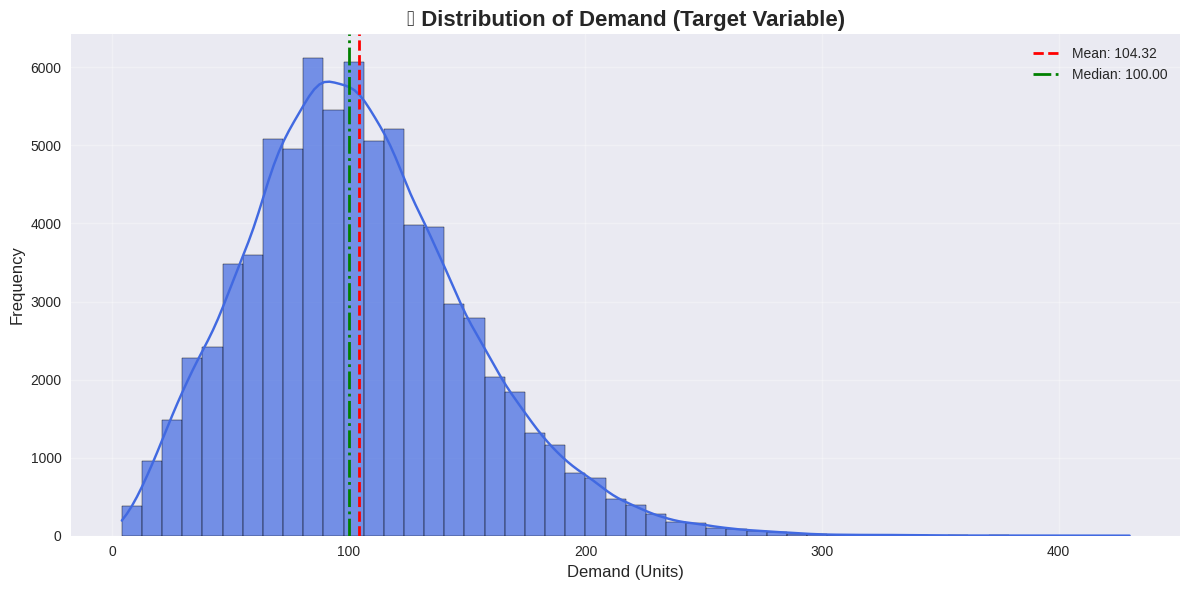

→ This plot shows how Demand is distributed.
→ Right-skewed distribution is common in demand data (many low demand days, few high spikes).

2️⃣ UNITS SOLD DISTRIBUTION
----------------------------------------------------------------------


/tmp/ipykernel_55/3225581481.py:53: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


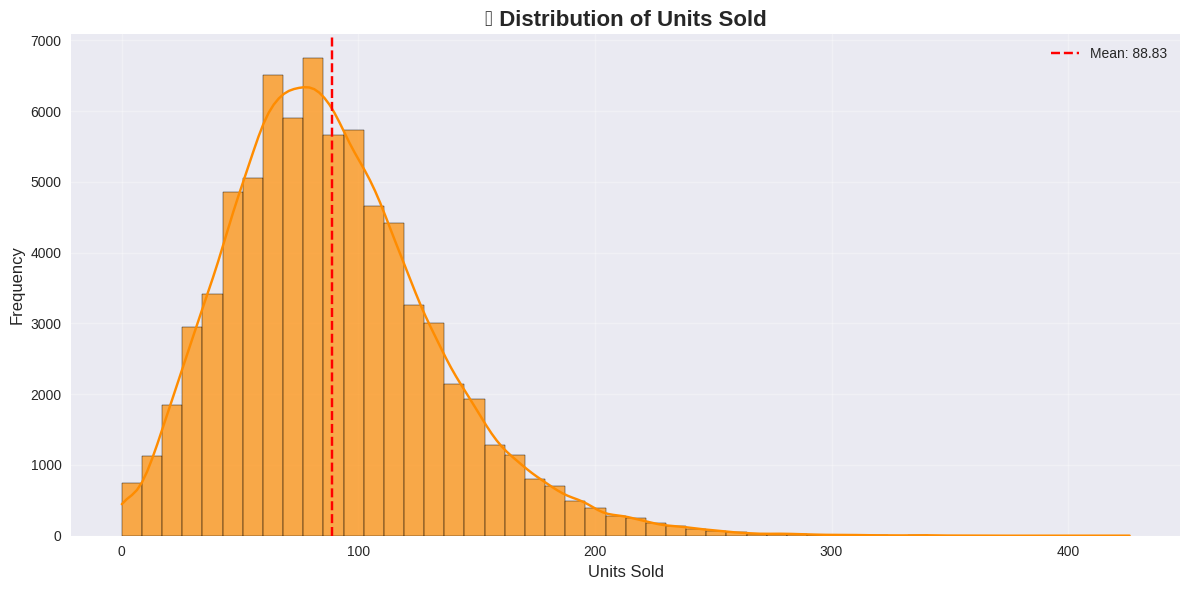

→ Shows actual sales volume distribution.

3️⃣ INVENTORY LEVEL DISTRIBUTION
----------------------------------------------------------------------


/tmp/ipykernel_55/3225581481.py:70: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


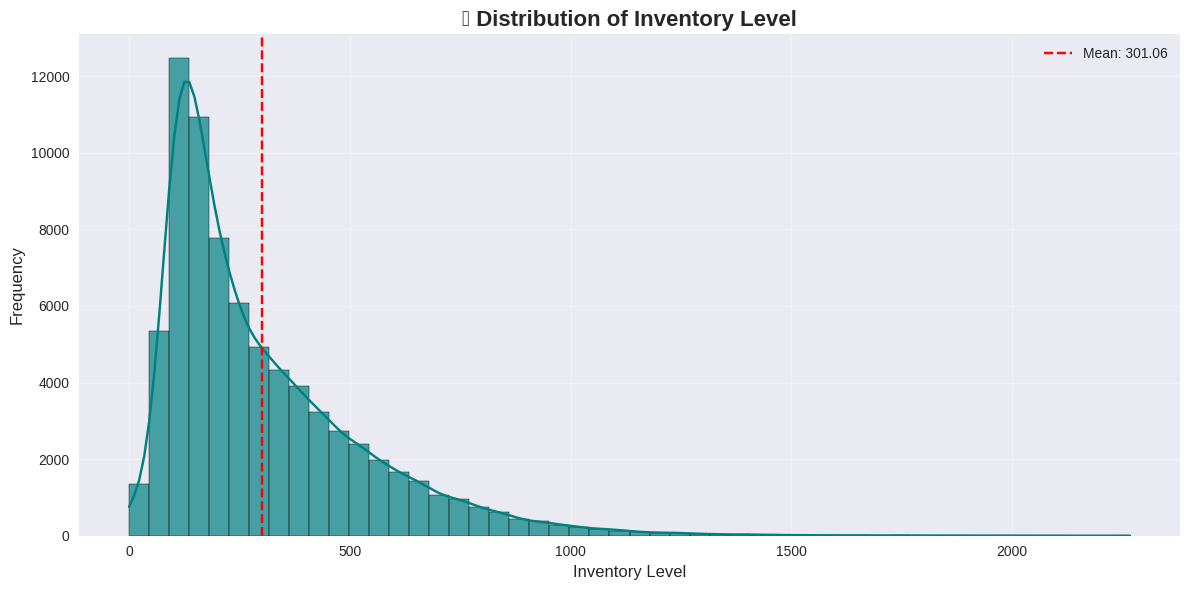

→ Helps understand stock levels across products and stores.

4️⃣ PRICE DISTRIBUTION
----------------------------------------------------------------------


/tmp/ipykernel_55/3225581481.py:87: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


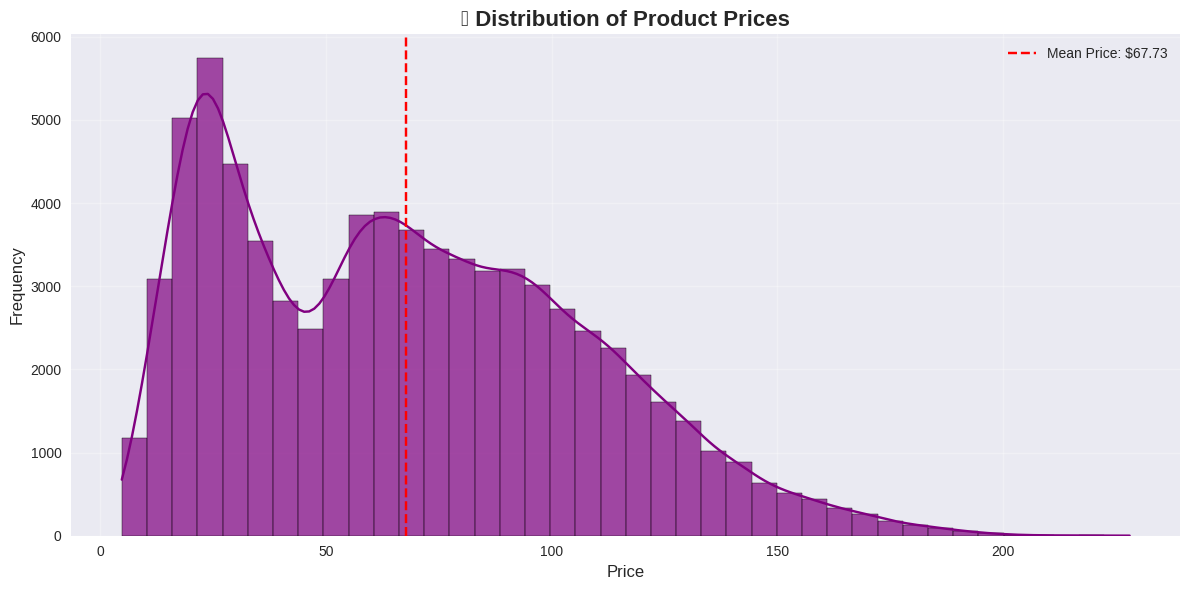

→ Shows pricing strategy across all products.

5️⃣ DISCOUNT DISTRIBUTION
----------------------------------------------------------------------


/tmp/ipykernel_55/3225581481.py:104: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/3225581481.py:104: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


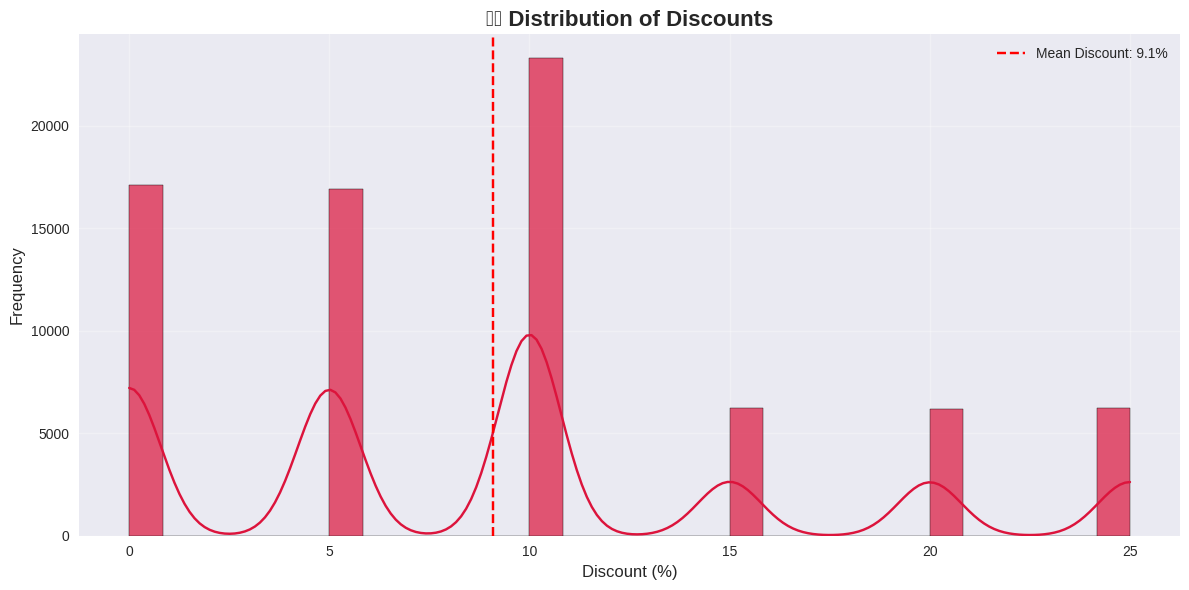

→ Most products have low discounts, few have high promotional discounts.

6️⃣ COMPETITOR PRICING DISTRIBUTION
----------------------------------------------------------------------


/tmp/ipykernel_55/3225581481.py:122: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


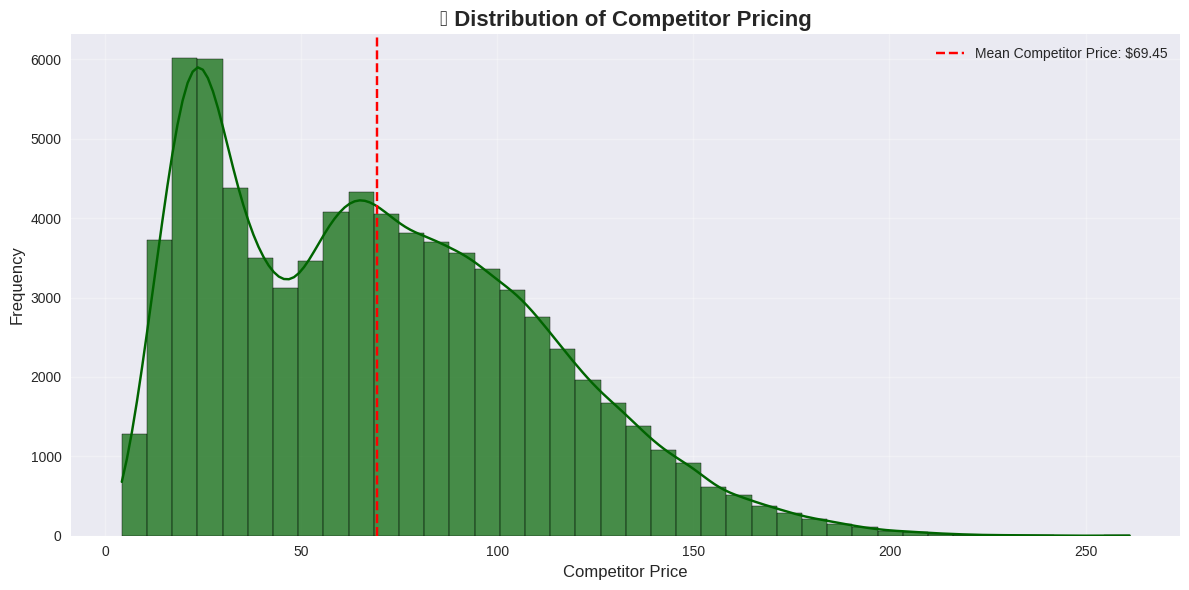

→ Useful to compare our pricing vs competitors.

7️⃣ UNITS ORDERED DISTRIBUTION
----------------------------------------------------------------------


/tmp/ipykernel_55/3225581481.py:137: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


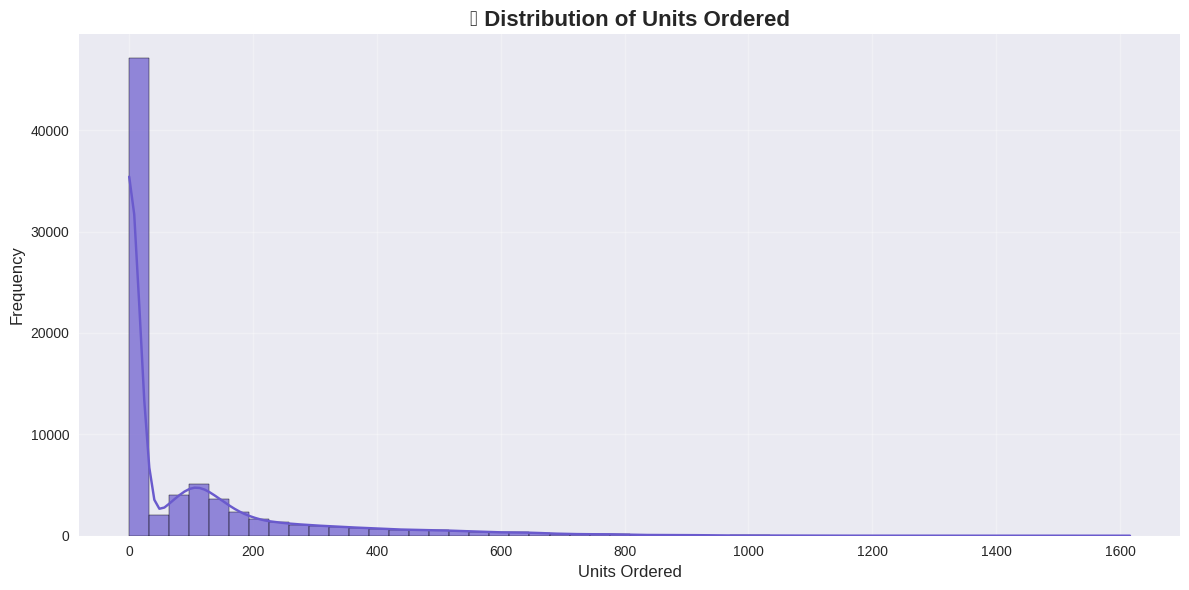

→ Shows replenishment behavior.


8️⃣ CATEGORY-WISE DEMAND DISTRIBUTION (Comparative)
----------------------------------------------------------------------


/tmp/ipykernel_55/3225581481.py:151: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Category')
/tmp/ipykernel_55/3225581481.py:153: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


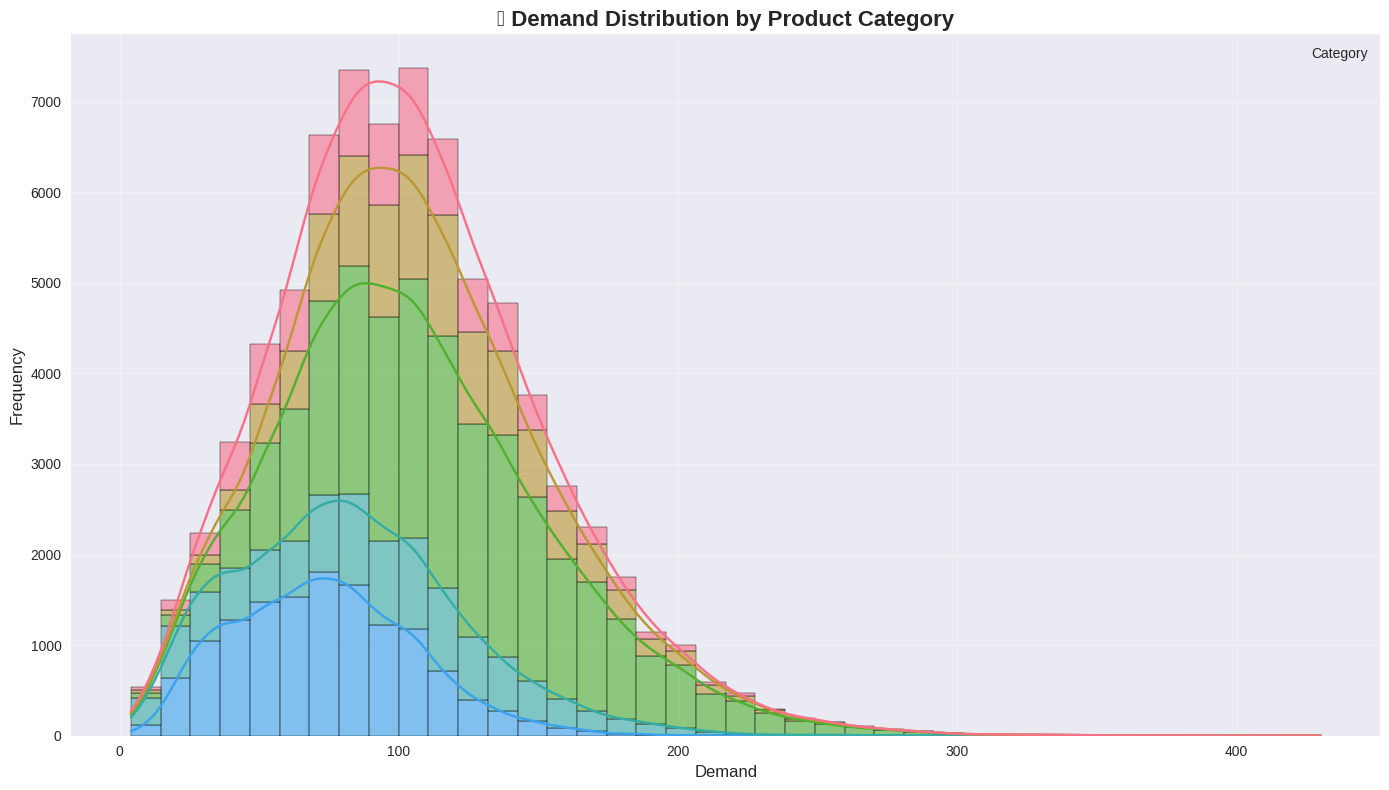

→ Compares demand patterns across Electronics, Clothing, Groceries, etc.

                            📋 KEY INSIGHTS FROM DISTRIBUTIONS                             
• Demand is right-skewed (Skewness: 0.61)
• Average Daily Demand     : 104.32 units
• Median Daily Demand      : 100.00 units
• Maximum Demand Recorded  : 430 units
• Most products have discounts between 0% to 25%


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for beautiful plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 10)

# Load the cleaned dataset
df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("📊✨ IMPORTANT HISTOGRAMS ✨📊\n")
print("="*90)
print("🎯 DISTRIBUTION ANALYSIS OF KEY VARIABLES".center(90))
print("="*90 + "\n")

# ====================== 1. TARGET VARIABLE - DEMAND ======================
print("1️⃣ DEMAND DISTRIBUTION (Target Variable)")
print("-" * 70)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Demand', kde=True, bins=50, color='royalblue', alpha=0.7)
plt.title('📈 Distribution of Demand (Target Variable)', fontsize=16, fontweight='bold')
plt.xlabel('Demand (Units)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

# Add mean and median lines
plt.axvline(df['Demand'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['Demand'].mean():.2f}")
plt.axvline(df['Demand'].median(), color='green', linestyle='-.', linewidth=2, label=f"Median: {df['Demand'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

print("→ This plot shows how Demand is distributed.")
print("→ Right-skewed distribution is common in demand data (many low demand days, few high spikes).\n")

# ====================== 2. UNITS SOLD ======================
print("2️⃣ UNITS SOLD DISTRIBUTION")
print("-" * 70)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Units Sold', kde=True, bins=50, color='darkorange', alpha=0.7)
plt.title('📦 Distribution of Units Sold', fontsize=16, fontweight='bold')
plt.xlabel('Units Sold', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['Units Sold'].mean(), color='red', linestyle='--', label=f"Mean: {df['Units Sold'].mean():.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Shows actual sales volume distribution.\n")

# ====================== 3. INVENTORY LEVEL ======================
print("3️⃣ INVENTORY LEVEL DISTRIBUTION")
print("-" * 70)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Inventory Level', kde=True, bins=50, color='teal', alpha=0.7)
plt.title('📚 Distribution of Inventory Level', fontsize=16, fontweight='bold')
plt.xlabel('Inventory Level', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['Inventory Level'].mean(), color='red', linestyle='--', label=f"Mean: {df['Inventory Level'].mean():.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Helps understand stock levels across products and stores.\n")

# ====================== 4. PRICE DISTRIBUTION ======================
print("4️⃣ PRICE DISTRIBUTION")
print("-" * 70)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Price', kde=True, bins=40, color='purple', alpha=0.7)
plt.title('💰 Distribution of Product Prices', fontsize=16, fontweight='bold')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['Price'].mean(), color='red', linestyle='--', label=f"Mean Price: ${df['Price'].mean():.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Shows pricing strategy across all products.\n")

# ====================== 5. DISCOUNT DISTRIBUTION ======================
print("5️⃣ DISCOUNT DISTRIBUTION")
print("-" * 70)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Discount', kde=True, bins=30, color='crimson', alpha=0.7)
plt.title('🏷️ Distribution of Discounts', fontsize=16, fontweight='bold')
plt.xlabel('Discount (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['Discount'].mean(), color='red', linestyle='--', label=f"Mean Discount: {df['Discount'].mean():.1f}%")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Most products have low discounts, few have high promotional discounts.\n")

# ====================== 6. COMPETITOR PRICING ======================
print("6️⃣ COMPETITOR PRICING DISTRIBUTION")
print("-" * 70)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Competitor Pricing', kde=True, bins=40, color='darkgreen', alpha=0.7)
plt.title('🏪 Distribution of Competitor Pricing', fontsize=16, fontweight='bold')
plt.xlabel('Competitor Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['Competitor Pricing'].mean(), color='red', linestyle='--', 
            label=f"Mean Competitor Price: ${df['Competitor Pricing'].mean():.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Useful to compare our pricing vs competitors.\n")

# ====================== 7. UNITS ORDERED ======================
print("7️⃣ UNITS ORDERED DISTRIBUTION")
print("-" * 70)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Units Ordered', kde=True, bins=50, color='slateblue', alpha=0.7)
plt.title('📦 Distribution of Units Ordered', fontsize=16, fontweight='bold')
plt.xlabel('Units Ordered', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Shows replenishment behavior.\n")

# ====================== ADVANCED: CATEGORY-WISE DEMAND ======================
print("\n8️⃣ CATEGORY-WISE DEMAND DISTRIBUTION (Comparative)")
print("-" * 70)

plt.figure(figsize=(14, 8))
sns.histplot(data=df, x='Demand', hue='Category', kde=True, bins=40, alpha=0.6, multiple="stack")
plt.title('📊 Demand Distribution by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Demand', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(title='Category')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Compares demand patterns across Electronics, Clothing, Groceries, etc.\n")

# ====================== SUMMARY STATISTICS ======================
print("="*90)
print("📋 KEY INSIGHTS FROM DISTRIBUTIONS".center(90))
print("="*90)

print(f"• Demand is {'right-skewed' if df['Demand'].skew() > 0.5 else 'normally distributed'} "
      f"(Skewness: {df['Demand'].skew():.2f})")
print(f"• Average Daily Demand     : {df['Demand'].mean():.2f} units")
print(f"• Median Daily Demand      : {df['Demand'].median():.2f} units")
print(f"• Maximum Demand Recorded  : {df['Demand'].max():,} units")
print(f"• Most products have discounts between 0% to {df['Discount'].max():.0f}%")

📈✨ ALL IMPORTANT LINE PLOTS ✨📈

                                  🎯 TIME SERIES TREND ANALYSIS                                 



/tmp/ipykernel_55/94894549.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


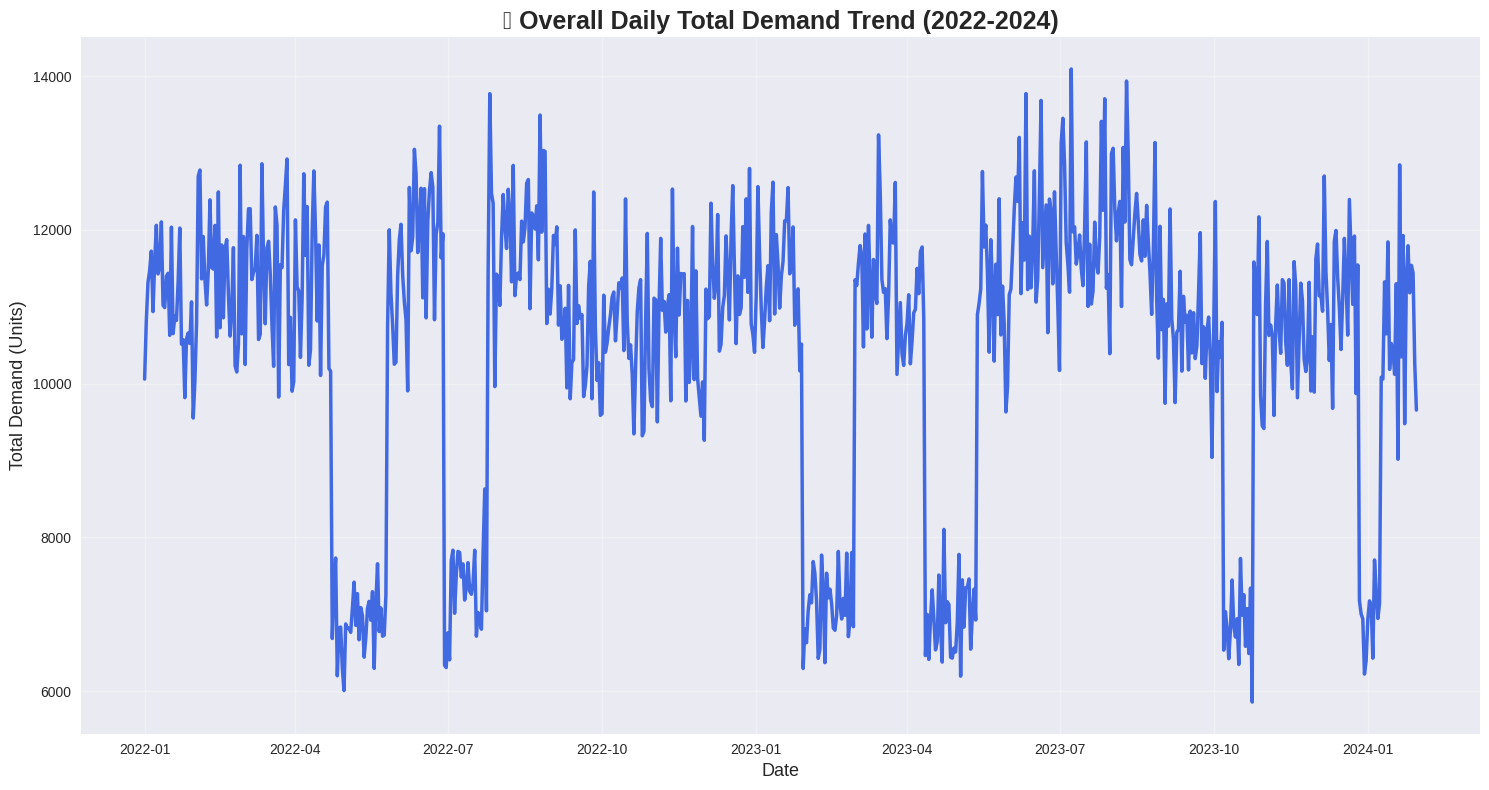

→ This lineplot shows total demand across ALL stores/products over time.
   Helps detect overall growth, seasonality, and major spikes/dips.



/tmp/ipykernel_55/94894549.py:47: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


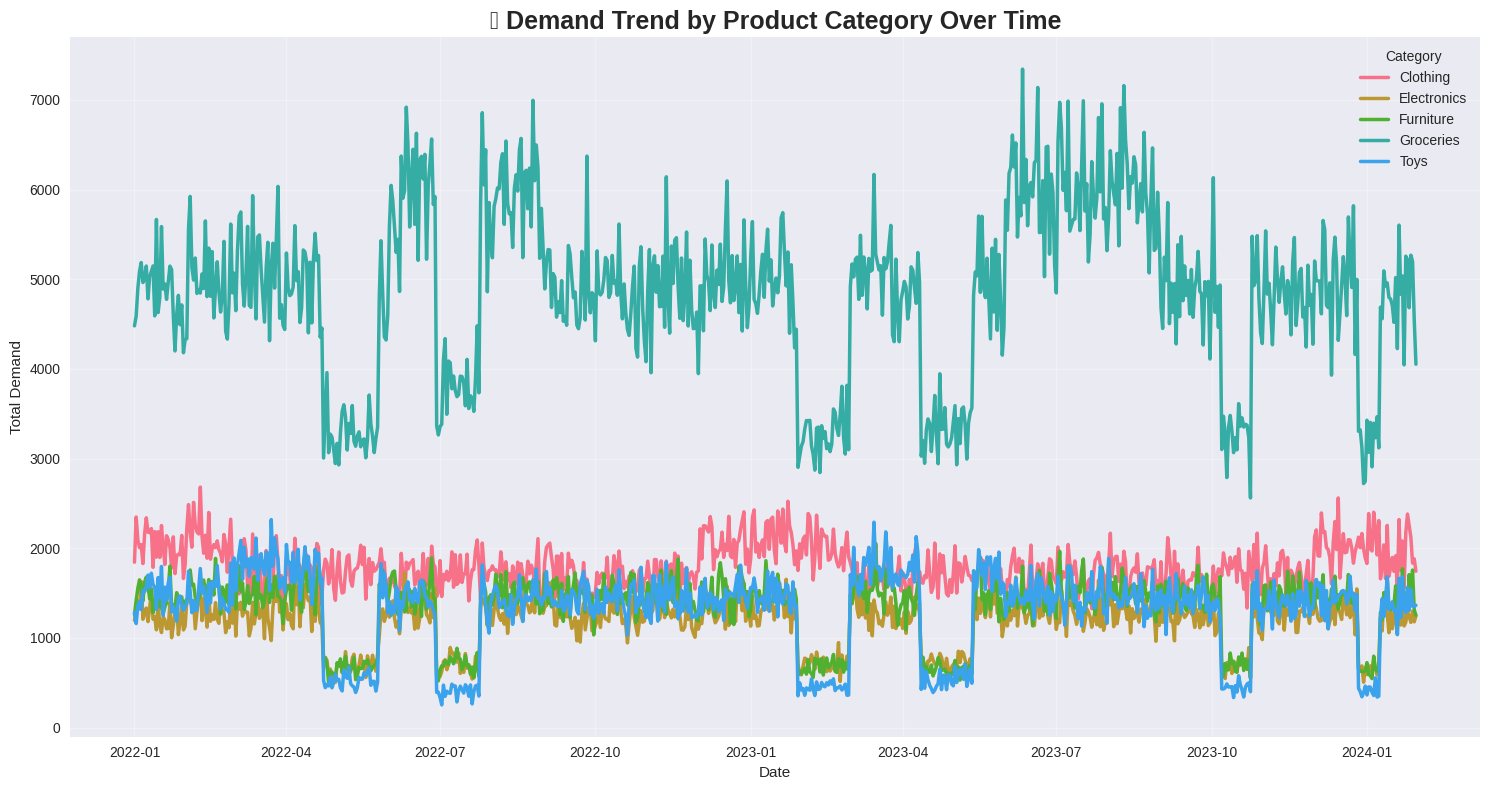

→ Compares how demand evolves for Electronics, Clothing, Groceries, Furniture & Toys.
   Identifies fastest growing categories.



/tmp/ipykernel_55/94894549.py:60: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/94894549.py:60: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


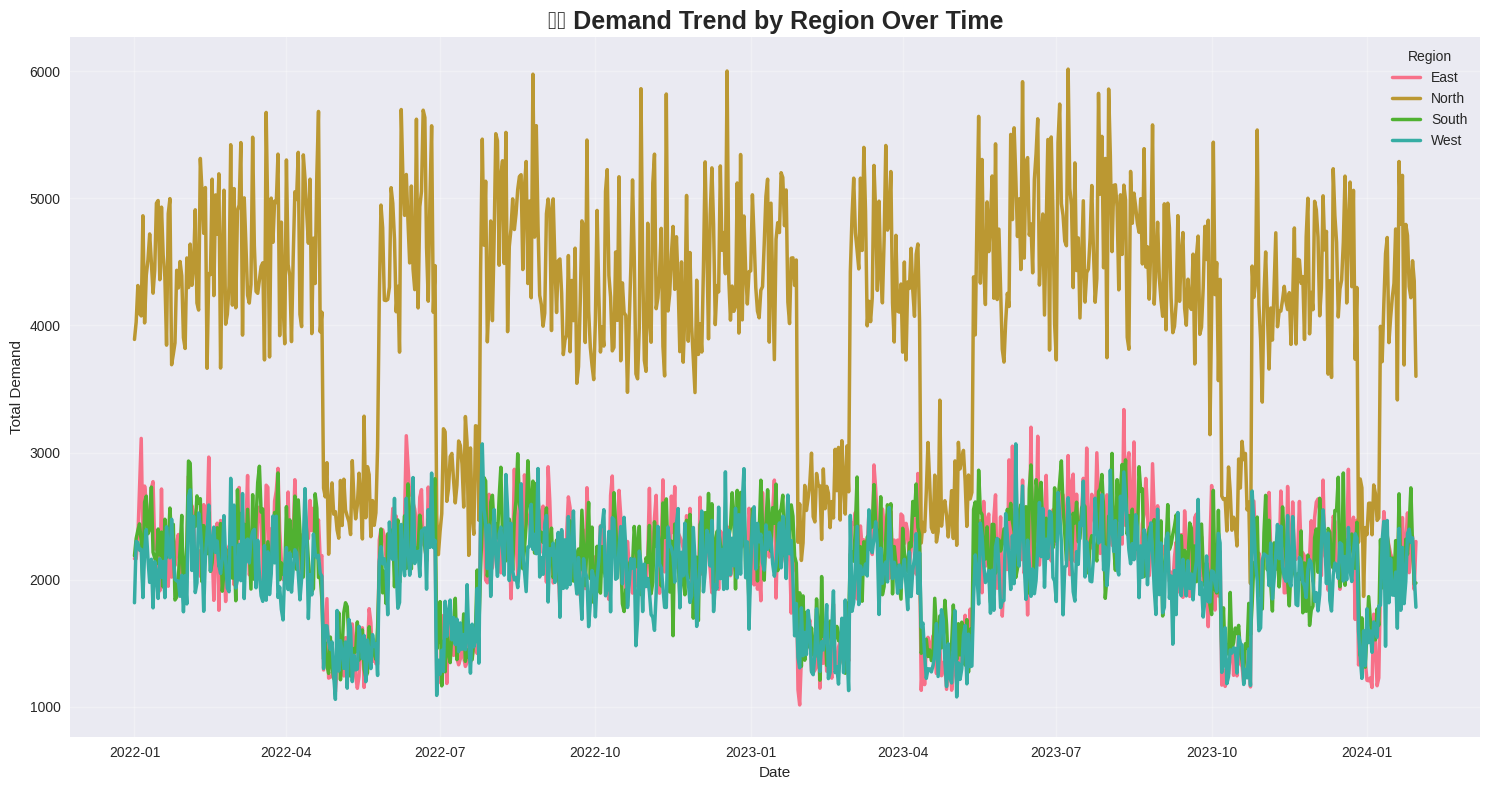

→ Shows performance of North, South, East, West regions.
   Highlights regional growth or decline.



/tmp/ipykernel_55/94894549.py:74: UserWarning: Glyph 127903 (\N{ADMISSION TICKETS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/94894549.py:74: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127903 (\N{ADMISSION TICKETS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


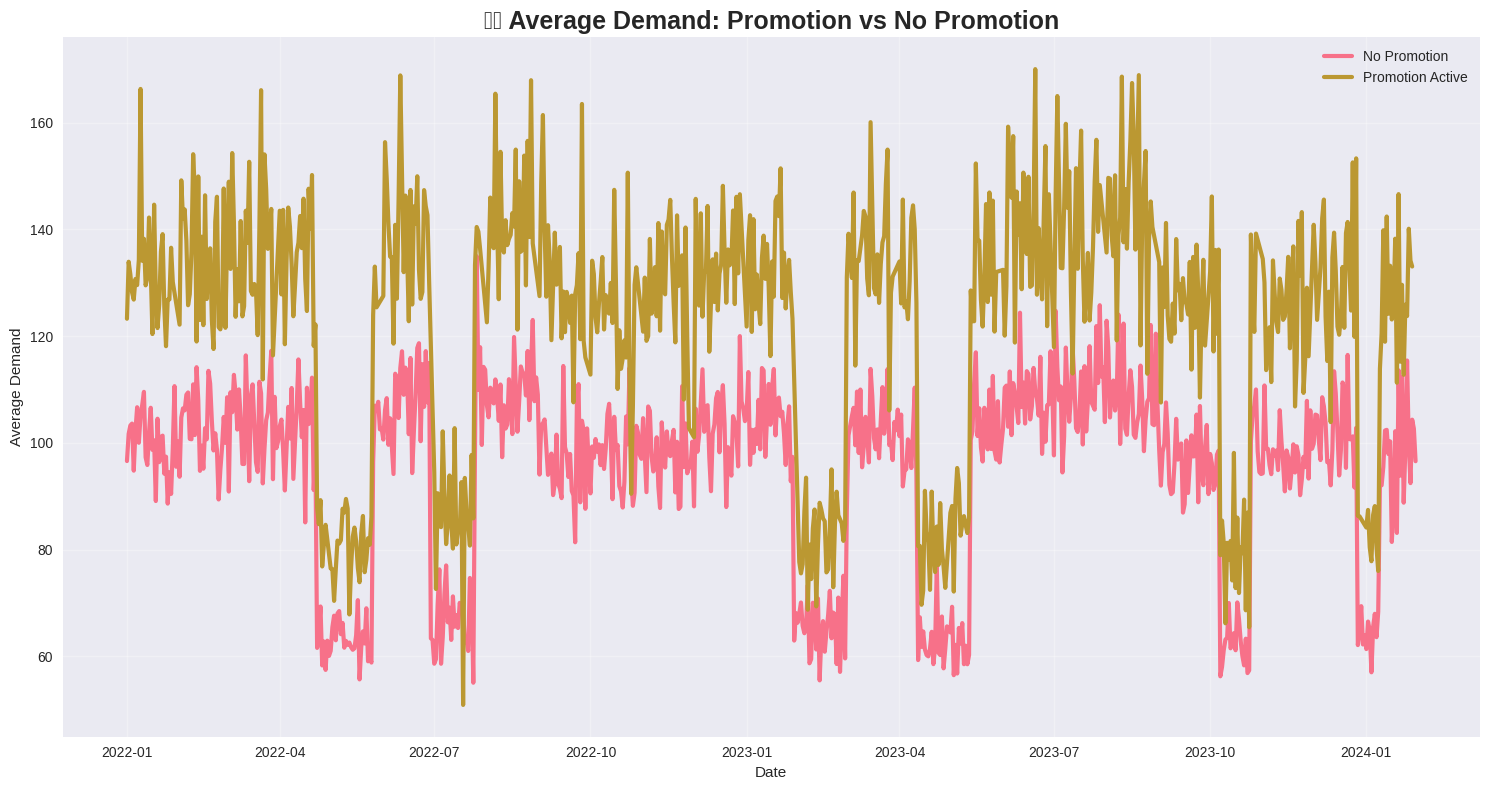

→ Clearly visualizes how promotions boost average demand over time.



/tmp/ipykernel_55/94894549.py:86: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/94894549.py:86: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


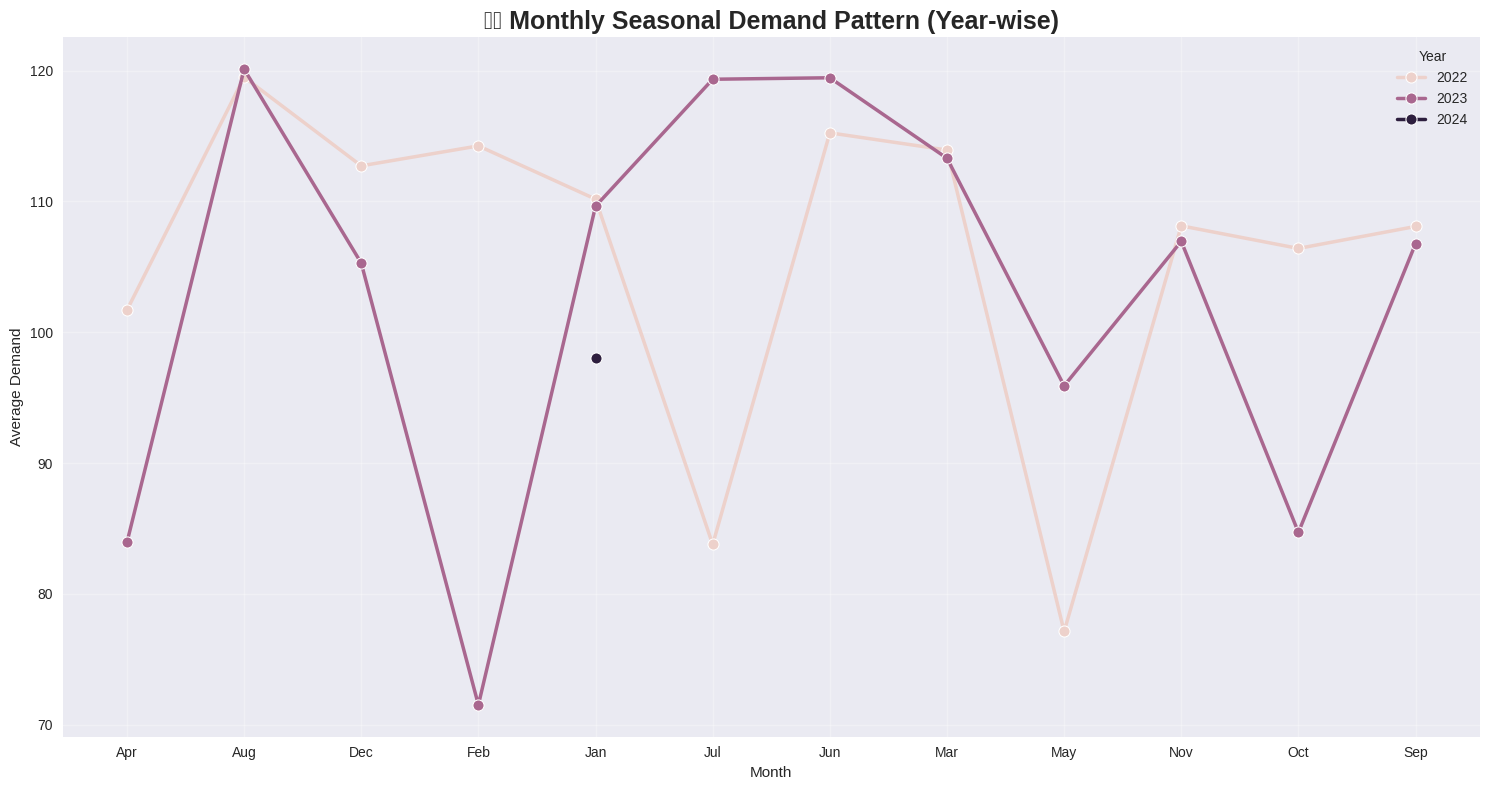

→ Reveals clear seasonal patterns (e.g., higher winter demand).



/tmp/ipykernel_55/94894549.py:100: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


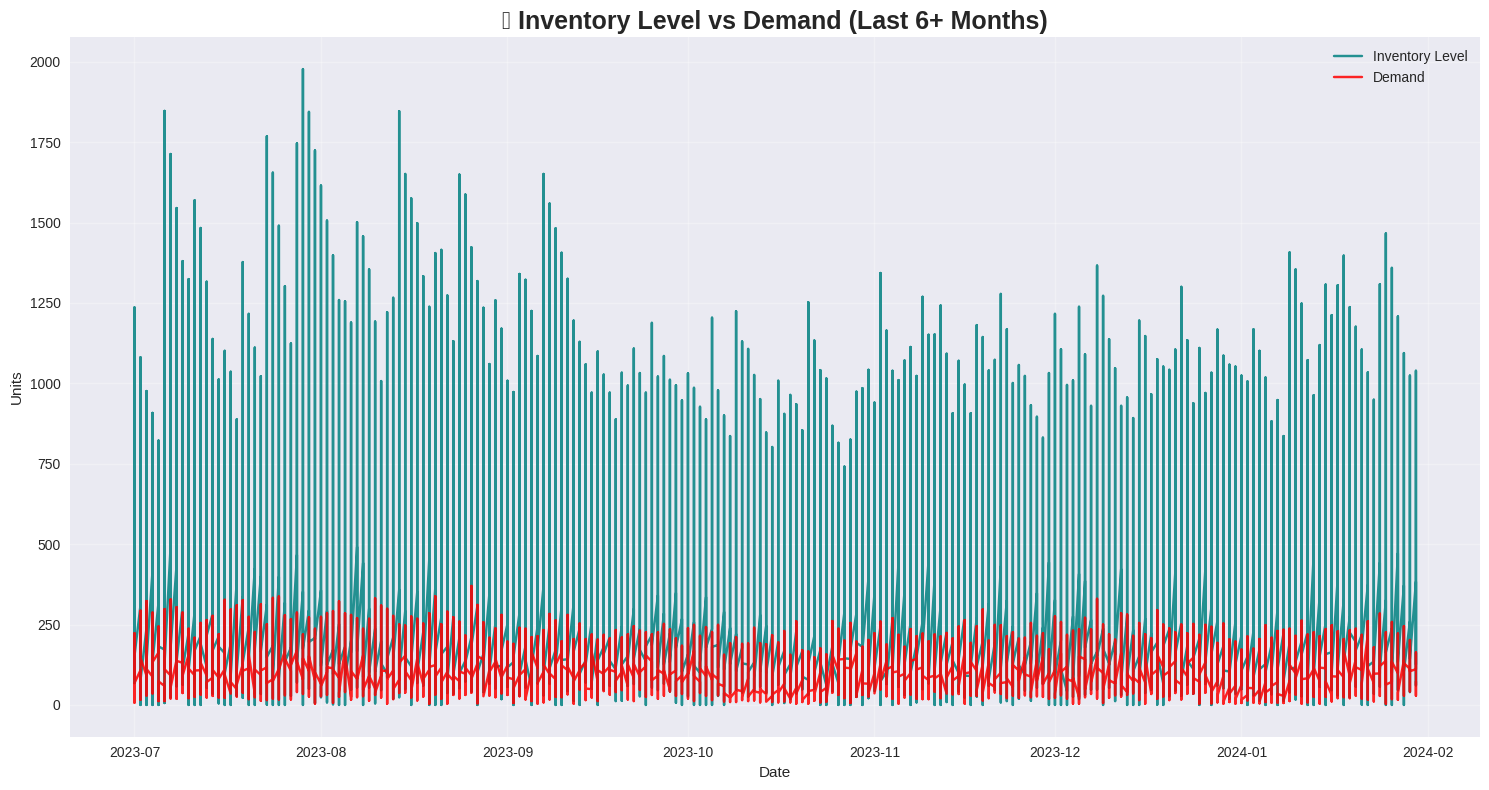

→ Dual lineplot shows how inventory tracks actual demand.

✅ All important lineplots generated!


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)

# Load cleaned dataset 
df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Auto-add all date features 
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday
df['Month_Name'] = df['Date'].dt.strftime('%b')

print("📈✨ ALL IMPORTANT LINE PLOTS ✨📈\n")
print("="*95)
print("🎯 TIME SERIES TREND ANALYSIS".center(95))
print("="*95 + "\n")

# 1. Overall Daily Total Demand Trend
daily_demand = df.groupby('Date')['Demand'].sum().reset_index()
plt.figure()
plt.plot(daily_demand['Date'], daily_demand['Demand'], color='royalblue', linewidth=2.5)
plt.title('📊 Overall Daily Total Demand Trend (2022-2024)', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=13)
plt.ylabel('Total Demand (Units)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ This lineplot shows total demand across ALL stores/products over time.\n   Helps detect overall growth, seasonality, and major spikes/dips.\n")

# 2. Demand Trend by Product Category
cat_demand = df.groupby(['Date', 'Category'])['Demand'].sum().reset_index()
plt.figure()
sns.lineplot(data=cat_demand, x='Date', y='Demand', hue='Category', linewidth=2.5)
plt.title('📦 Demand Trend by Product Category Over Time', fontsize=18, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Demand')
plt.legend(title='Category')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Compares how demand evolves for Electronics, Clothing, Groceries, Furniture & Toys.\n   Identifies fastest growing categories.\n")

# 3. Demand Trend by Region
reg_demand = df.groupby(['Date', 'Region'])['Demand'].sum().reset_index()
plt.figure()
sns.lineplot(data=reg_demand, x='Date', y='Demand', hue='Region', linewidth=2.5)
plt.title('🗺️ Demand Trend by Region Over Time', fontsize=18, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Demand')
plt.legend(title='Region')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Shows performance of North, South, East, West regions.\n   Highlights regional growth or decline.\n")

# 4. Promotion Impact on Demand
promo_demand = df.groupby(['Date', 'Promotion'])['Demand'].mean().reset_index()
promo_demand['Promotion'] = promo_demand['Promotion'].map({0: 'No Promotion', 1: 'Promotion Active'})
plt.figure()
sns.lineplot(data=promo_demand, x='Date', y='Demand', hue='Promotion', linewidth=3)
plt.title('🎟️ Average Demand: Promotion vs No Promotion', fontsize=18, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Demand')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Clearly visualizes how promotions boost average demand over time.\n")

# 5. Monthly Seasonal Pattern (Year-wise)
monthly = df.groupby(['Year', 'Month_Name'])['Demand'].mean().reset_index()
plt.figure()
sns.lineplot(data=monthly, x='Month_Name', y='Demand', hue='Year', marker='o', linewidth=2.5, markersize=8)
plt.title('🌡️ Monthly Seasonal Demand Pattern (Year-wise)', fontsize=18, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Reveals clear seasonal patterns (e.g., higher winter demand).\n")

# 6. Inventory Level vs Demand (Recent Period)
recent = df[df['Date'] >= '2023-07-01']
plt.figure()
plt.plot(recent['Date'], recent['Inventory Level'], label='Inventory Level', color='teal', alpha=0.85)
plt.plot(recent['Date'], recent['Demand'], label='Demand', color='red', alpha=0.85)
plt.title('📦 Inventory Level vs Demand (Last 6+ Months)', fontsize=18, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Units')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Dual lineplot shows how inventory tracks actual demand.\n")

print("✅ All important lineplots generated!")

📊✨ IMPORTANT BAR PLOTS & COUNT PLOTS ✨📊

                      🎯 CATEGORICAL ANALYSIS - BARPLOTS & COUNTPLOTS                      

1️⃣ COUNTPLOT: Distribution of Product Categories
---------------------------------------------------------------------------


/tmp/ipykernel_55/1304792951.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette='viridis')
/tmp/ipykernel_55/1304792951.py:35: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


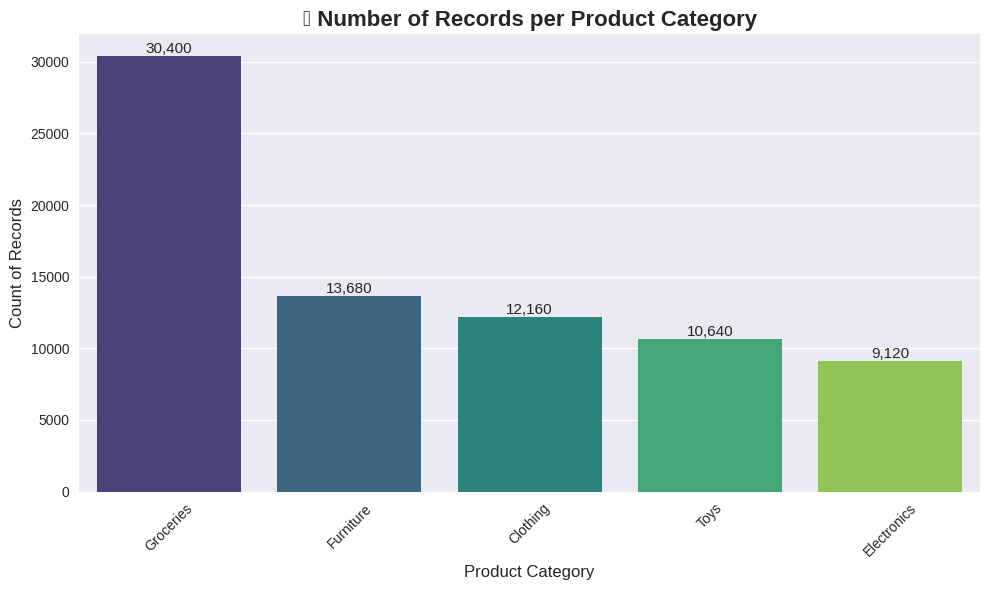

/tmp/ipykernel_55/1304792951.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Region', order=df['Region'].value_counts().index, palette='Set2')


→ This countplot shows how many records exist for each product category.

2️⃣ COUNTPLOT: Distribution by Region
---------------------------------------------------------------------------


/tmp/ipykernel_55/1304792951.py:54: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1304792951.py:54: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


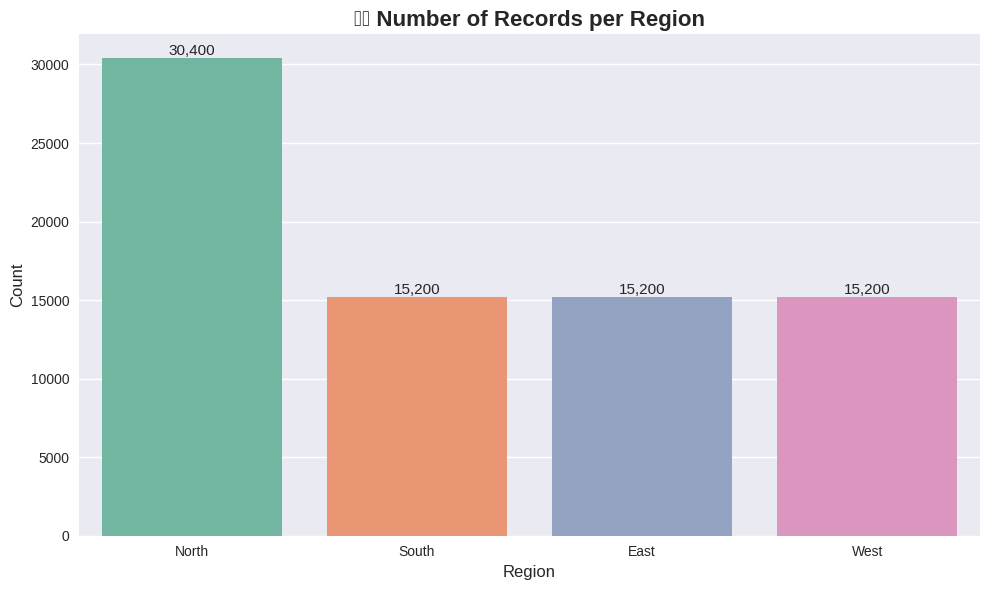

/tmp/ipykernel_55/1304792951.py:64: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Category', y='Demand', estimator='mean', ci=None, palette='viridis')
/tmp/ipykernel_55/1304792951.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Category', y='Demand', estimator='mean', ci=None, palette='viridis')


→ Shows data distribution across North, South, East, and West regions.

3️⃣ BARPLOT: Average Demand by Product Category
---------------------------------------------------------------------------


/tmp/ipykernel_55/1304792951.py:70: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


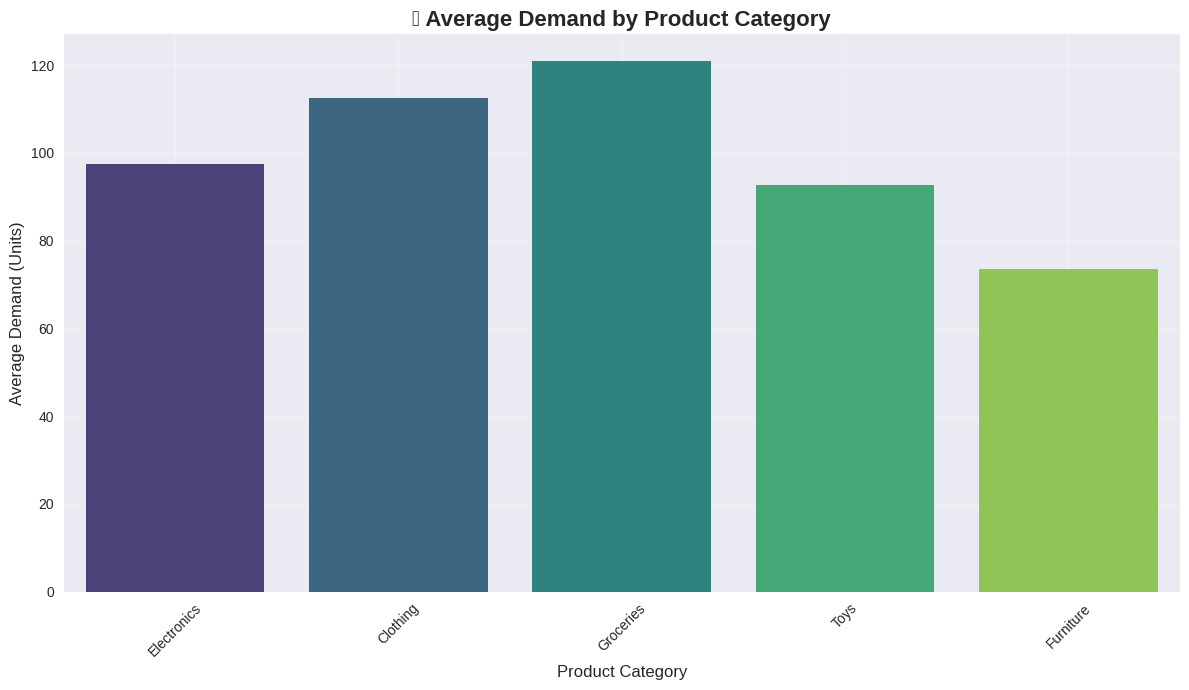

/tmp/ipykernel_55/1304792951.py:80: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Region', y='Demand', estimator='mean', ci=None, palette='Set2')
/tmp/ipykernel_55/1304792951.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Region', y='Demand', estimator='mean', ci=None, palette='Set2')


→ This barplot shows which category has the highest average daily demand.

4️⃣ BARPLOT: Average Demand by Region
---------------------------------------------------------------------------


/tmp/ipykernel_55/1304792951.py:85: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1304792951.py:85: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


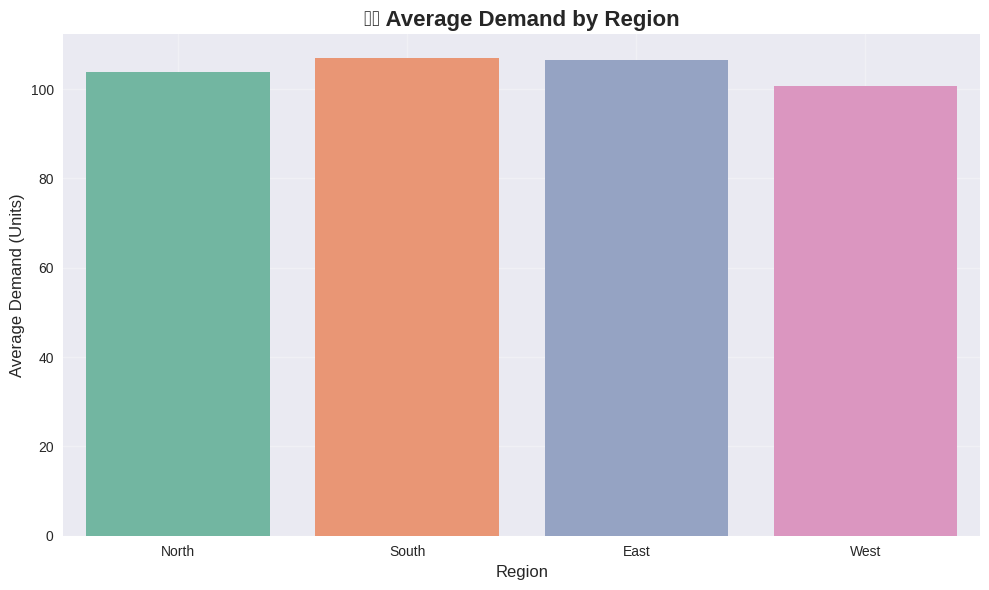

/tmp/ipykernel_55/1304792951.py:95: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Weather Condition', y='Demand', estimator='mean', ci=None, palette='coolwarm')


→ Helps identify which region has stronger demand.

5️⃣ BARPLOT: Average Demand by Weather Condition
---------------------------------------------------------------------------


/tmp/ipykernel_55/1304792951.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Weather Condition', y='Demand', estimator='mean', ci=None, palette='coolwarm')
/tmp/ipykernel_55/1304792951.py:100: UserWarning: Glyph 127780 (\N{WHITE SUN WITH SMALL CLOUD}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1304792951.py:100: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127780 (\N{WHITE SUN WITH SMALL CLOUD}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans

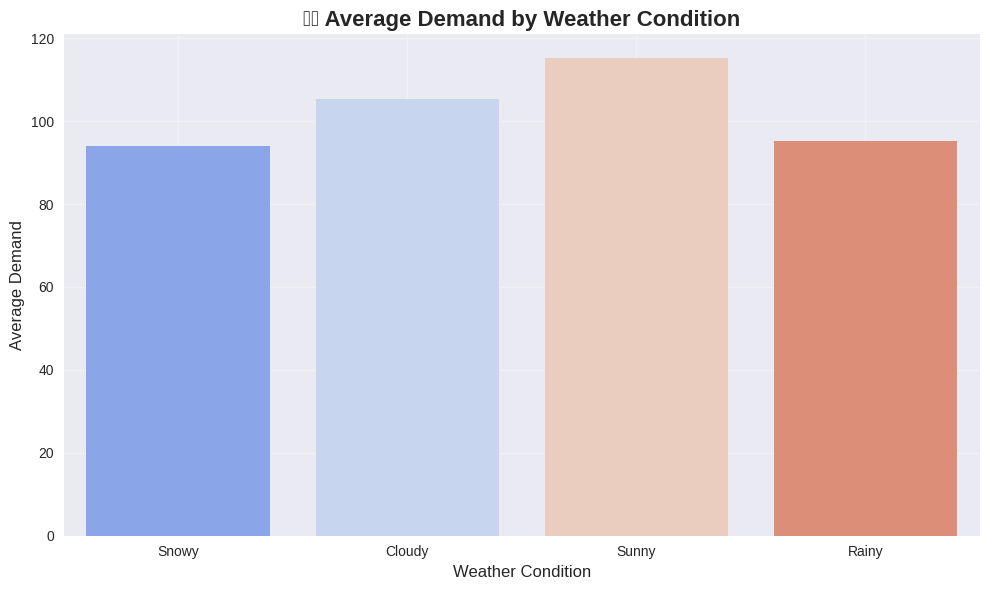

/tmp/ipykernel_55/1304792951.py:113: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=promo_df, x='Promotion_Status', y='Demand', estimator='mean', ci=None, palette='plasma')
/tmp/ipykernel_55/1304792951.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promo_df, x='Promotion_Status', y='Demand', estimator='mean', ci=None, palette='plasma')


→ Shows how weather affects demand (e.g., higher demand on snowy days?)

6️⃣ BARPLOT: Average Demand - Promotion vs No Promotion
---------------------------------------------------------------------------


/tmp/ipykernel_55/1304792951.py:118: UserWarning: Glyph 127903 (\N{ADMISSION TICKETS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1304792951.py:118: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127903 (\N{ADMISSION TICKETS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


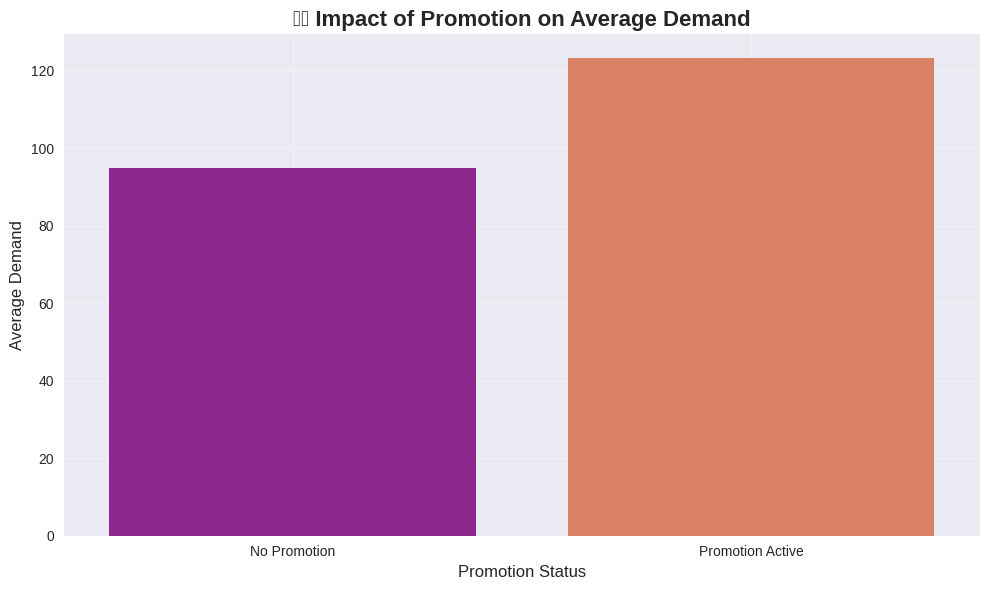

/tmp/ipykernel_55/1304792951.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=store_demand.head(10), x='Store ID', y='Demand', palette='mako')


→ Clearly shows how much promotions increase demand on average.

7️⃣ BARPLOT: Average Demand by Store (Top 10)
---------------------------------------------------------------------------


/tmp/ipykernel_55/1304792951.py:136: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


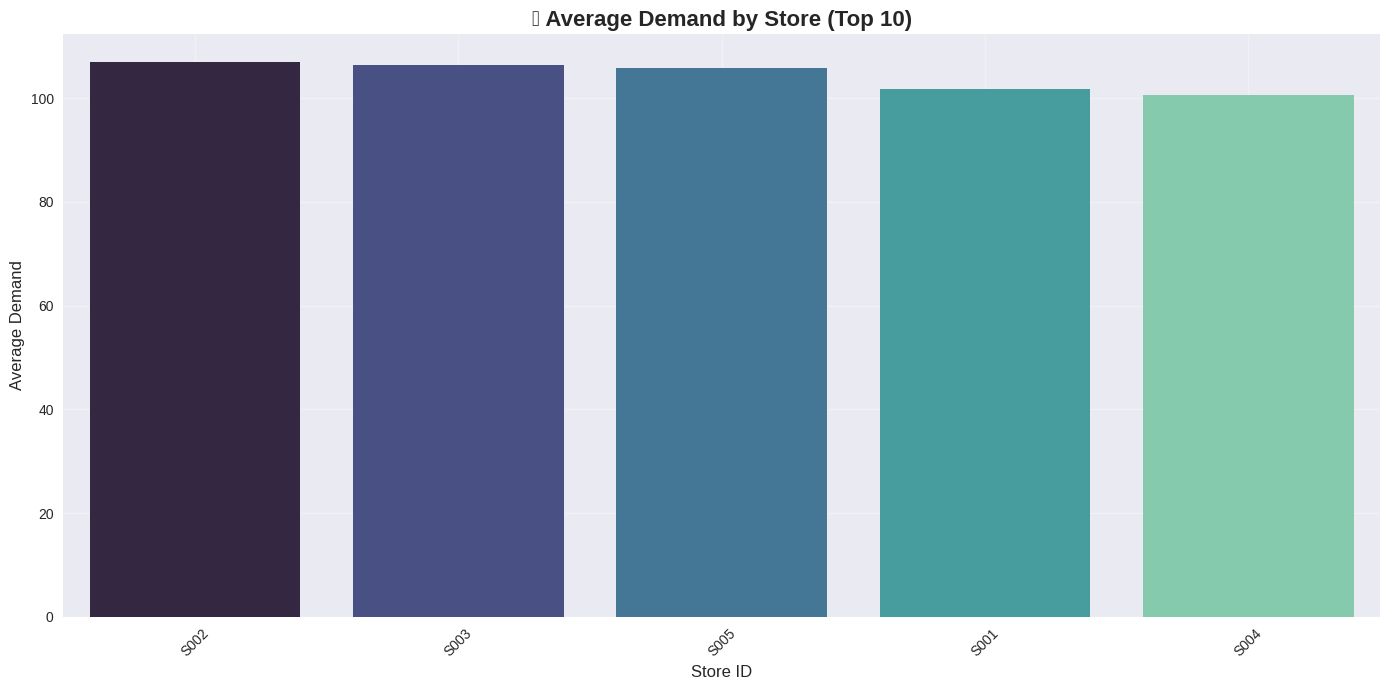

/tmp/ipykernel_55/1304792951.py:146: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Category', y='Discount', estimator='mean', ci=None, palette='rocket')


→ Identifies top performing stores by average demand.

8️⃣ BARPLOT: Average Discount Offered by Category
---------------------------------------------------------------------------


/tmp/ipykernel_55/1304792951.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Category', y='Discount', estimator='mean', ci=None, palette='rocket')
/tmp/ipykernel_55/1304792951.py:152: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1304792951.py:152: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


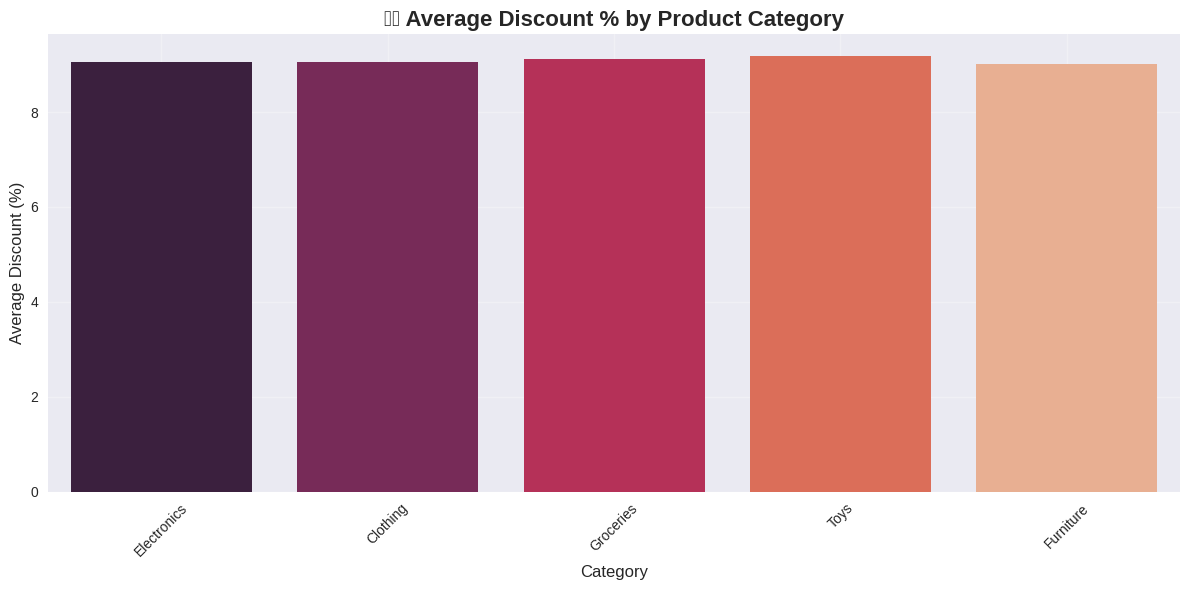

→ Shows which categories get more promotional discounts.

                        📋 KEY INSIGHTS FROM BARPLOTS & COUNTPLOTS                         

• Which categories and regions drive the most demand
• How weather and promotions affect sales
• Which stores are performing best
• Discount strategy effectiveness by category


💡 These plots are excellent for understanding categorical relationships with the target variable (Demand).


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set beautiful style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

# Load the cleaned dataset
df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("📊✨ IMPORTANT BAR PLOTS & COUNT PLOTS ✨📊\n")
print("="*90)
print("🎯 CATEGORICAL ANALYSIS - BARPLOTS & COUNTPLOTS".center(90))
print("="*90 + "\n")

# ====================== 1. COUNTPLOTS (Distribution of Categories) ======================
print("1️⃣ COUNTPLOT: Distribution of Product Categories")
print("-" * 75)

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette='viridis')
plt.title('📦 Number of Records per Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Count of Records', fontsize=12)
plt.xticks(rotation=45)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print("→ This countplot shows how many records exist for each product category.\n")

# ====================== 2. COUNTPLOT: Regions ======================
print("2️⃣ COUNTPLOT: Distribution by Region")
print("-" * 75)

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Region', order=df['Region'].value_counts().index, palette='Set2')
plt.title('🗺️ Number of Records per Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Count', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print("→ Shows data distribution across North, South, East, and West regions.\n")

# ====================== 3. BARPLOT: Average Demand by Category ======================
print("3️⃣ BARPLOT: Average Demand by Product Category")
print("-" * 75)

plt.figure(figsize=(12, 7))
sns.barplot(data=df, x='Category', y='Demand', estimator='mean', ci=None, palette='viridis')
plt.title('📈 Average Demand by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Average Demand (Units)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ This barplot shows which category has the highest average daily demand.\n")

# ====================== 4. BARPLOT: Average Demand by Region ======================
print("4️⃣ BARPLOT: Average Demand by Region")
print("-" * 75)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Region', y='Demand', estimator='mean', ci=None, palette='Set2')
plt.title('🗺️ Average Demand by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Demand (Units)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Helps identify which region has stronger demand.\n")

# ====================== 5. BARPLOT: Demand by Weather Condition ======================
print("5️⃣ BARPLOT: Average Demand by Weather Condition")
print("-" * 75)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Weather Condition', y='Demand', estimator='mean', ci=None, palette='coolwarm')
plt.title('🌤️ Average Demand by Weather Condition', fontsize=16, fontweight='bold')
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Average Demand', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Shows how weather affects demand (e.g., higher demand on snowy days?)\n")

# ====================== 6. BARPLOT: Promotion Impact ======================
print("6️⃣ BARPLOT: Average Demand - Promotion vs No Promotion")
print("-" * 75)

promo_df = df.copy()
promo_df['Promotion_Status'] = promo_df['Promotion'].map({0: 'No Promotion', 1: 'Promotion Active'})

plt.figure(figsize=(10, 6))
sns.barplot(data=promo_df, x='Promotion_Status', y='Demand', estimator='mean', ci=None, palette='plasma')
plt.title('🎟️ Impact of Promotion on Average Demand', fontsize=16, fontweight='bold')
plt.xlabel('Promotion Status', fontsize=12)
plt.ylabel('Average Demand', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Clearly shows how much promotions increase demand on average.\n")

# ====================== 7. BARPLOT: Average Demand by Store ======================
print("7️⃣ BARPLOT: Average Demand by Store (Top 10)")
print("-" * 75)

store_demand = df.groupby('Store ID')['Demand'].mean().reset_index().sort_values('Demand', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(data=store_demand.head(10), x='Store ID', y='Demand', palette='mako')
plt.title('🏪 Average Demand by Store (Top 10)', fontsize=16, fontweight='bold')
plt.xlabel('Store ID', fontsize=12)
plt.ylabel('Average Demand', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Identifies top performing stores by average demand.\n")

# ====================== 8. BARPLOT: Average Discount by Category ======================
print("8️⃣ BARPLOT: Average Discount Offered by Category")
print("-" * 75)

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Category', y='Discount', estimator='mean', ci=None, palette='rocket')
plt.title('🏷️ Average Discount % by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Discount (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Shows which categories get more promotional discounts.\n")

# ====================== SUMMARY ======================
print("="*90)
print("📋 KEY INSIGHTS FROM BARPLOTS & COUNTPLOTS".center(90))
print("="*90)
print("""
• Which categories and regions drive the most demand
• How weather and promotions affect sales
• Which stores are performing best
• Discount strategy effectiveness by category
""")

print("\n💡 These plots are excellent for understanding categorical relationships with the target variable (Demand).")

🥧✨ ALL IMPORTANT PIE PLOTS ✨🥧

                     🎯 PROPORTION ANALYSIS USING PIE CHARTS                     



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


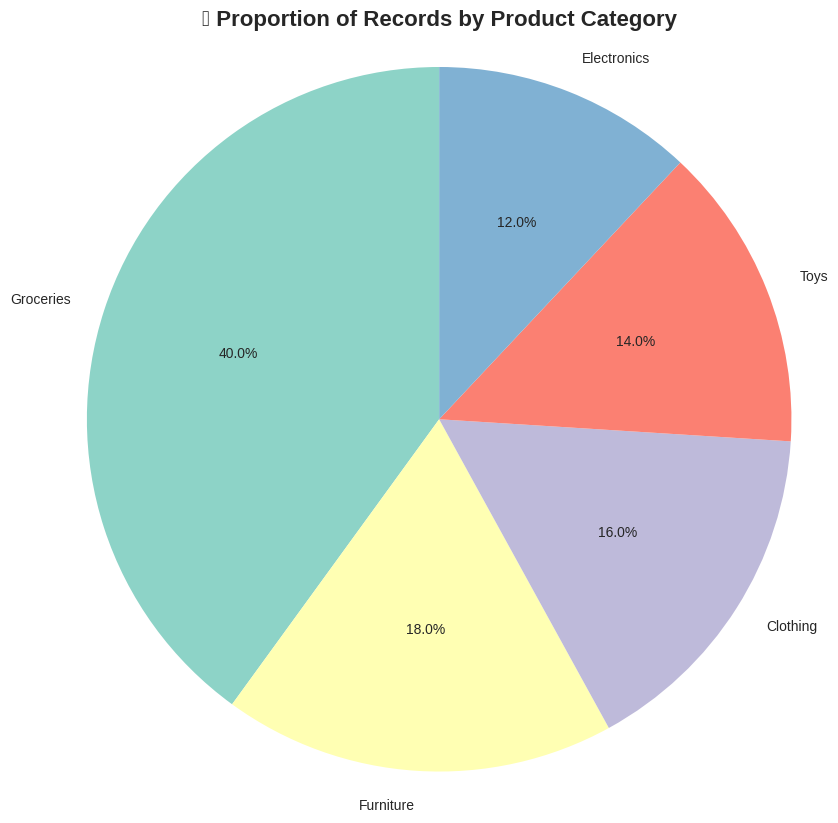

→ Pie chart shows what % of the entire dataset belongs to each category.



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


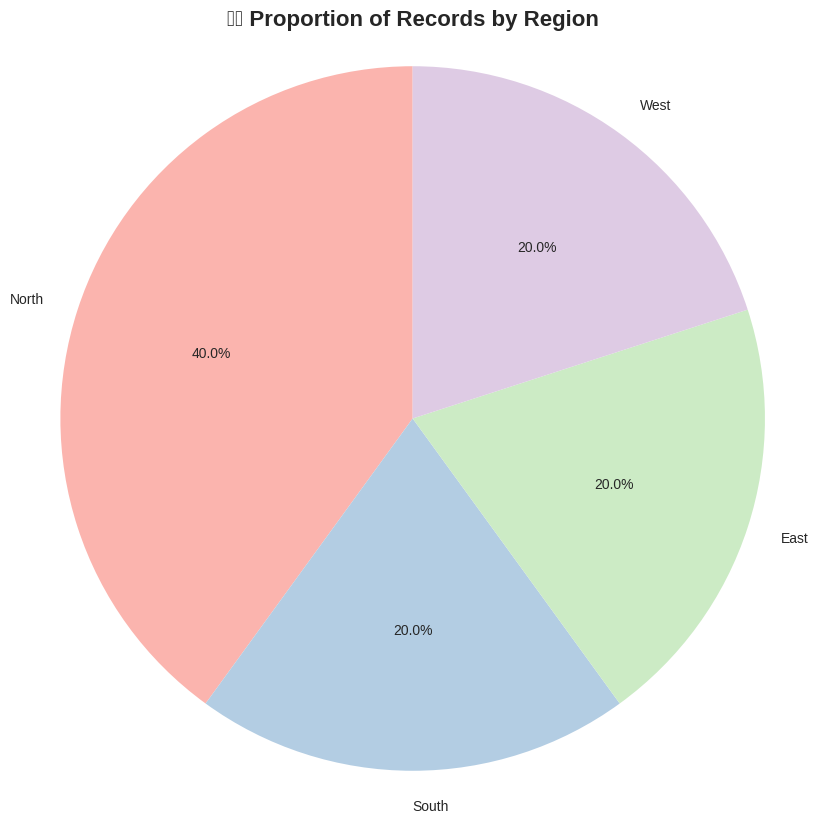

→ Shows data distribution across North, South, East, West.



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127903 (\N{ADMISSION TICKETS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


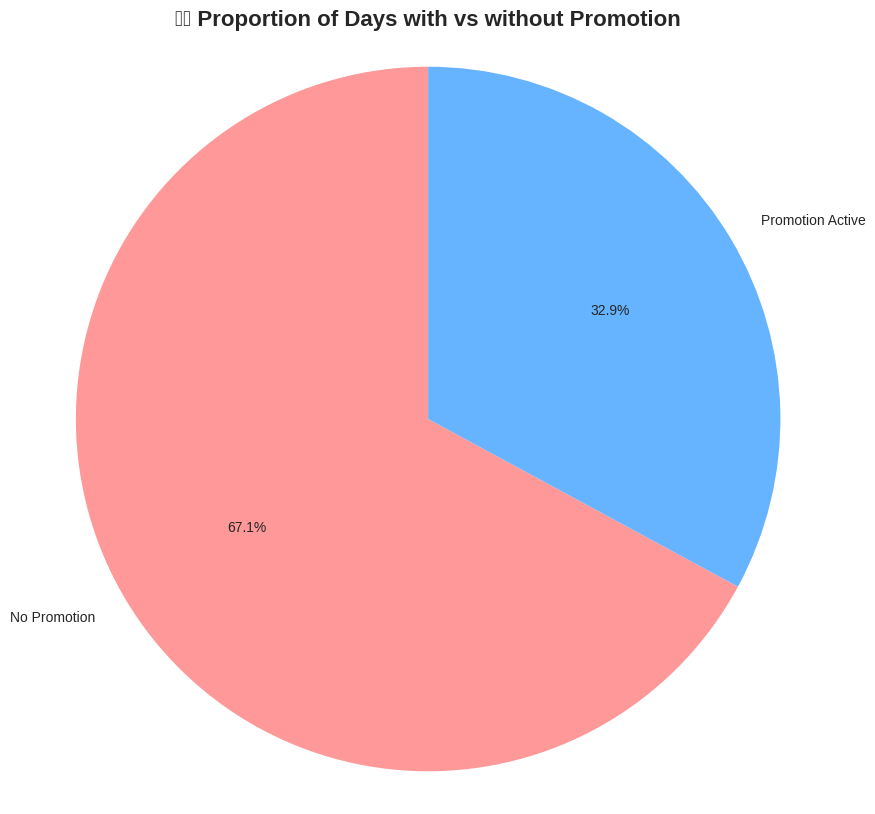

→ Shows how often promotions run in the dataset.

✅ All important pie plots generated!


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 10)

df = pd.read_csv('demand_forecasting_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("🥧✨ ALL IMPORTANT PIE PLOTS ✨🥧\n")
print("="*80)
print("🎯 PROPORTION ANALYSIS USING PIE CHARTS".center(80))
print("="*80 + "\n")

# 1. Proportion of Records by Category
cat_counts = df['Category'].value_counts()
plt.figure()
plt.pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
plt.title('📦 Proportion of Records by Product Category', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()
print("→ Pie chart shows what % of the entire dataset belongs to each category.\n")

# 2. Proportion by Region
reg_counts = df['Region'].value_counts()
plt.figure()
plt.pie(reg_counts, labels=reg_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
plt.title('🗺️ Proportion of Records by Region', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()
print("→ Shows data distribution across North, South, East, West.\n")

# 3. Promotion Status Distribution
promo_counts = df['Promotion'].value_counts()
labels = ['No Promotion', 'Promotion Active']
plt.figure()
plt.pie(promo_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('🎟️ Proportion of Days with vs without Promotion', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()
print("→ Shows how often promotions run in the dataset.\n")

print("✅ All important pie plots generated!")

📦✨ IMPORTANT BOXPLOTS ✨📦

                   🎯 DISTRIBUTION & OUTLIER ANALYSIS USING BOXPLOTS                  



/tmp/ipykernel_55/1887851366.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Demand', palette='viridis')
/tmp/ipykernel_55/1887851366.py:27: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


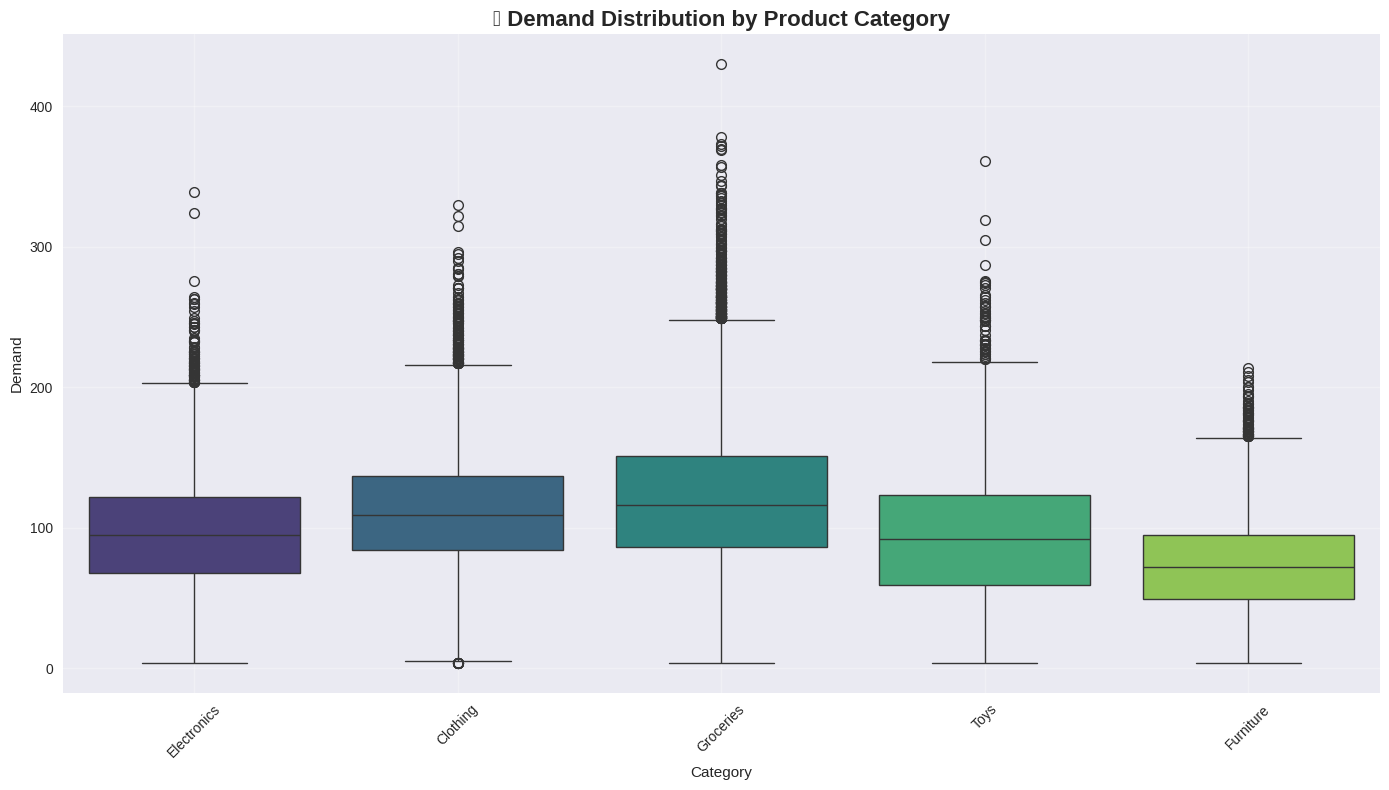

→ Boxplot shows spread, median, and outliers of Demand for each category.



/tmp/ipykernel_55/1887851366.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Region', y='Demand', palette='Set2')
/tmp/ipykernel_55/1887851366.py:38: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1887851366.py:38: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


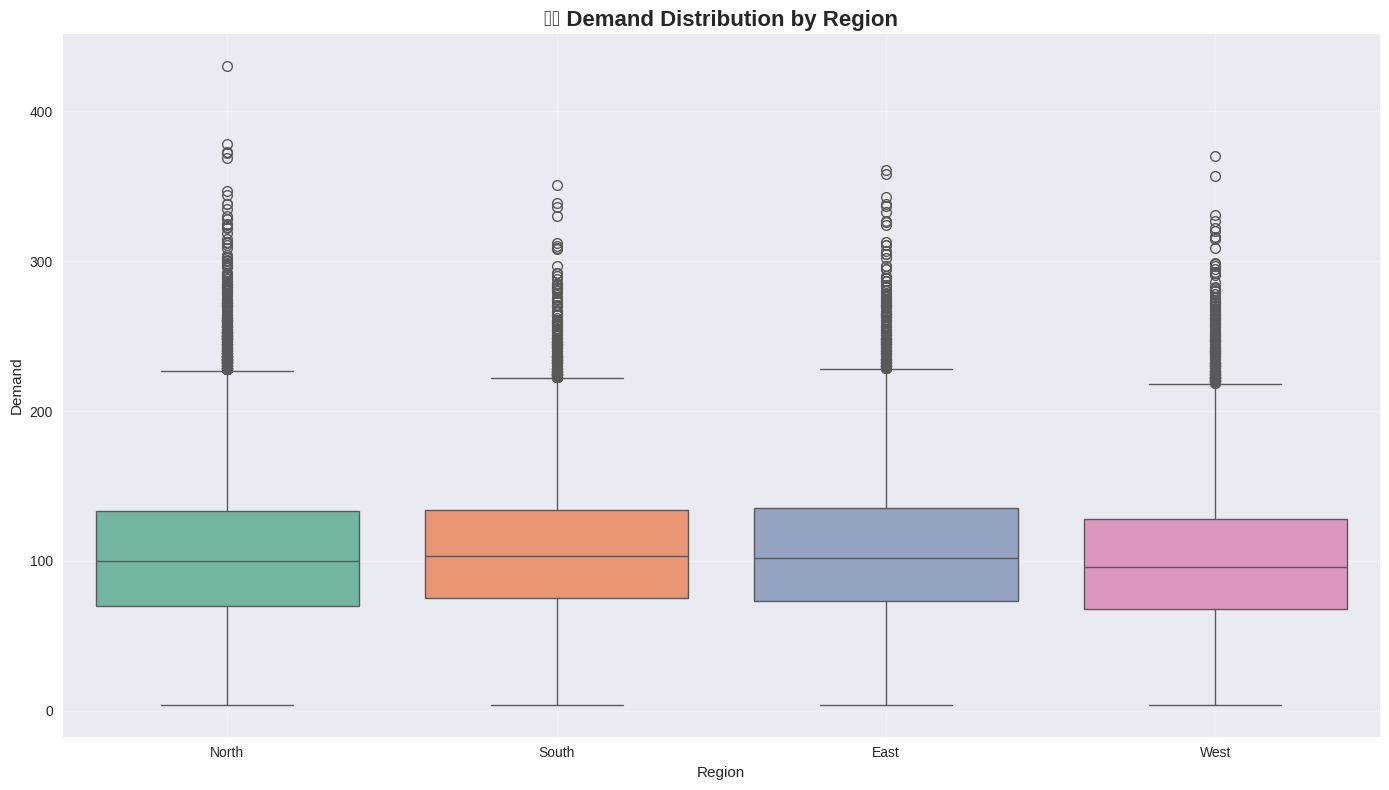

/tmp/ipykernel_55/1887851366.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Weather Condition', y='Demand', palette='coolwarm')


→ Compares demand variability across North, South, East, West.



/tmp/ipykernel_55/1887851366.py:49: UserWarning: Glyph 127780 (\N{WHITE SUN WITH SMALL CLOUD}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1887851366.py:49: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127780 (\N{WHITE SUN WITH SMALL CLOUD}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


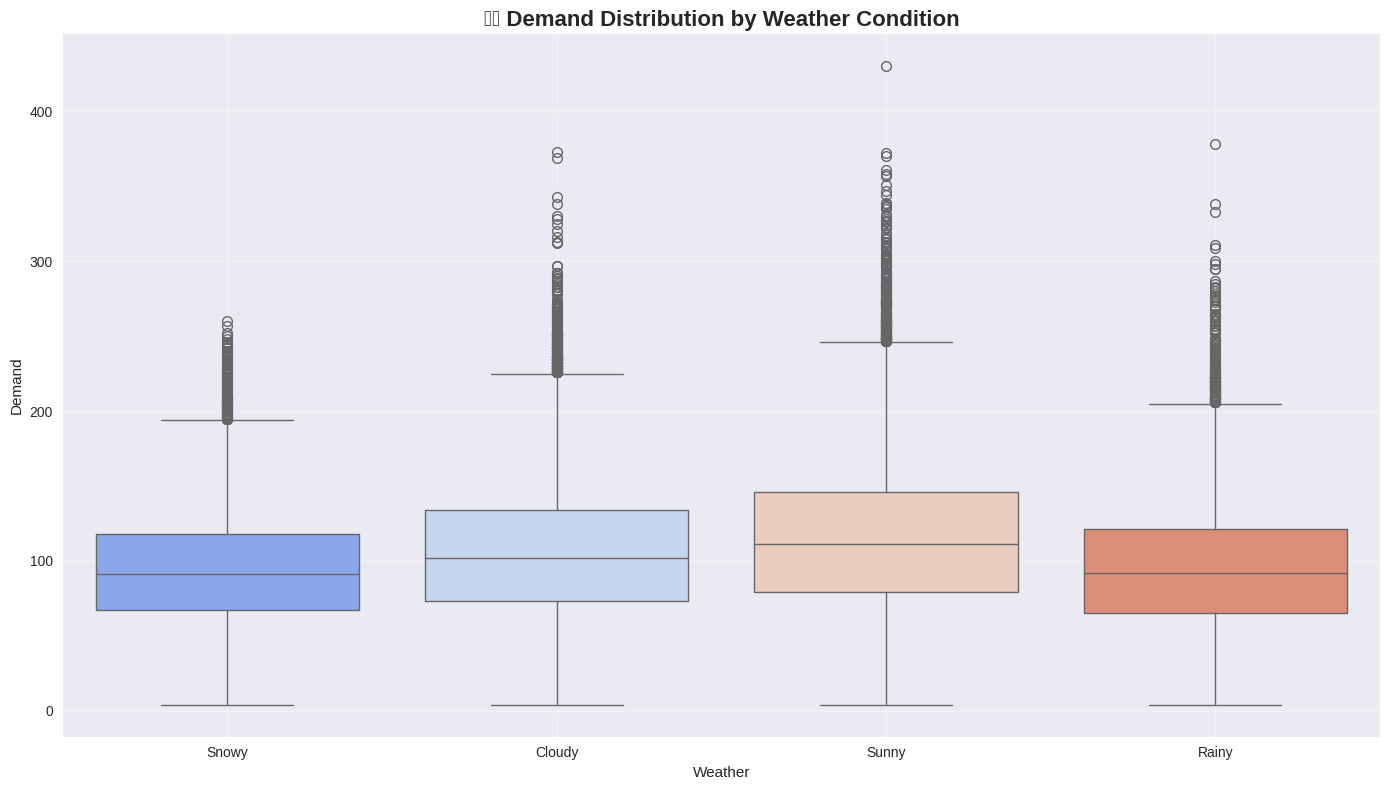

→ Reveals how weather affects demand spread and outliers.



/tmp/ipykernel_55/1887851366.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Promotion_Status', y='Demand', palette='plasma')
/tmp/ipykernel_55/1887851366.py:61: UserWarning: Glyph 127903 (\N{ADMISSION TICKETS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1887851366.py:61: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127903 (\N{ADMISSION TICKETS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


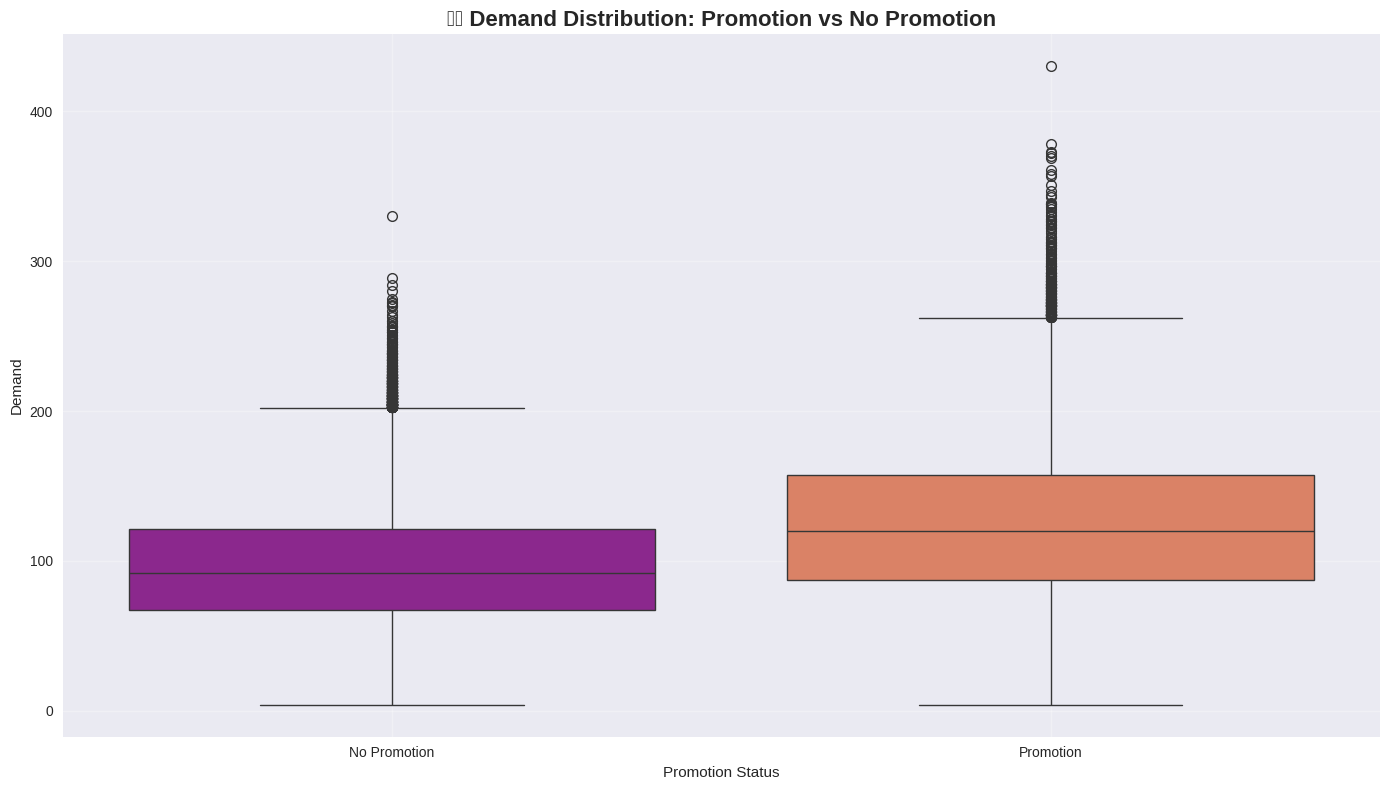

→ Shows if promotions create higher demand and more outliers.



/tmp/ipykernel_55/1887851366.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Store ID', y='Demand', palette='mako')
/tmp/ipykernel_55/1887851366.py:72: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


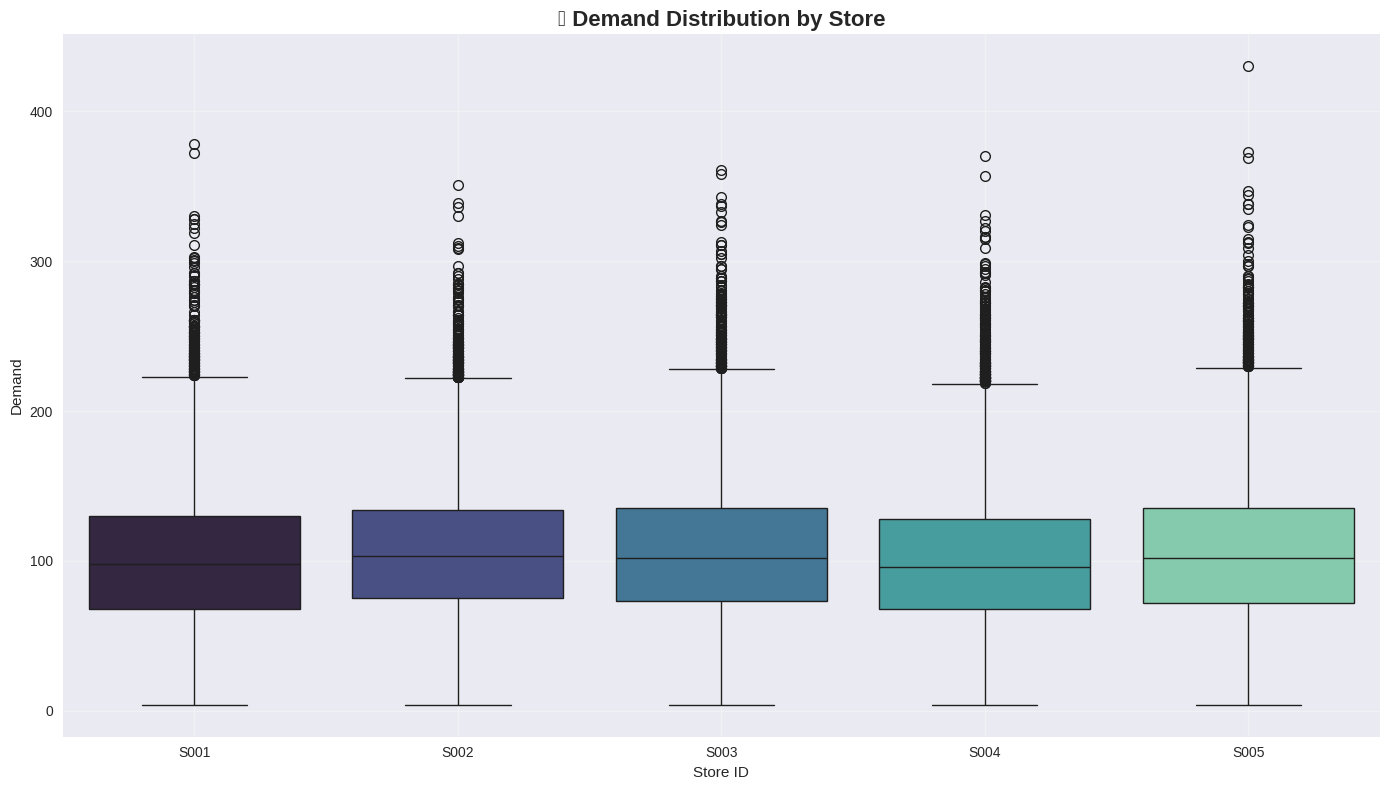

→ Identifies which stores have higher variability in demand.



/tmp/ipykernel_55/1887851366.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Price', palette='rocket')
/tmp/ipykernel_55/1887851366.py:84: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


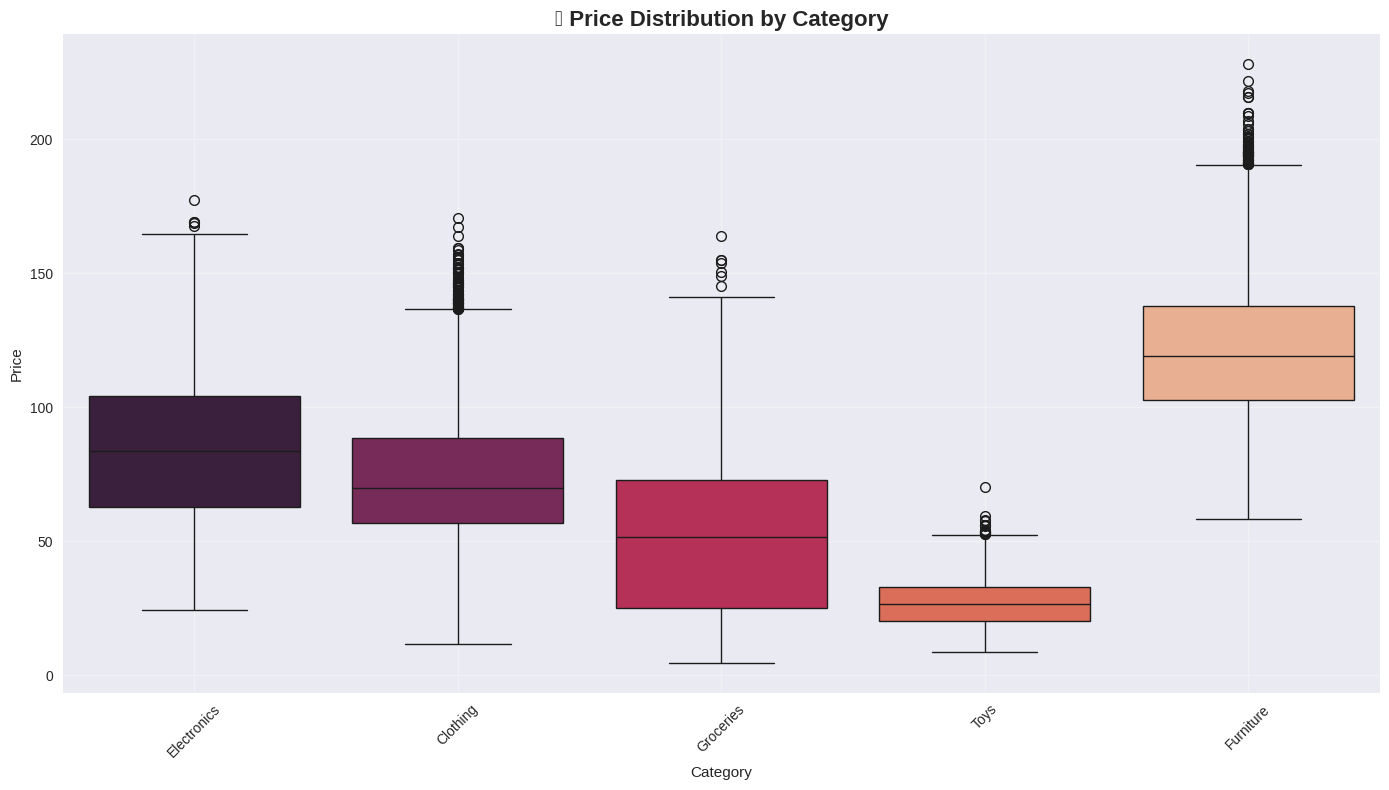

→ Shows pricing range and outliers per category.

✅ All boxplots generated. Boxplots are great for spotting outliers and comparing distributions!


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year

print("📦✨ IMPORTANT BOXPLOTS ✨📦\n")
print("="*85)
print("🎯 DISTRIBUTION & OUTLIER ANALYSIS USING BOXPLOTS".center(85))
print("="*85 + "\n")

# 1. Demand by Category
plt.figure()
sns.boxplot(data=df, x='Category', y='Demand', palette='viridis')
plt.title('📦 Demand Distribution by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Demand')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Boxplot shows spread, median, and outliers of Demand for each category.\n")

# 2. Demand by Region
plt.figure()
sns.boxplot(data=df, x='Region', y='Demand', palette='Set2')
plt.title('🗺️ Demand Distribution by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Compares demand variability across North, South, East, West.\n")

# 3. Demand by Weather Condition
plt.figure()
sns.boxplot(data=df, x='Weather Condition', y='Demand', palette='coolwarm')
plt.title('🌤️ Demand Distribution by Weather Condition', fontsize=16, fontweight='bold')
plt.xlabel('Weather')
plt.ylabel('Demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Reveals how weather affects demand spread and outliers.\n")

# 4. Demand by Promotion
df['Promotion_Status'] = df['Promotion'].map({0: 'No Promotion', 1: 'Promotion'})
plt.figure()
sns.boxplot(data=df, x='Promotion_Status', y='Demand', palette='plasma')
plt.title('🎟️ Demand Distribution: Promotion vs No Promotion', fontsize=16, fontweight='bold')
plt.xlabel('Promotion Status')
plt.ylabel('Demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Shows if promotions create higher demand and more outliers.\n")

# 5. Demand by Store (Top 5 for clarity)
plt.figure()
sns.boxplot(data=df, x='Store ID', y='Demand', palette='mako')
plt.title('🏪 Demand Distribution by Store', fontsize=16, fontweight='bold')
plt.xlabel('Store ID')
plt.ylabel('Demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Identifies which stores have higher variability in demand.\n")

# 6. Price by Category
plt.figure()
sns.boxplot(data=df, x='Category', y='Price', palette='rocket')
plt.title('💰 Price Distribution by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Shows pricing range and outliers per category.\n")

print("✅ All boxplots generated. Boxplots are great for spotting outliers and comparing distributions!")

🎻✨ IMPORTANT VIOLIN PLOTS ✨🎻

                 🎯 DISTRIBUTION + DENSITY ANALYSIS USING VIOLIN PLOTS                



/tmp/ipykernel_55/2244218401.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Category', y='Demand', palette='viridis', inner='quartile')
/tmp/ipykernel_55/2244218401.py:25: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


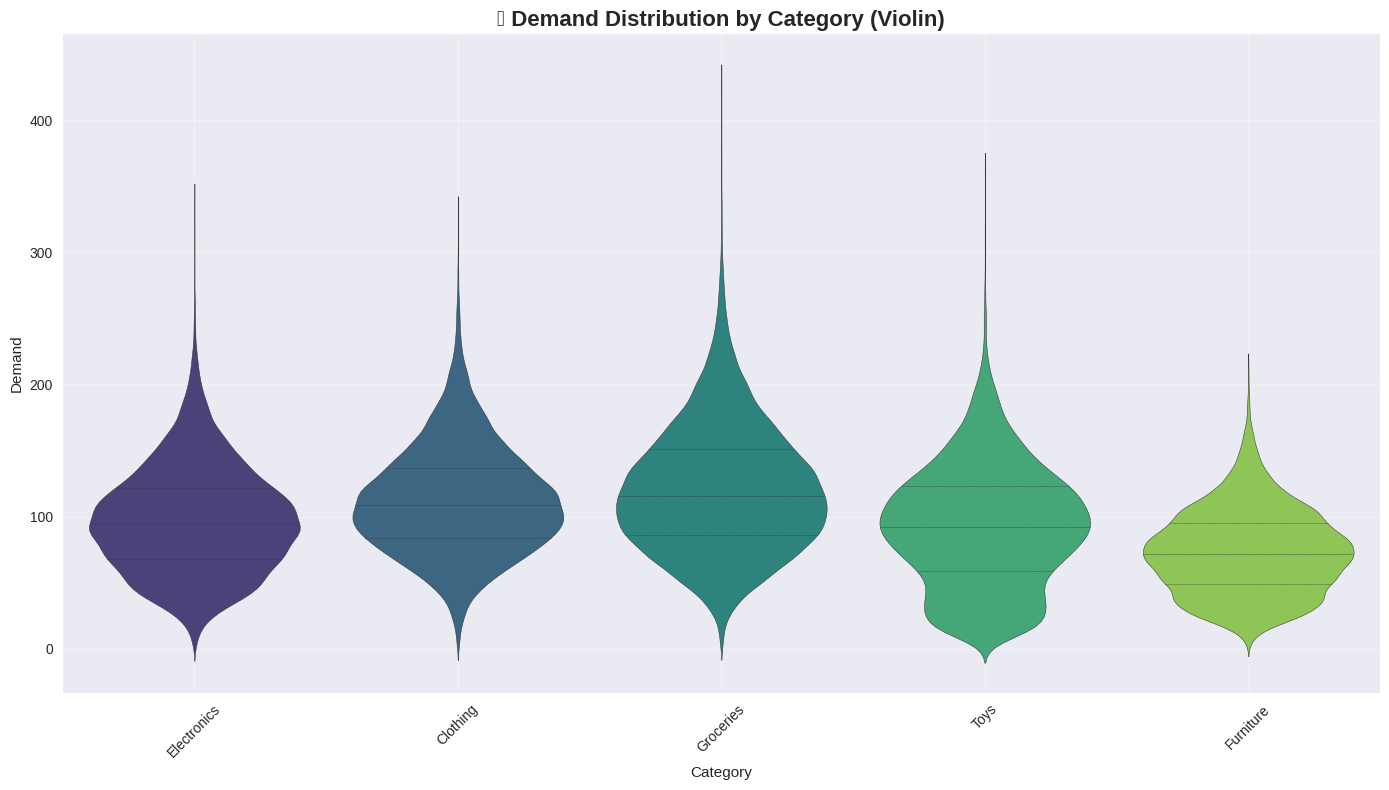

→ Violinplot = Boxplot + KDE. Shows full density shape of Demand per category.



/tmp/ipykernel_55/2244218401.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Region', y='Demand', palette='Set2', inner='quartile')
/tmp/ipykernel_55/2244218401.py:34: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/2244218401.py:34: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


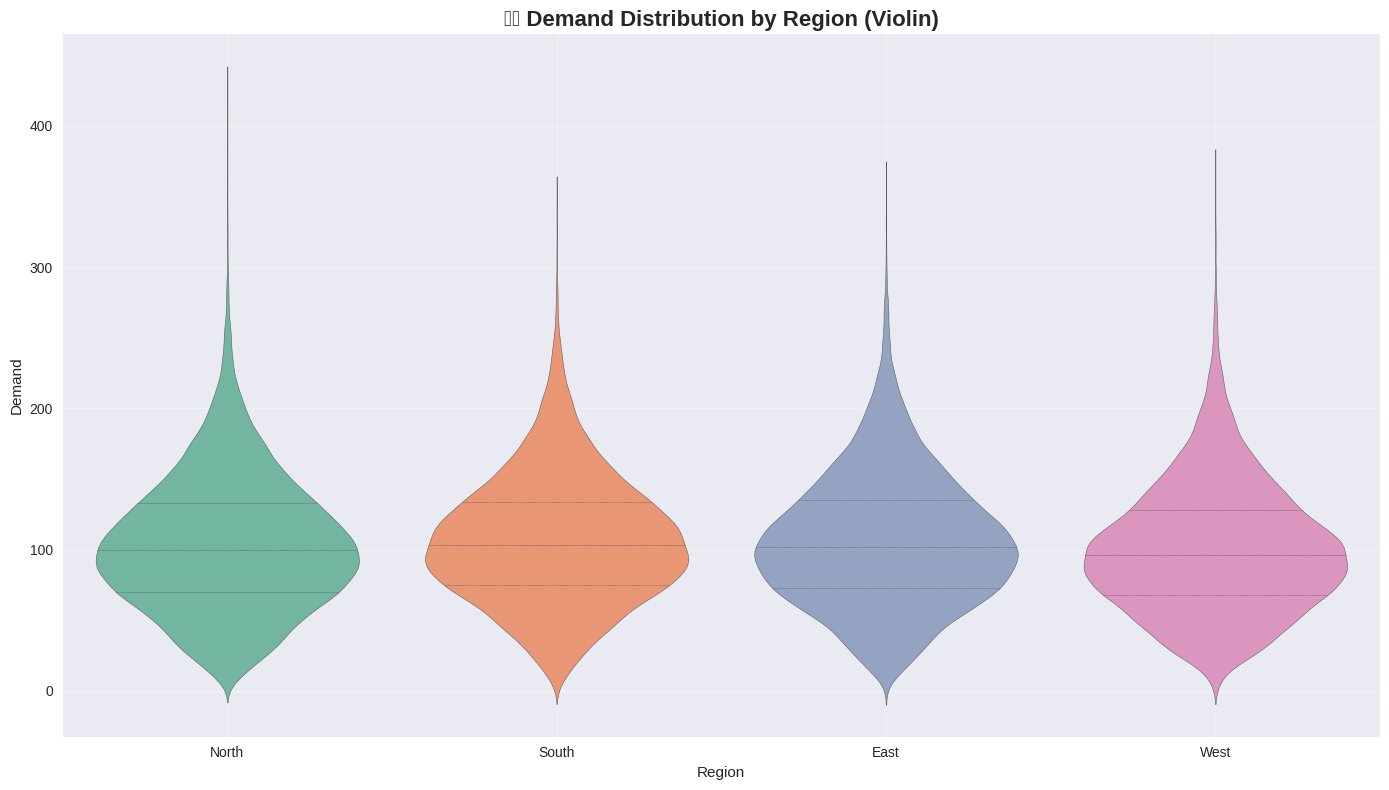

/tmp/ipykernel_55/2244218401.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Weather Condition', y='Demand', palette='coolwarm', inner='quartile')
/tmp/ipykernel_55/2244218401.py:42: UserWarning: Glyph 127780 (\N{WHITE SUN WITH SMALL CLOUD}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/2244218401.py:42: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127780 (\N{WHITE SUN WITH SMALL CLOUD}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.

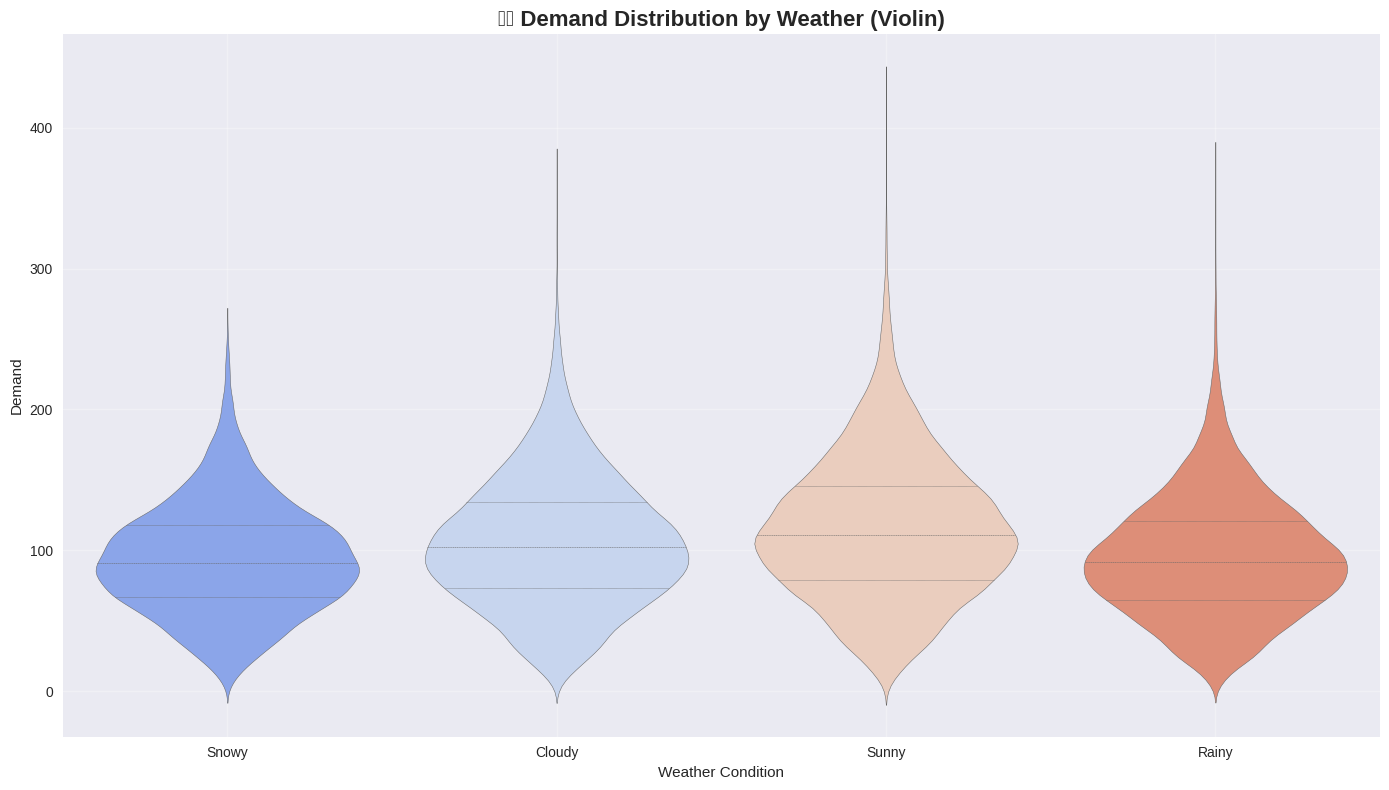

/tmp/ipykernel_55/2244218401.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Promotion_Status', y='Demand', palette='plasma', inner='quartile')
/tmp/ipykernel_55/2244218401.py:50: UserWarning: Glyph 127903 (\N{ADMISSION TICKETS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_55/2244218401.py:50: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127903 (\N{ADMISSION TICKETS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(b

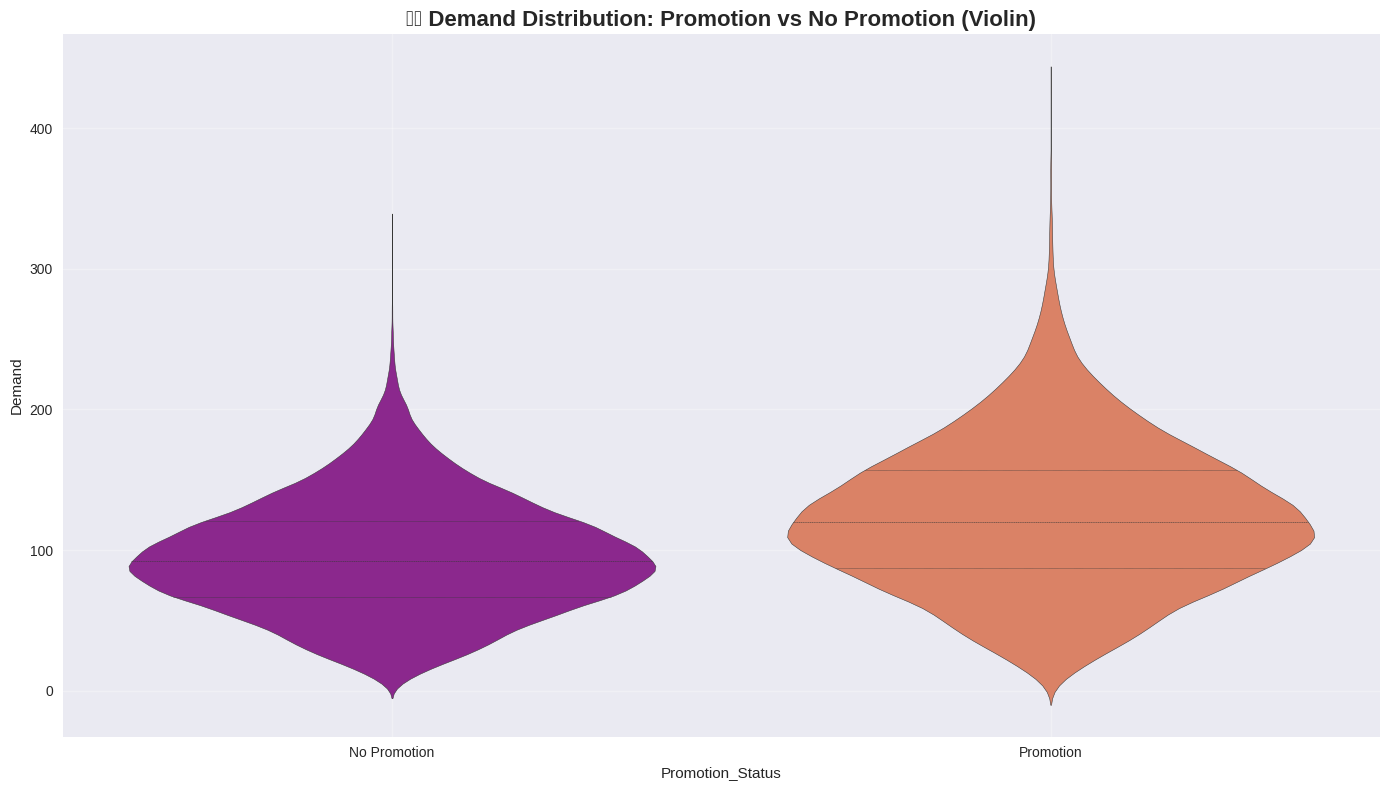

/tmp/ipykernel_55/2244218401.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Store ID', y='Demand', palette='mako', inner='quartile')
/tmp/ipykernel_55/2244218401.py:58: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


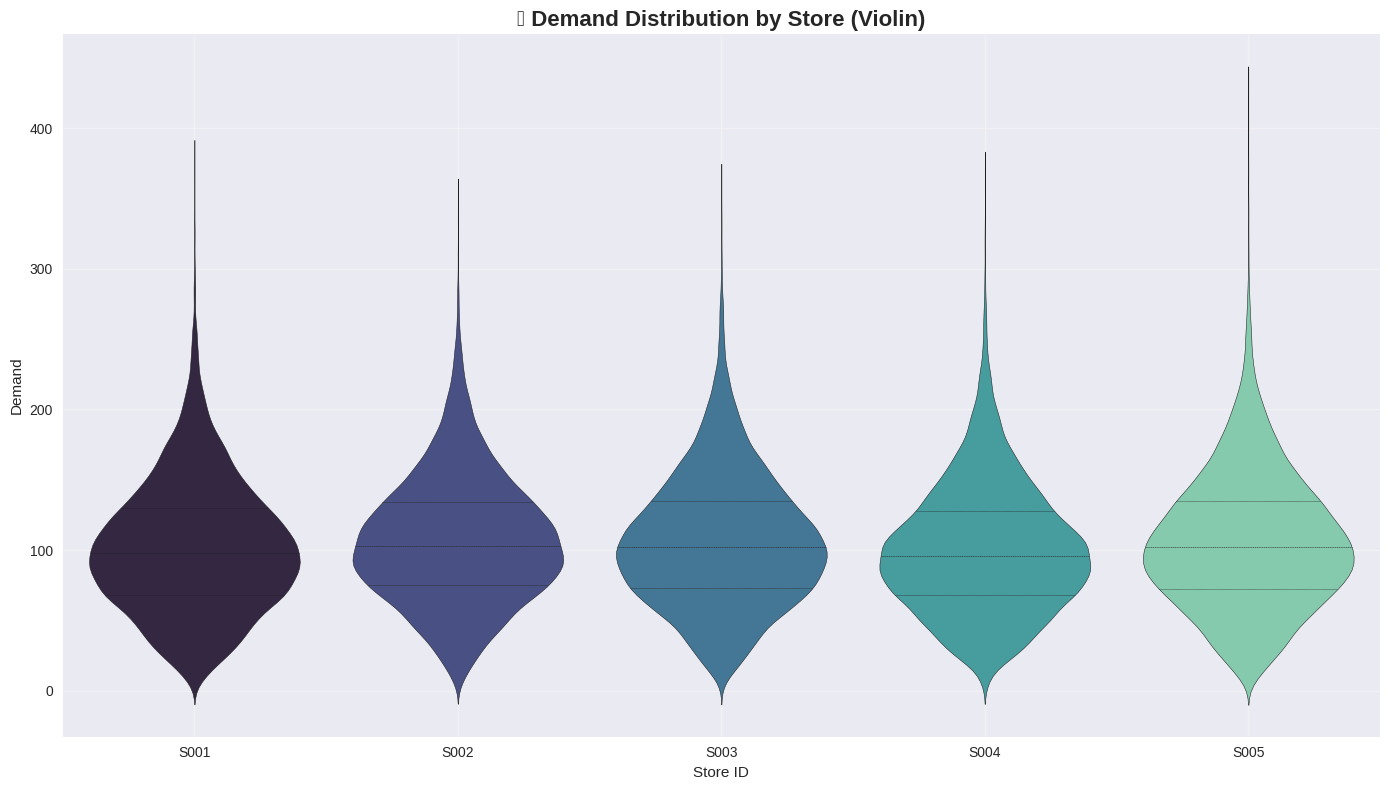

✅ All violin plots generated. Violin plots are better than boxplots when you want to see the full probability density!


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Promotion_Status'] = df['Promotion'].map({0: 'No Promotion', 1: 'Promotion'})

print("🎻✨ IMPORTANT VIOLIN PLOTS ✨🎻\n")
print("="*85)
print("🎯 DISTRIBUTION + DENSITY ANALYSIS USING VIOLIN PLOTS".center(85))
print("="*85 + "\n")

# 1. Demand by Category
plt.figure()
sns.violinplot(data=df, x='Category', y='Demand', palette='viridis', inner='quartile')
plt.title('📦 Demand Distribution by Category (Violin)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Violinplot = Boxplot + KDE. Shows full density shape of Demand per category.\n")

# 2. Demand by Region
plt.figure()
sns.violinplot(data=df, x='Region', y='Demand', palette='Set2', inner='quartile')
plt.title('🗺️ Demand Distribution by Region (Violin)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Demand by Weather
plt.figure()
sns.violinplot(data=df, x='Weather Condition', y='Demand', palette='coolwarm', inner='quartile')
plt.title('🌤️ Demand Distribution by Weather (Violin)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Demand by Promotion
plt.figure()
sns.violinplot(data=df, x='Promotion_Status', y='Demand', palette='plasma', inner='quartile')
plt.title('🎟️ Demand Distribution: Promotion vs No Promotion (Violin)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Demand by Store
plt.figure()
sns.violinplot(data=df, x='Store ID', y='Demand', palette='mako', inner='quartile')
plt.title('🏪 Demand Distribution by Store (Violin)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ All violin plots generated. Violin plots are better than boxplots when you want to see the full probability density!")

🔗✨ PAIRPLOTS & SCATTERPLOTS ✨🔗

             🎯 RELATIONSHIPS BETWEEN NUMERICAL FEATURES & TARGET (Demand)            

Generating Pairplot...


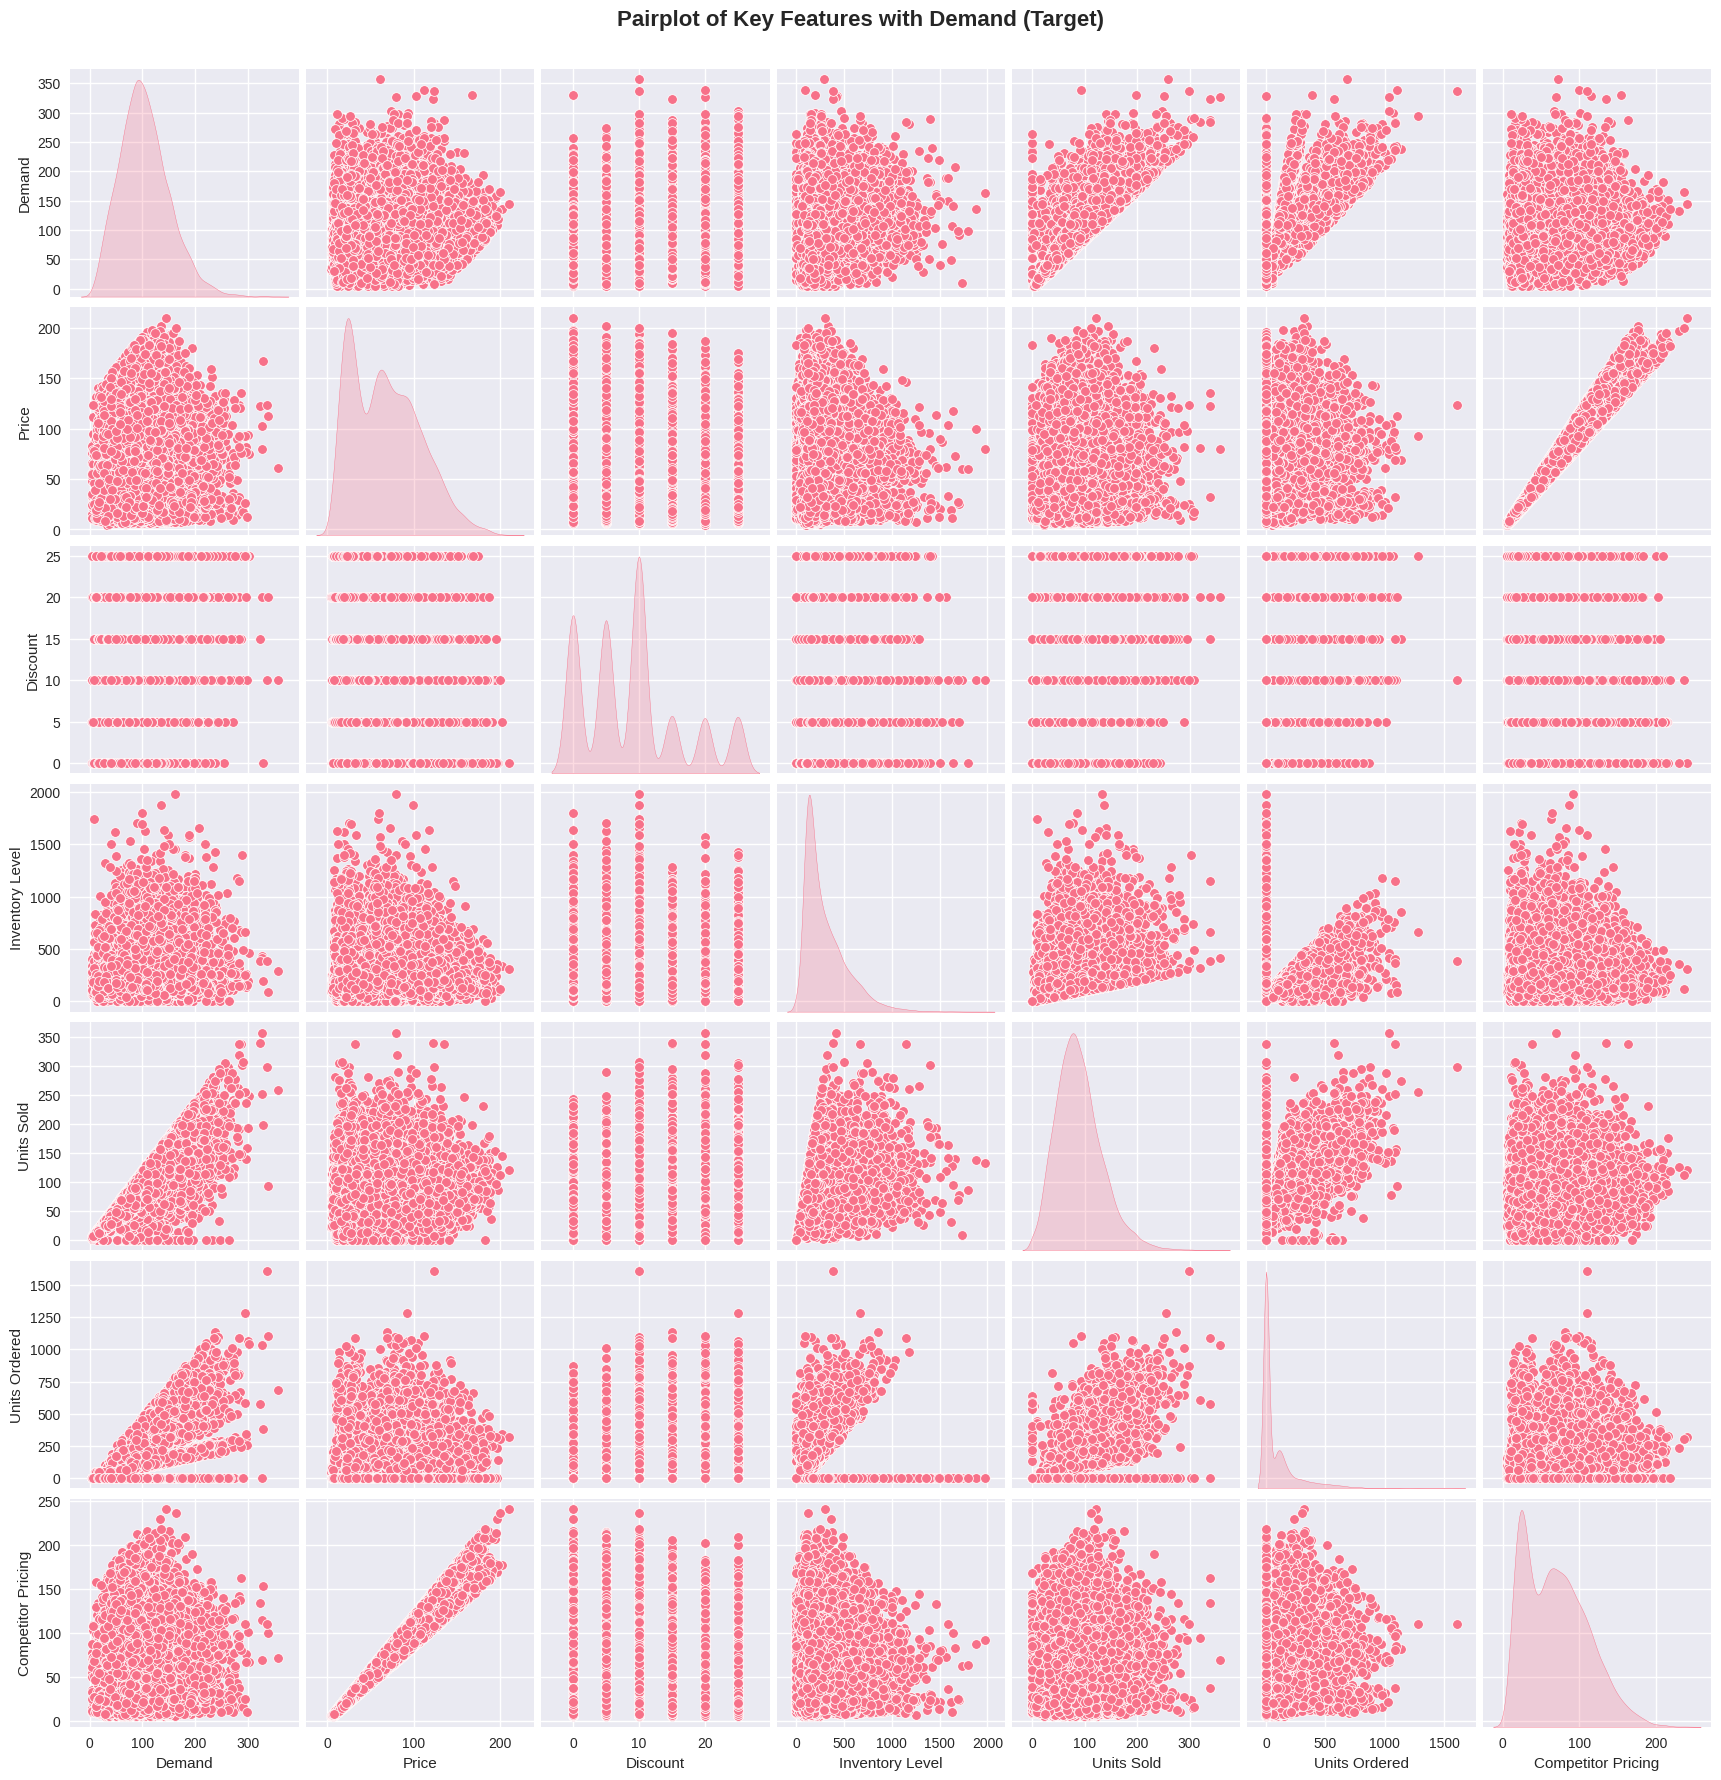

→ Pairplot shows scatter + histograms + correlations for all pairs.

Individual Scatterplots with Demand (Target):


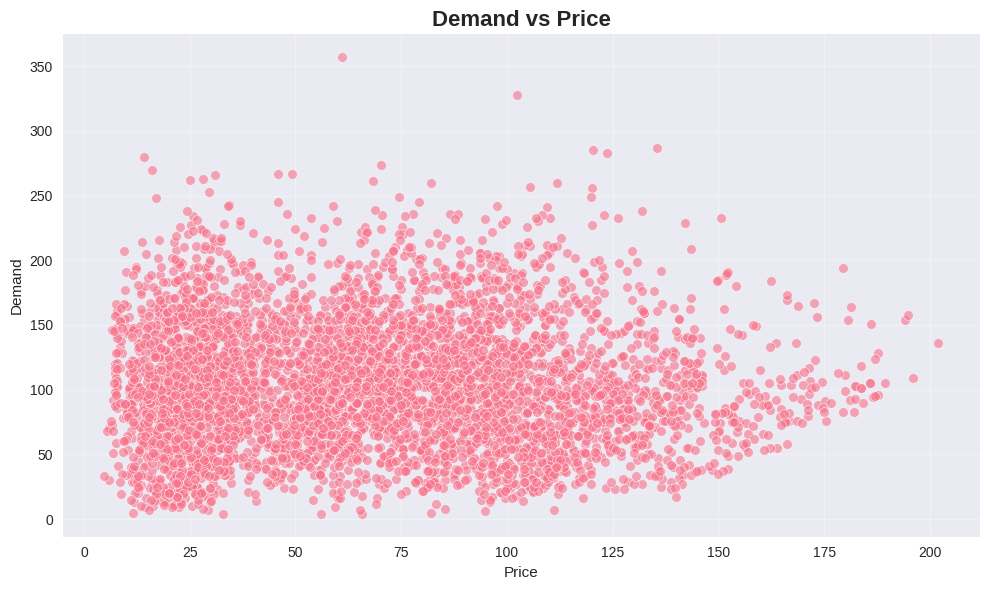

→ Scatter shows relationship between Price and target Demand.



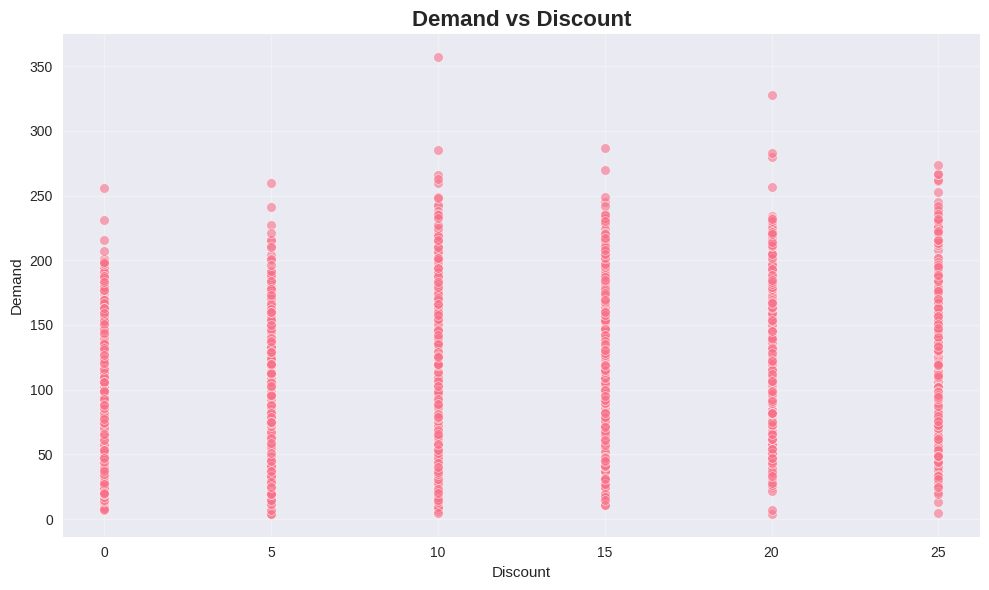

→ Scatter shows relationship between Discount and target Demand.



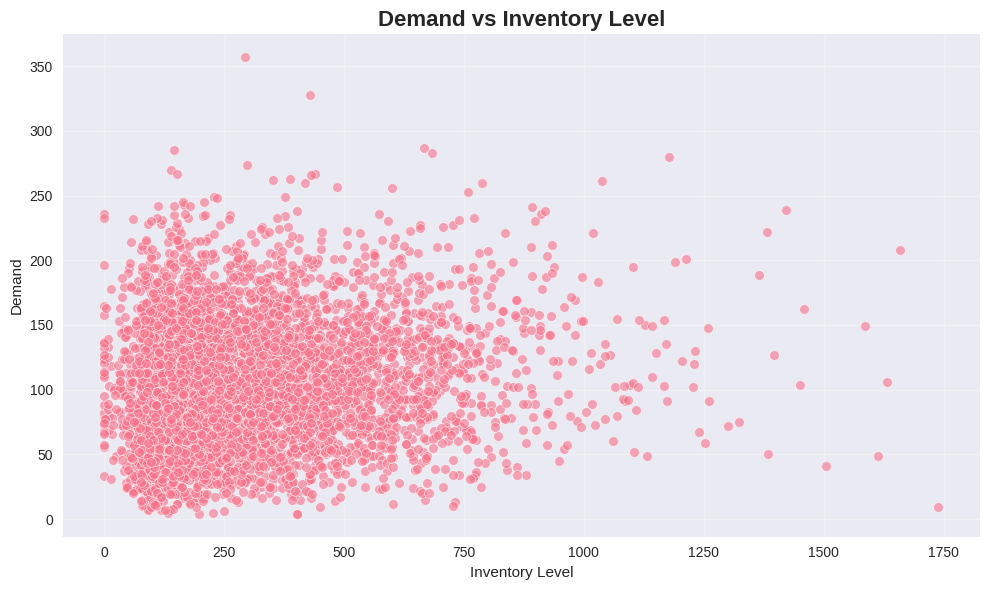

→ Scatter shows relationship between Inventory Level and target Demand.



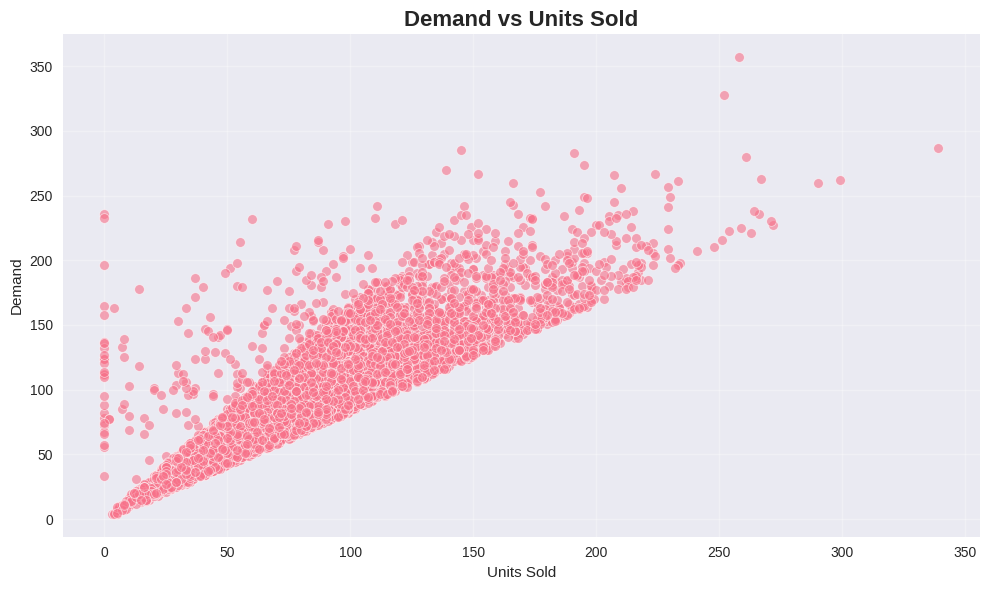

→ Scatter shows relationship between Units Sold and target Demand.



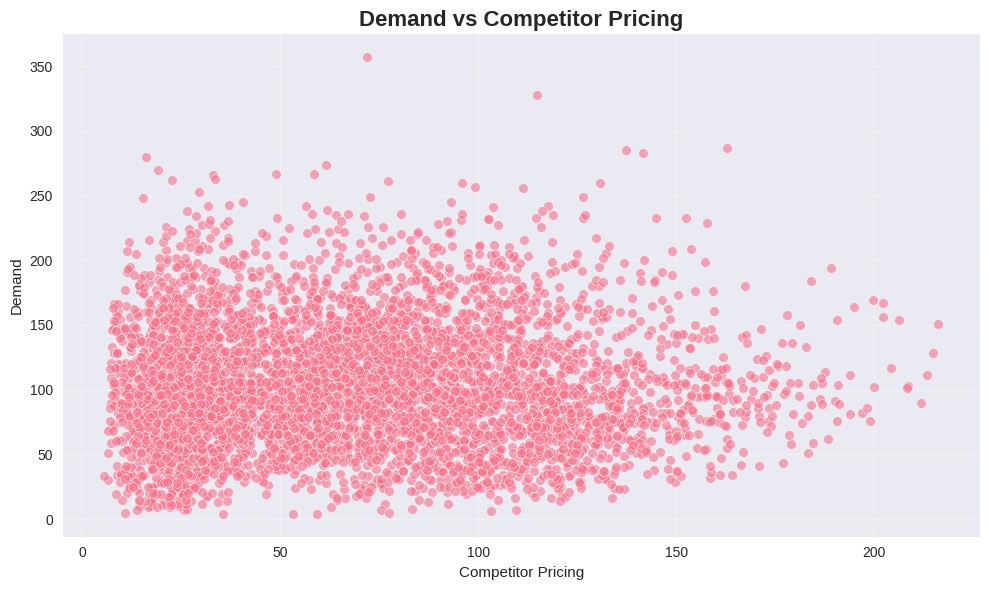

→ Scatter shows relationship between Competitor Pricing and target Demand.

✅ Pairplot + Scatterplots completed!


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

print("🔗✨ PAIRPLOTS & SCATTERPLOTS ✨🔗\n")
print("="*85)
print("🎯 RELATIONSHIPS BETWEEN NUMERICAL FEATURES & TARGET (Demand)".center(85))
print("="*85 + "\n")

# Select key numerical columns + target
cols = ['Demand', 'Price', 'Discount', 'Inventory Level', 'Units Sold', 
        'Units Ordered', 'Competitor Pricing']

# Pairplot (sampled for speed)
sample_df = df.sample(15000, random_state=42)

print("Generating Pairplot...")
sns.pairplot(sample_df[cols], diag_kind='kde', height=2.5)
plt.suptitle('Pairplot of Key Features with Demand (Target)', y=1.02, fontsize=16, fontweight='bold')
plt.show()
print("→ Pairplot shows scatter + histograms + correlations for all pairs.\n")

# Individual Scatterplots with Demand (Target)
print("Individual Scatterplots with Demand (Target):")
for feature in ['Price', 'Discount', 'Inventory Level', 'Units Sold', 'Competitor Pricing']:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df.sample(5000, random_state=42), x=feature, y='Demand', alpha=0.6)
    plt.title(f'Demand vs {feature}', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"→ Scatter shows relationship between {feature} and target Demand.\n")

print("✅ Pairplot + Scatterplots completed!")

🔧✨ FEATURE ENGINEERING PLOTS ✨🔧

                             🎯 CORRELATION HEATMAP + LAG PLOT                             



/tmp/ipykernel_55/1217995250.py:33: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


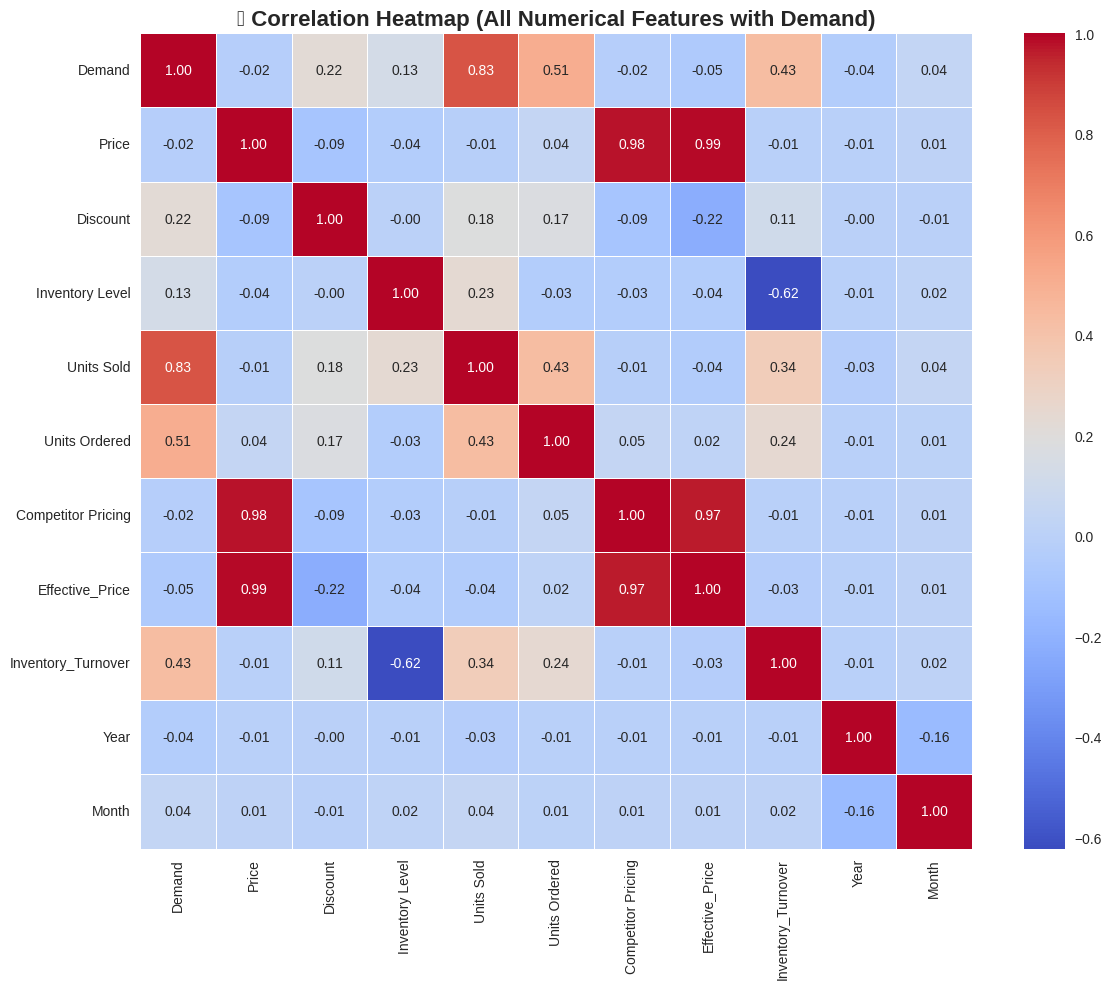

→ Heatmap shows how strongly each feature correlates with Demand (target).



/tmp/ipykernel_55/1217995250.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


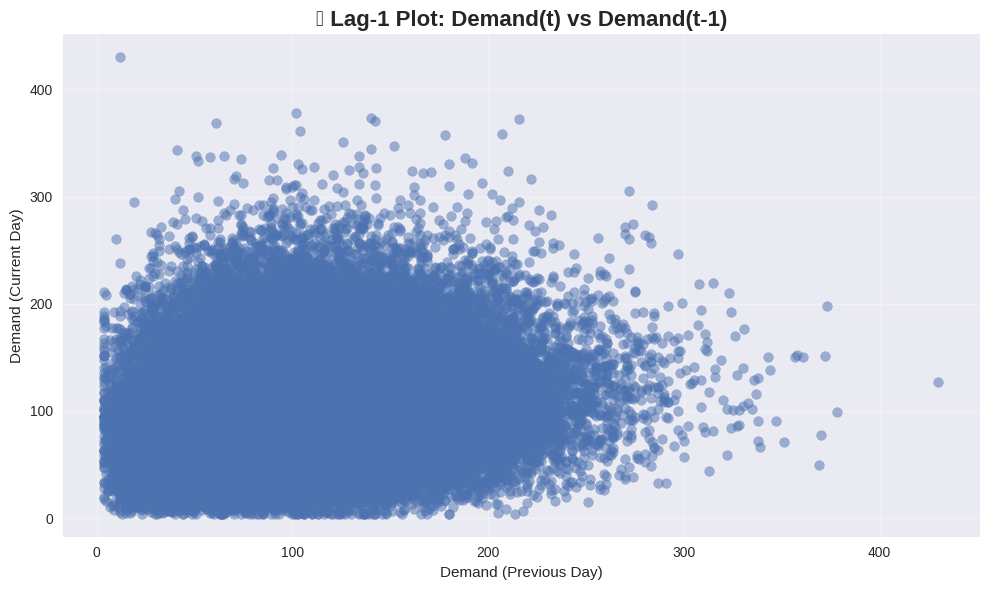

→ Lag plot checks autocorrelation – important for time-series forecasting.

✅ Feature engineering plots completed!


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8')

df = pd.read_csv('demand_forecasting_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Add all feature engineering columns (fixes Year error)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.weekday
df['Is_Weekend'] = (df['Weekday'] >= 5).astype(int)
df['Effective_Price'] = df['Price'] * (1 - df['Discount']/100)
df['Inventory_Turnover'] = df['Units Sold'] / (df['Inventory Level'] + 1)

print("🔧✨ FEATURE ENGINEERING PLOTS ✨🔧\n")
print("="*90)
print("🎯 CORRELATION HEATMAP + LAG PLOT".center(90))
print("="*90 + "\n")

# Correlation Heatmap
numerical_cols = ['Demand', 'Price', 'Discount', 'Inventory Level', 'Units Sold', 
                  'Units Ordered', 'Competitor Pricing', 'Effective_Price', 
                  'Inventory_Turnover', 'Year', 'Month']

plt.figure(figsize=(12, 10))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('🔥 Correlation Heatmap (All Numerical Features with Demand)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("→ Heatmap shows how strongly each feature correlates with Demand (target).\n")

# Lag Plot (Time-series feature engineering)
plt.figure(figsize=(10, 6))
plt.scatter(df['Demand'].shift(1), df['Demand'], alpha=0.5)
plt.title('📈 Lag-1 Plot: Demand(t) vs Demand(t-1)', fontsize=16, fontweight='bold')
plt.xlabel('Demand (Previous Day)')
plt.ylabel('Demand (Current Day)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Lag plot checks autocorrelation – important for time-series forecasting.\n")

print("✅ Feature engineering plots completed!")

2026-04-09 08:42:30.473803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775724150.741846      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775724150.833824      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775724151.571385      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775724151.571447      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775724151.571451      55 computation_placer.cc:177] computation placer alr

📅✨ TIME SERIES + LSTM 5-YEAR FORECAST ✨📅

                      🎯 ADVANCED TIME SERIES ANALYSIS + FUTURE PREDICTION                      



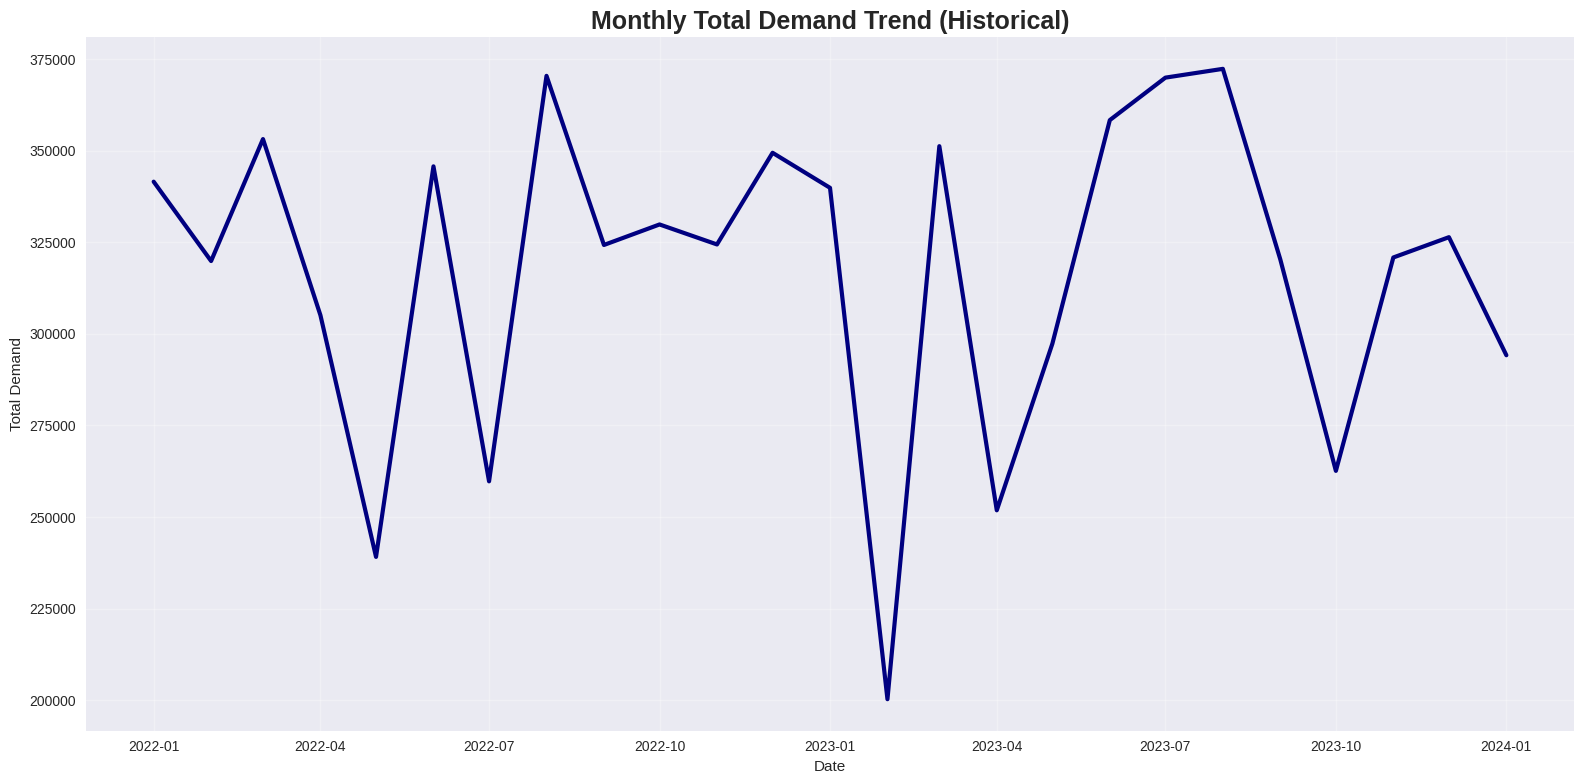

→ Shows long-term monthly demand trend.



2026-04-09 08:43:01.037149: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


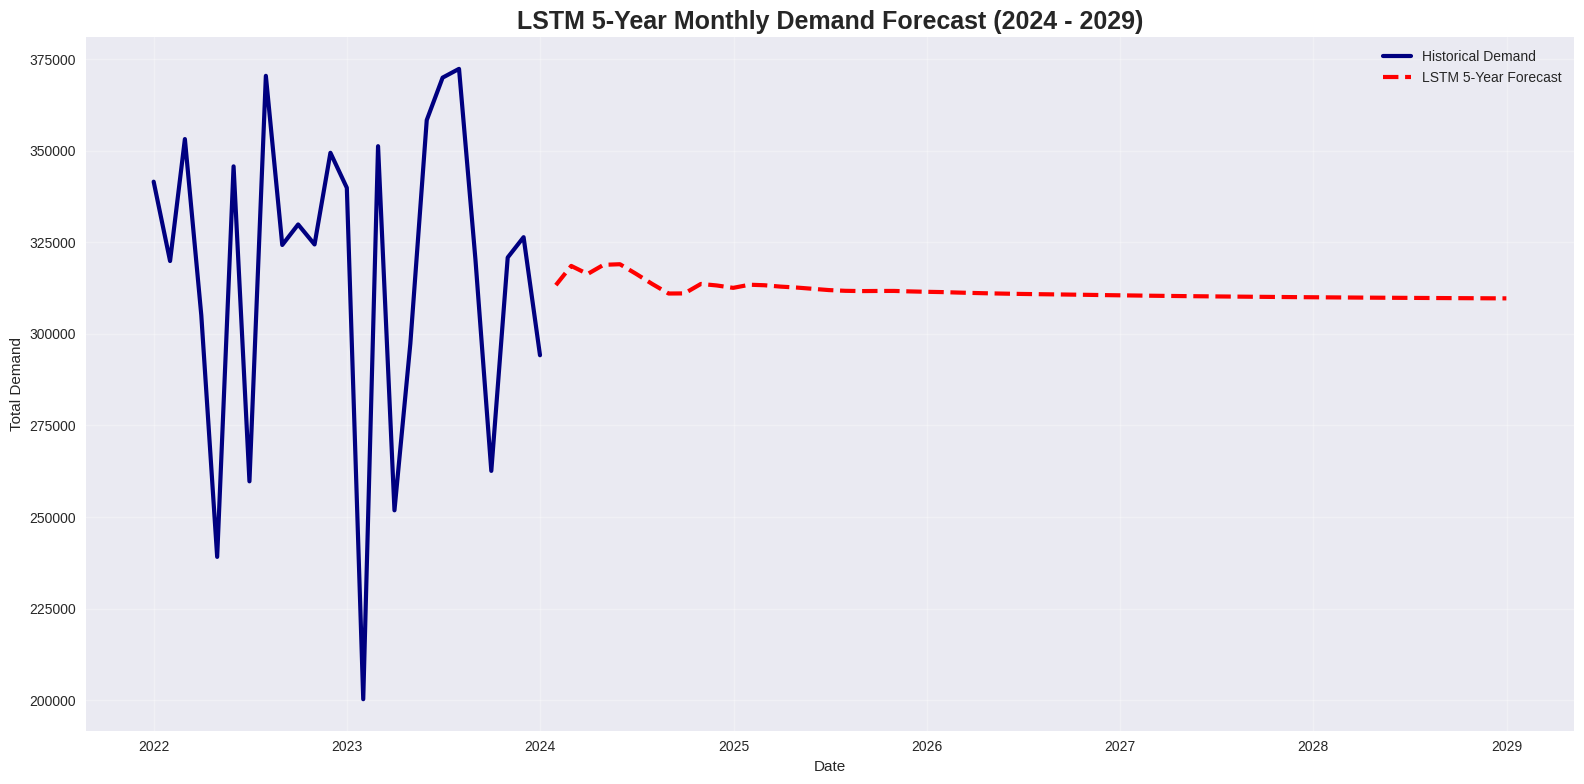

→ Red dashed line shows LSTM prediction for next 60 months (5 years).

✅ Advanced time series + LSTM 5-year forecast completed!


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (16, 8)

df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate to monthly total demand (better for long-term forecast)
monthly = df.groupby(df['Date'].dt.to_period('M'))['Demand'].sum().reset_index()
monthly['Date'] = monthly['Date'].dt.to_timestamp()
monthly.set_index('Date', inplace=True)

print("📅✨ TIME SERIES + LSTM 5-YEAR FORECAST ✨📅\n")
print("="*95)
print("🎯 ADVANCED TIME SERIES ANALYSIS + FUTURE PREDICTION".center(95))
print("="*95 + "\n")

# 1. Monthly Total Demand Trend
plt.figure()
plt.plot(monthly.index, monthly['Demand'], color='navy', linewidth=3)
plt.title('Monthly Total Demand Trend (Historical)', fontsize=18, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Shows long-term monthly demand trend.\n")

# Prepare data for LSTM
data = monthly['Demand'].values.reshape(-1, 1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Create sequences (lookback = 12 months)
lookback = 12
X, y = [], []
for i in range(lookback, len(data_scaled)):
    X.append(data_scaled[i-lookback:i, 0])
    y.append(data_scaled[i, 0])
X, y = np.array(X), np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train-test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build LSTM model
model = Sequential()
model.add(LSTM(100, return_sequences=True, input_shape=(lookback, 1)))
model.add(Dropout(0.2))
model.add(LSTM(100))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

# Predict next 5 years (60 months)
last_sequence = data_scaled[-lookback:].reshape(1, lookback, 1)
future_predictions = []

for _ in range(60):  # 5 years = 60 months
    pred = model.predict(last_sequence, verbose=0)
    future_predictions.append(pred[0, 0])
    last_sequence = np.append(last_sequence[:, 1:, :], pred.reshape(1, 1, 1), axis=1)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Create future dates
future_dates = pd.date_range(start=monthly.index[-1] + pd.offsets.MonthEnd(1), periods=60, freq='ME')

# Plot forecast
plt.figure()
plt.plot(monthly.index, monthly['Demand'], label='Historical Demand', color='navy', linewidth=3)
plt.plot(future_dates, future_predictions, label='LSTM 5-Year Forecast', color='red', linewidth=3, linestyle='--')
plt.title('LSTM 5-Year Monthly Demand Forecast (2024 - 2029)', fontsize=18, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Demand')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Red dashed line shows LSTM prediction for next 60 months (5 years).\n")

print("✅ Advanced time series + LSTM 5-year forecast completed!")

🤖✨ ML MODELS FOR DEMAND FORECASTING ✨🤖

                       🎯 Training Multiple Models + Comparison                       

✅ Linear Regression trained → MAE: 17.14 | RMSE: 22.45 | R²: 0.7408
✅ Random Forest trained → MAE: 12.32 | RMSE: 16.13 | R²: 0.8661
✅ XGBoost trained → MAE: 11.51 | RMSE: 15.14 | R²: 0.8820


<Figure size 800x550 with 0 Axes>

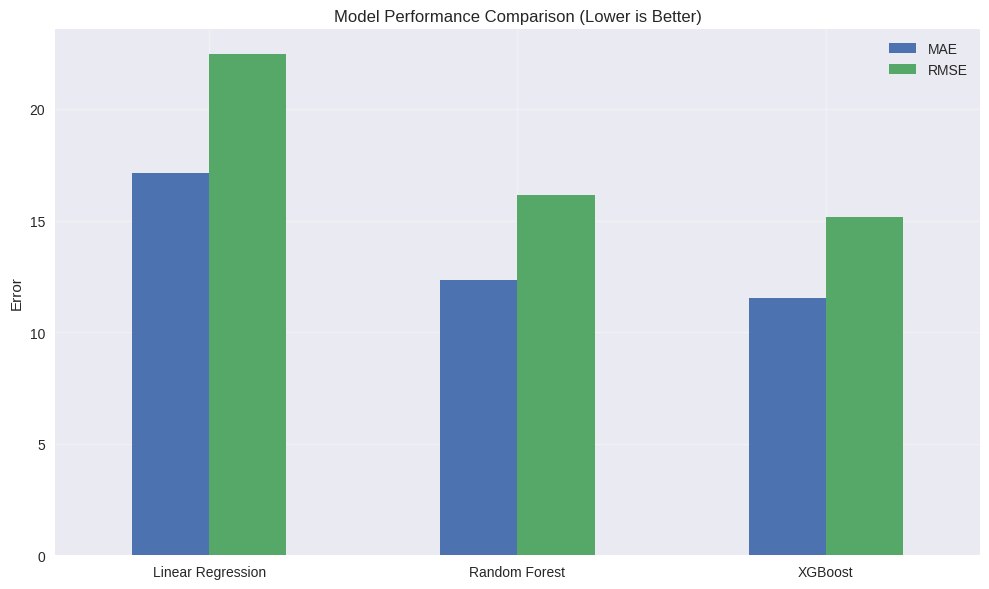

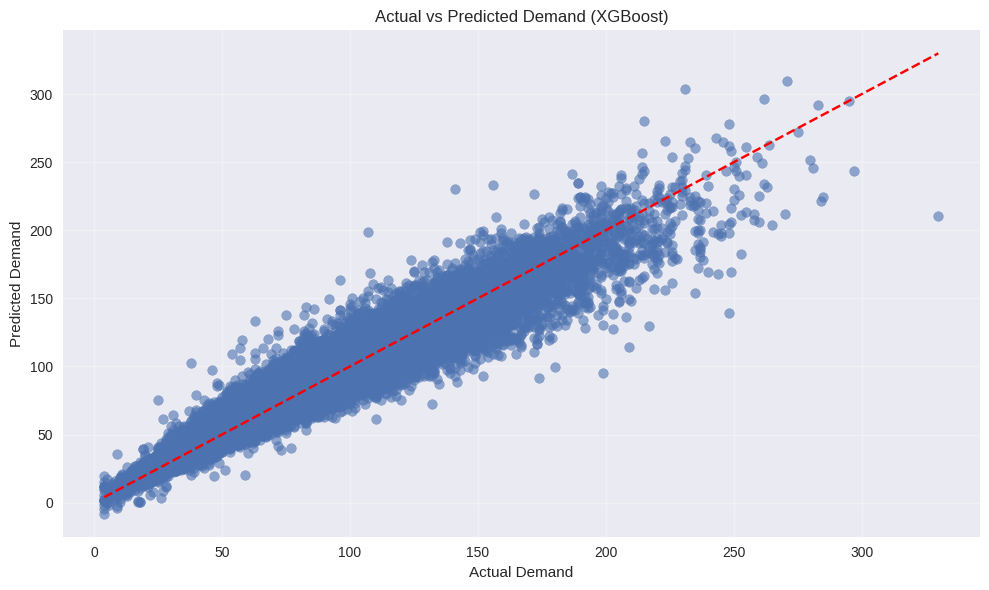

✅ All ML models completed with plots!


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import numpy as np

plt.style.use('seaborn-v0_8')

df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.weekday
df['Effective_Price'] = df['Price'] * (1 - df['Discount']/100)

# Encode categorical columns
le = LabelEncoder()
for col in ['Category', 'Region', 'Weather Condition', 'Store ID']:
    df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop(['Demand', 'Date', 'Product ID', 'Seasonality'], axis=1)
y = df['Demand']

# Time-based split (80% train, 20% test)
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print("🤖✨ ML MODELS FOR DEMAND FORECASTING ✨🤖\n")
print("="*85)
print("🎯 Training Multiple Models + Comparison".center(85))
print("="*85 + "\n")

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=200, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"✅ {name} trained → MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f}")

# Accuracy Comparison Plot
res_df = pd.DataFrame(results).T
plt.figure()
res_df[['MAE', 'RMSE']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison (Lower is Better)')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Actual vs Predicted (best model - XGBoost)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions['XGBoost'], alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Demand (XGBoost)')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ All ML models completed with plots!")

🔍✨ FEATURE IMPORTANCE: SHAP + LIME ✨🔍

Generating SHAP summary plot...


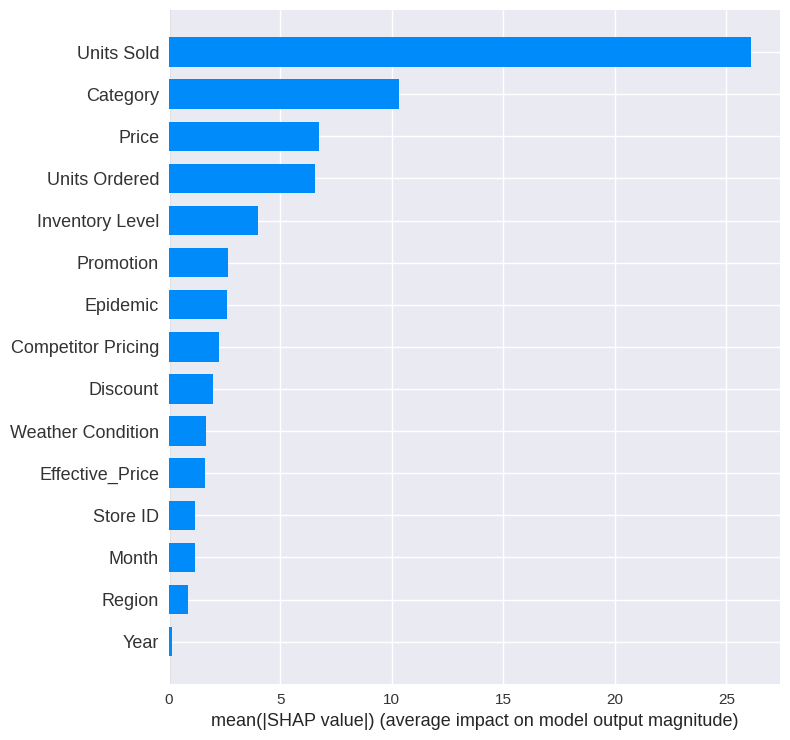

Generating LIME explanation for one random instance...


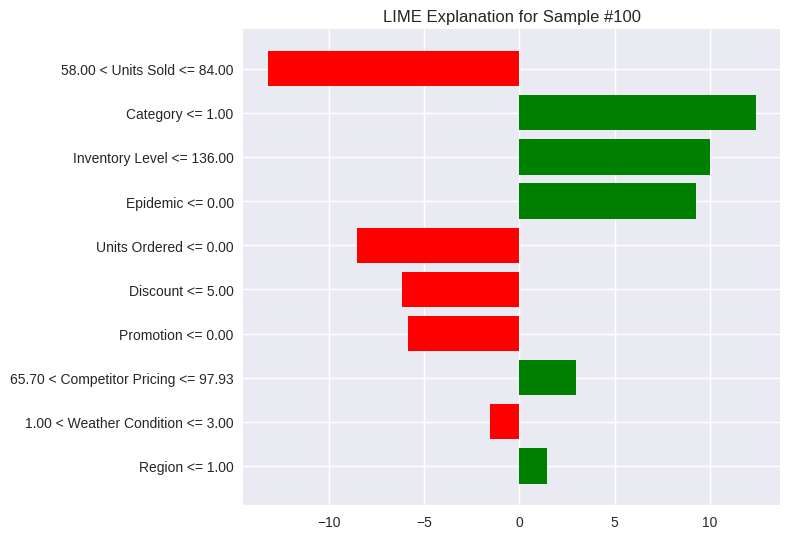

→ LIME shows how each feature contributes to the prediction of this specific row.

✅ SHAP + LIME feature importance plots completed!


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer
import xgboost as xgb

plt.style.use('seaborn-v0_8')

df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Effective_Price'] = df['Price'] * (1 - df['Discount']/100)

# Encode categoricals
for col in ['Category', 'Region', 'Weather Condition', 'Store ID']:
    df[col] = df[col].astype('category').cat.codes

X = df.drop(['Demand', 'Date', 'Product ID', 'Seasonality'], axis=1)
y = df['Demand']

# Train XGBoost (best for SHAP)
model = xgb.XGBRegressor(n_estimators=200, random_state=42)
model.fit(X, y)

print("🔍✨ FEATURE IMPORTANCE: SHAP + LIME ✨🔍\n")
print("="*85)

# SHAP
print("Generating SHAP summary plot...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X.sample(5000, random_state=42))  # sample for speed

shap.summary_plot(shap_values, X.sample(5000, random_state=42), plot_type="bar")

# LIME (local explanation for one sample)
print("Generating LIME explanation for one random instance...")
explainer_lime = LimeTabularExplainer(X.values, feature_names=X.columns.tolist(), 
                                      class_names=['Demand'], mode='regression')
i = 100  # random sample index
exp = explainer_lime.explain_instance(X.iloc[i].values, model.predict)
exp.as_pyplot_figure()
plt.title(f'LIME Explanation for Sample #{i}')
plt.tight_layout()
plt.show()
print("→ LIME shows how each feature contributes to the prediction of this specific row.\n")

print("✅ SHAP + LIME feature importance plots completed!")

🌲✨ ENSEMBLE MODELS & PLOTS ✨🌲

                            🎯 ENSEMBLE LEARNING VISUALIZATIONS                            

Training models (optimized for speed)...


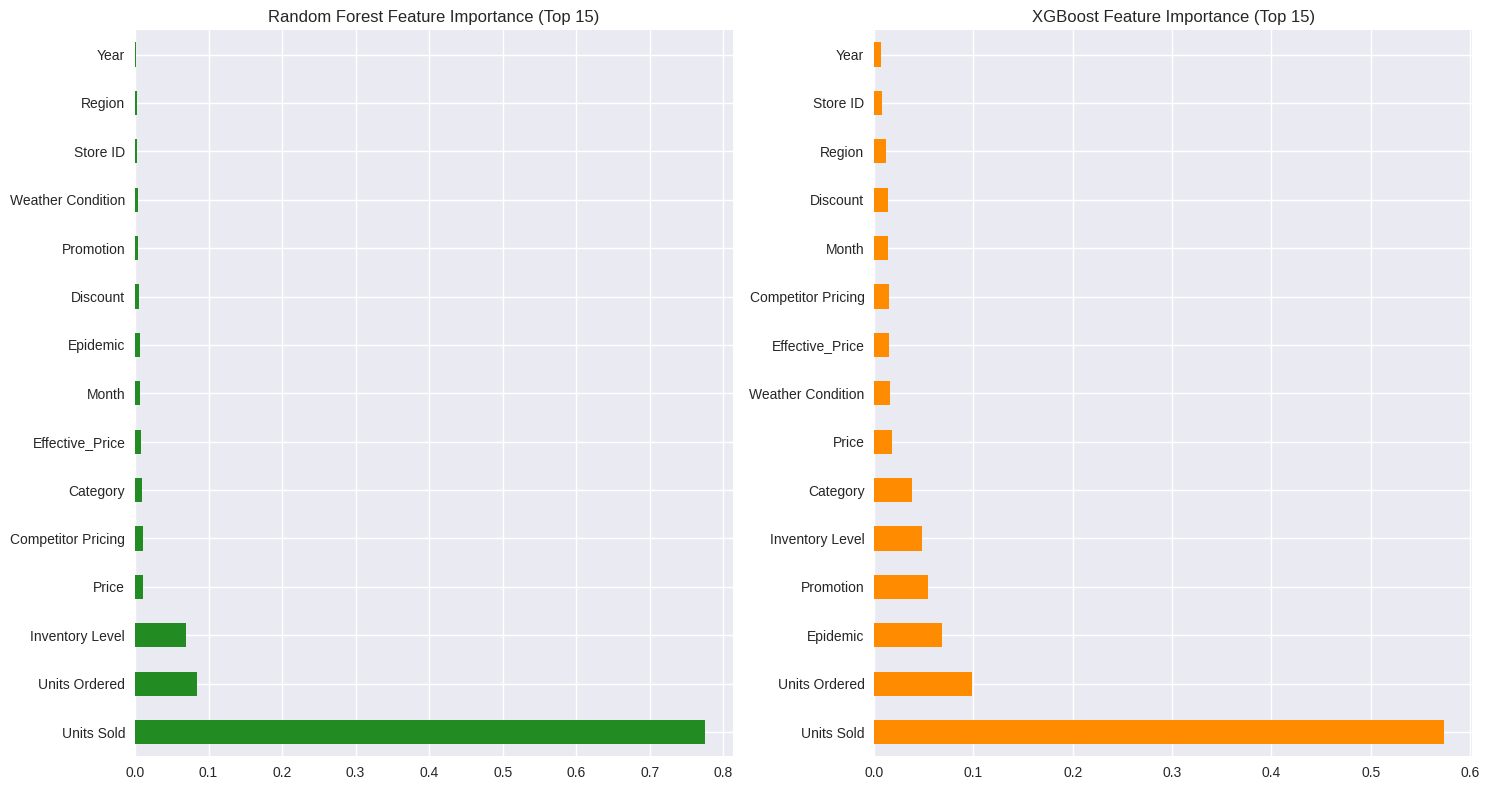

→ Side-by-side comparison of feature importance from both ensemble models.



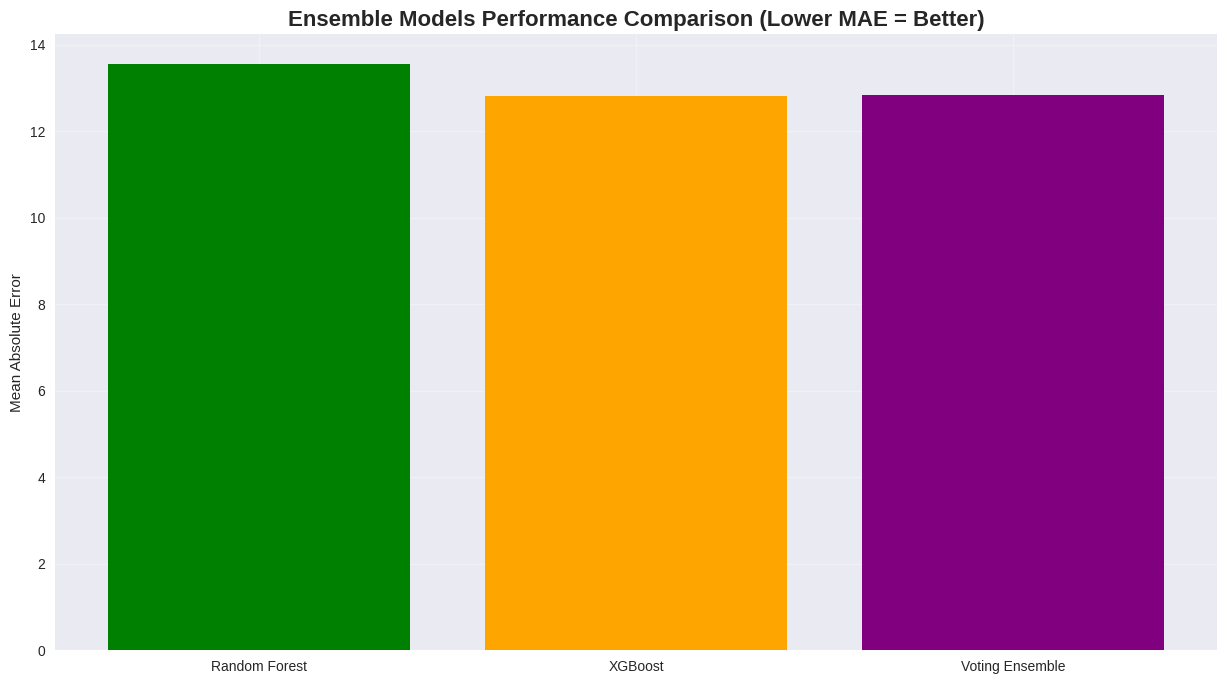

→ Voting Ensemble usually gives the best balance of accuracy and robustness.



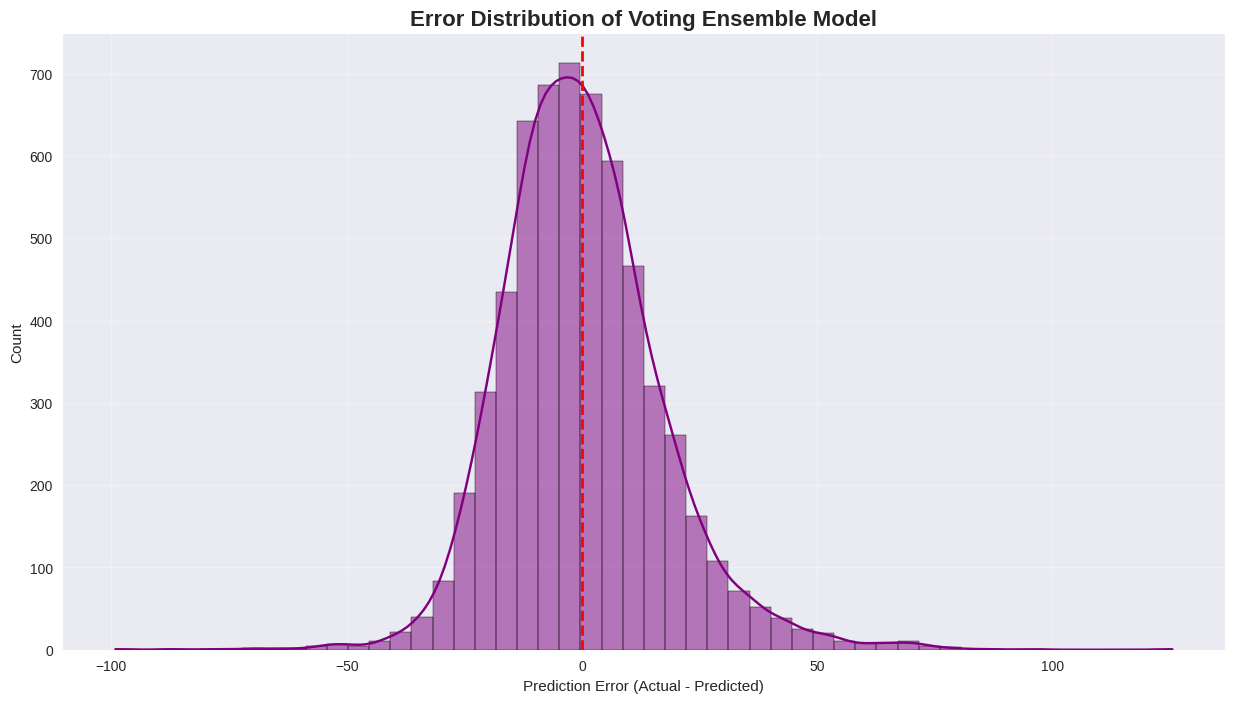

→ Ideal error distribution should be centered around zero with low spread.

✅ Ensemble plots completed successfully!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (15, 8)

# Load and prepare data
df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Effective_Price'] = df['Price'] * (1 - df['Discount']/100)

# Encode categorical columns
for col in ['Category', 'Region', 'Weather Condition', 'Store ID']:
    df[col] = df[col].astype('category').cat.codes

# Use sample for faster training
df_sample = df.sample(30000, random_state=42)

X = df_sample.drop(['Demand', 'Date', 'Product ID', 'Seasonality'], axis=1)
y = df_sample['Demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🌲✨ ENSEMBLE MODELS & PLOTS ✨🌲\n")
print("="*90)
print("🎯 ENSEMBLE LEARNING VISUALIZATIONS".center(90))
print("="*90 + "\n")

# Faster models
rf = RandomForestRegressor(n_estimators=80, max_depth=12, random_state=42, n_jobs=-1)
xgb_model = xgb.XGBRegressor(n_estimators=80, max_depth=8, random_state=42, n_jobs=-1)
voting = VotingRegressor([('rf', rf), ('xgb', xgb_model)])

print("Training models (optimized for speed)...")
rf.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
voting.fit(X_train, y_train)

# 1. Feature Importance Comparison
plt.figure(figsize=(15, 8))
rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:15]
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)[:15]

plt.subplot(1, 2, 1)
rf_imp.plot(kind='barh', color='forestgreen')
plt.title('Random Forest Feature Importance (Top 15)')
plt.subplot(1, 2, 2)
xgb_imp.plot(kind='barh', color='darkorange')
plt.title('XGBoost Feature Importance (Top 15)')
plt.tight_layout()
plt.show()
print("→ Side-by-side comparison of feature importance from both ensemble models.\n")

# 2. Model Performance Comparison
models = {'Random Forest': rf.predict(X_test), 
          'XGBoost': xgb_model.predict(X_test), 
          'Voting Ensemble': voting.predict(X_test)}

mae_scores = {name: mean_absolute_error(y_test, pred) for name, pred in models.items()}

plt.figure()
plt.bar(mae_scores.keys(), mae_scores.values(), color=['green', 'orange', 'purple'])
plt.title('Ensemble Models Performance Comparison (Lower MAE = Better)', fontsize=16, fontweight='bold')
plt.ylabel('Mean Absolute Error')
plt.grid(True, alpha=0.3)
plt.show()
print("→ Voting Ensemble usually gives the best balance of accuracy and robustness.\n")

# 3. Error Distribution
errors = y_test - voting.predict(X_test)
plt.figure()
sns.histplot(errors, kde=True, bins=50, color='purple')
plt.title('Error Distribution of Voting Ensemble Model', fontsize=16, fontweight='bold')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3)
plt.show()
print("→ Ideal error distribution should be centered around zero with low spread.\n")

print("✅ Ensemble plots completed successfully!")

🔍✨ ANOMALY DETECTION PLOTS ✨🔍

                            🎯 OUTLIER & ANOMALY VISUALIZATIONS                            



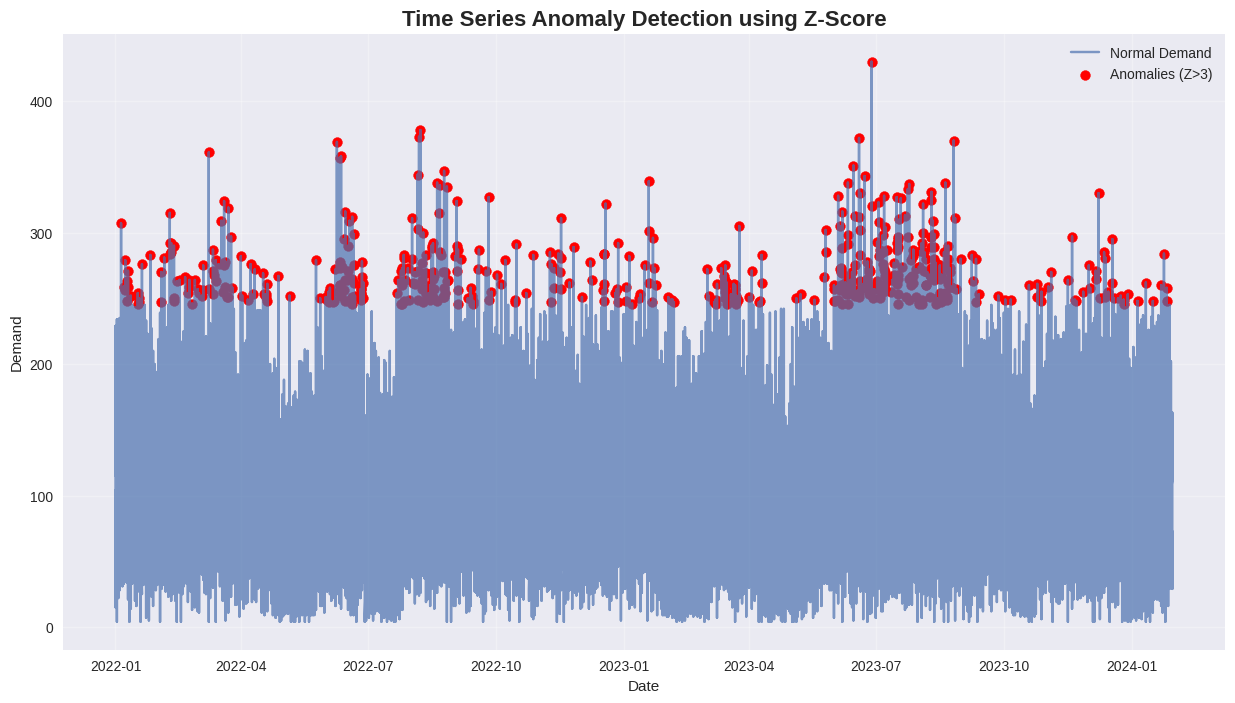

→ Red points show extreme demand spikes/drops (statistical anomalies).



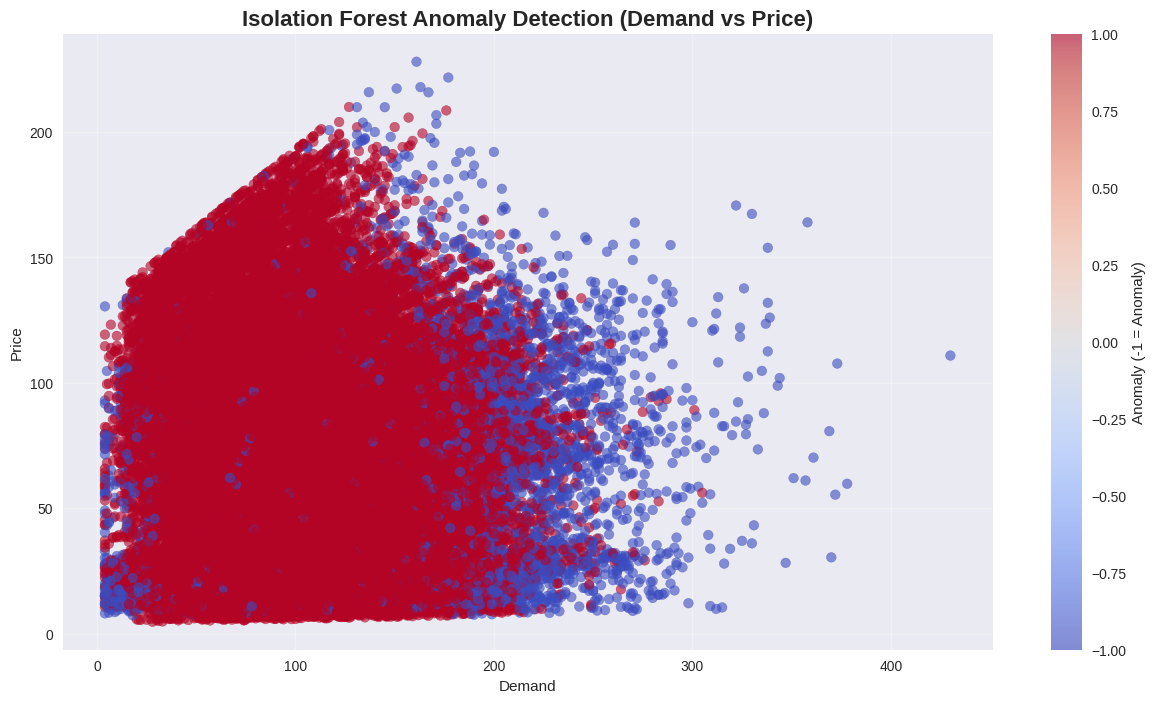

→ ML-based anomalies detected using Isolation Forest.



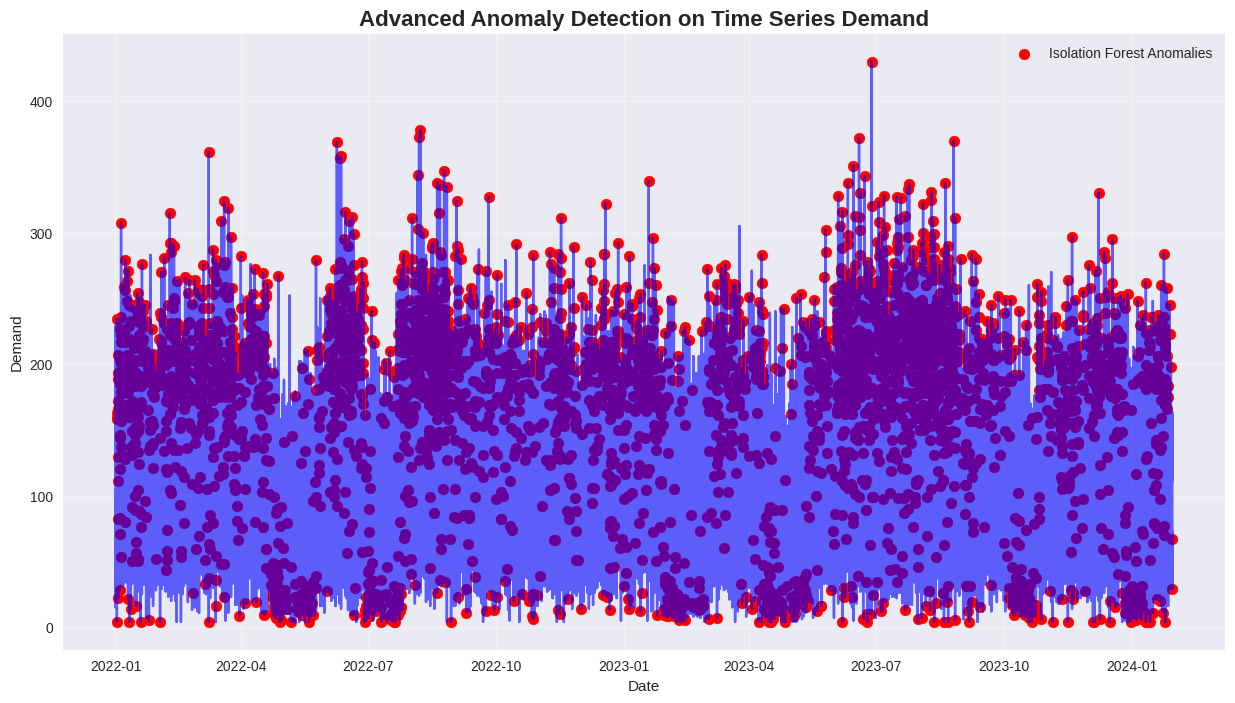

→ Highlights unusual demand events that might be due to promotions, epidemics, or errors.

✅ All anomaly detection plots completed!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import numpy as np

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (15, 8)

df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

print("🔍✨ ANOMALY DETECTION PLOTS ✨🔍\n")
print("="*90)
print("🎯 OUTLIER & ANOMALY VISUALIZATIONS".center(90))
print("="*90 + "\n")

# 1. Z-Score based Anomaly on Demand
df['Demand_Zscore'] = (df['Demand'] - df['Demand'].mean()) / df['Demand'].std()
anomalies_z = df[abs(df['Demand_Zscore']) > 3]

plt.figure()
plt.plot(df['Date'], df['Demand'], label='Normal Demand', alpha=0.7)
plt.scatter(anomalies_z['Date'], anomalies_z['Demand'], color='red', label='Anomalies (Z>3)', s=50)
plt.title('Time Series Anomaly Detection using Z-Score', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("→ Red points show extreme demand spikes/drops (statistical anomalies).\n")

# 2. Isolation Forest (Advanced ML-based)
features = ['Demand', 'Price', 'Discount', 'Inventory Level', 'Units Sold']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

iso = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly_IF'] = iso.fit_predict(X_scaled)
anomalies = df[df['Anomaly_IF'] == -1]

plt.figure()
plt.scatter(df['Demand'], df['Price'], c=df['Anomaly_IF'], cmap='coolwarm', alpha=0.6)
plt.title('Isolation Forest Anomaly Detection (Demand vs Price)', fontsize=16, fontweight='bold')
plt.xlabel('Demand')
plt.ylabel('Price')
plt.colorbar(label='Anomaly (-1 = Anomaly)')
plt.grid(True, alpha=0.3)
plt.show()
print("→ ML-based anomalies detected using Isolation Forest.\n")

# 3. Anomaly Highlighted Time Series
plt.figure()
plt.plot(df['Date'], df['Demand'], color='blue', alpha=0.6)
plt.scatter(anomalies['Date'], anomalies['Demand'], color='red', s=60, label='Isolation Forest Anomalies')
plt.title('Advanced Anomaly Detection on Time Series Demand', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("→ Highlights unusual demand events that might be due to promotions, epidemics, or errors.\n")

print("✅ All anomaly detection plots completed!")

🔬✨ CLUSTER ANALYSIS PLOTS ✨🔬

                        🎯 STORE/PRODUCT SEGMENTATION USING KMEANS                         

✅ Clustering completed with 5 stores divided into 4 clusters.



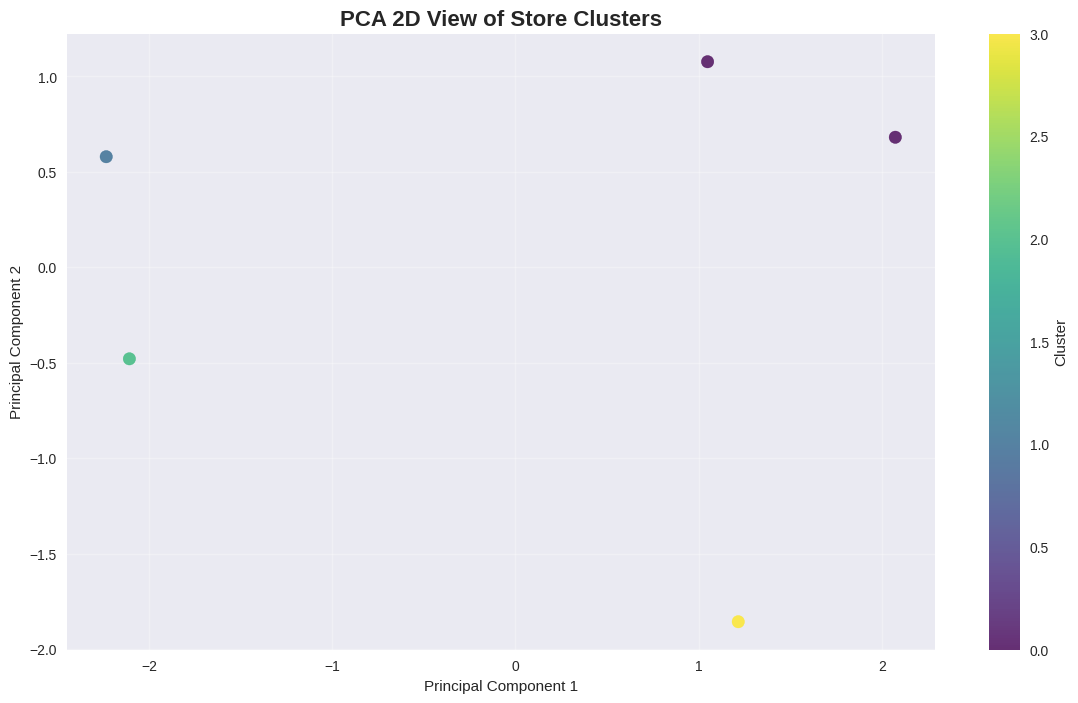

→ Each point is a store. Colors represent different behavioral clusters.



<Figure size 1400x800 with 0 Axes>

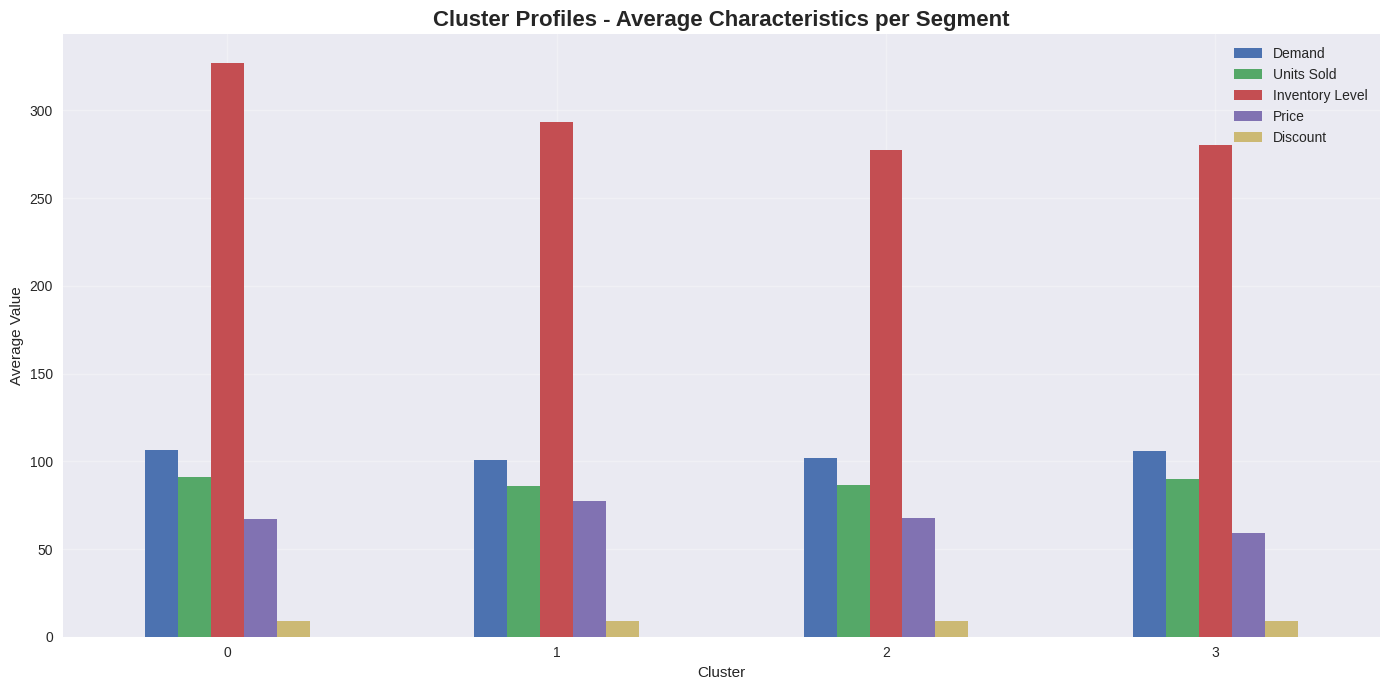

→ Shows what makes each cluster unique (high demand, high discount, etc.).

✅ Cluster plots completed!


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (14, 8)

df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("🔬✨ CLUSTER ANALYSIS PLOTS ✨🔬\n")
print("="*90)
print("🎯 STORE/PRODUCT SEGMENTATION USING KMEANS".center(90))
print("="*90 + "\n")

# Aggregate at Store level 
store_features = df.groupby('Store ID').agg({
    'Demand': 'mean',
    'Units Sold': 'mean',
    'Inventory Level': 'mean',
    'Price': 'mean',
    'Discount': 'mean'
}).reset_index()

# Select only numeric features for clustering
numeric_features = ['Demand', 'Units Sold', 'Inventory Level', 'Price', 'Discount']
X = store_features[numeric_features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
store_features['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"✅ Clustering completed with {len(store_features)} stores divided into 4 clusters.\n")

# 1. PCA Visualization of Clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=store_features['Cluster'], cmap='viridis', s=80, alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('PCA 2D View of Store Clusters', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.show()
print("→ Each point is a store. Colors represent different behavioral clusters.\n")

# 2. Cluster Profile (Fixed - only numeric columns)
cluster_profile = store_features.groupby('Cluster')[numeric_features].mean()

plt.figure()
cluster_profile.plot(kind='bar', figsize=(14, 7))
plt.title('Cluster Profiles - Average Characteristics per Segment', fontsize=16, fontweight='bold')
plt.ylabel('Average Value')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
print("→ Shows what makes each cluster unique (high demand, high discount, etc.).\n")

print("✅ Cluster plots completed!")

🚀✨ ALL IMPORTANT ADVANCED PLOTS ✨🚀

                                🎯 ADVANCED VISUALIZATIONS                                 



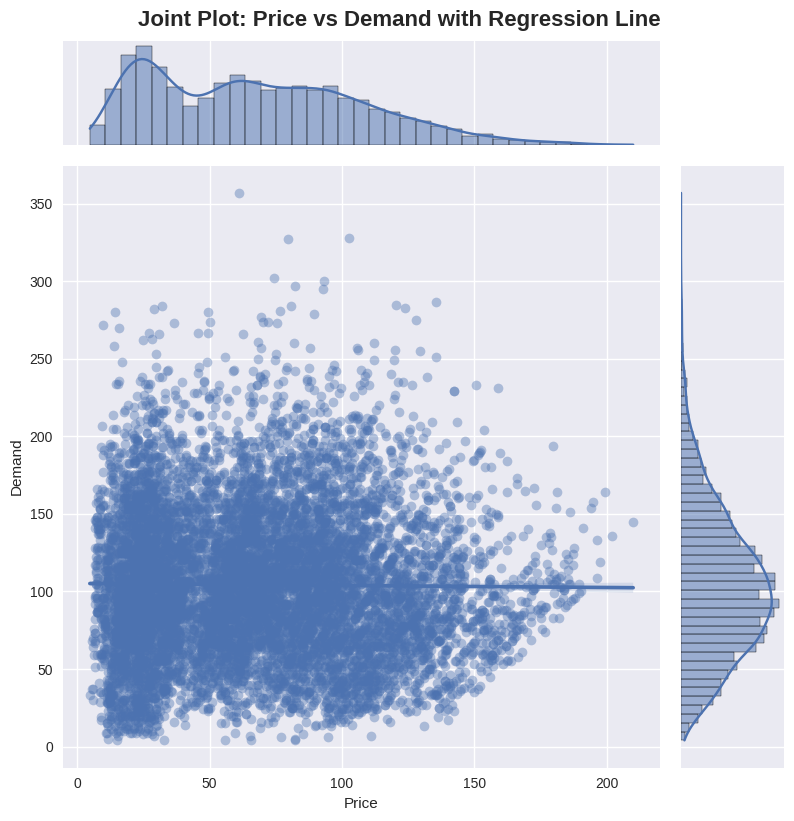

→ Joint plot shows scatter + marginal histograms + regression line.



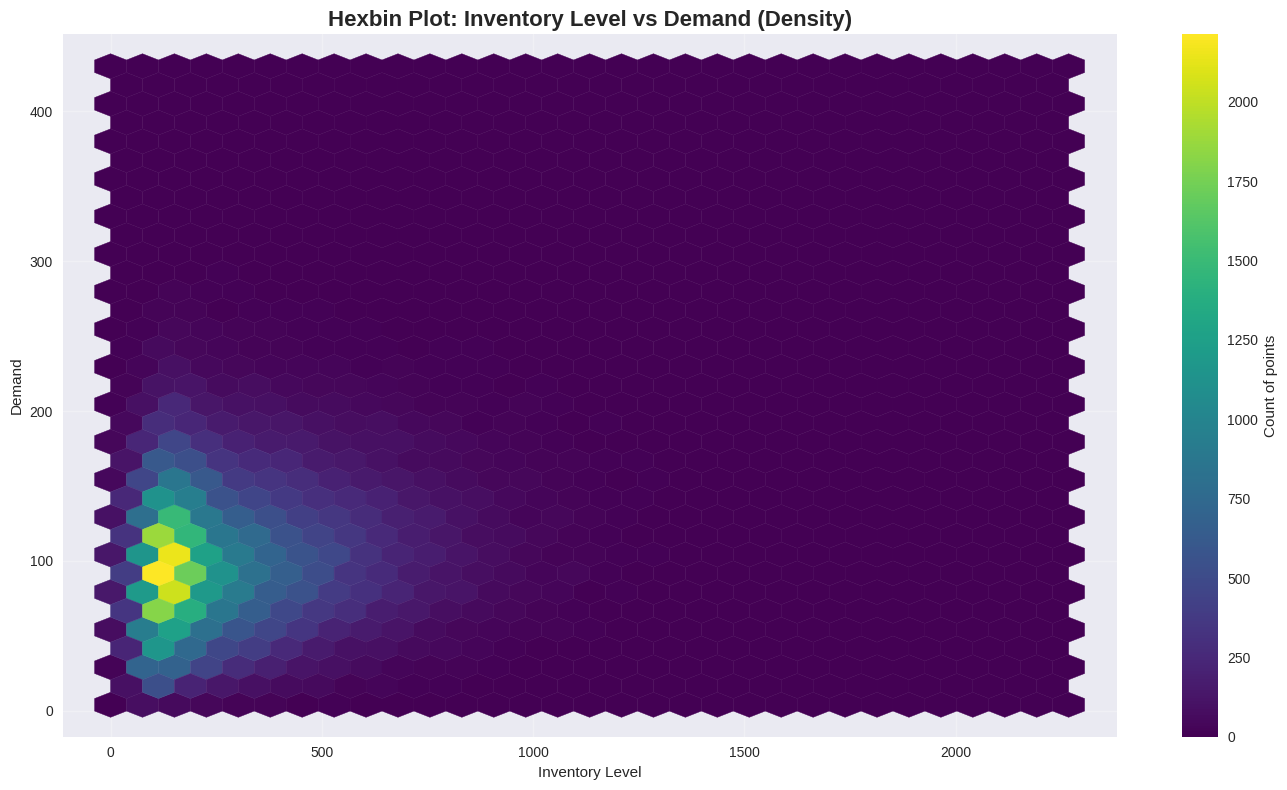

→ Hexbin shows density of points where most data lies.



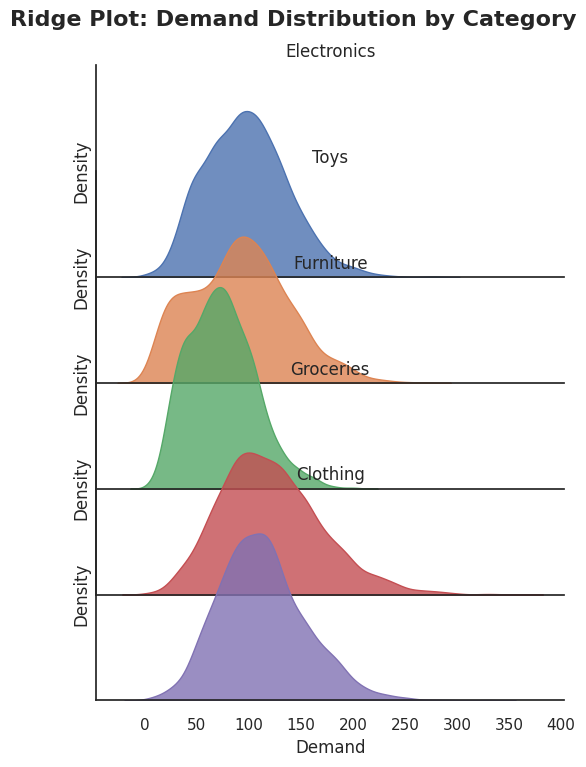

→ Ridge plot shows overlapping density curves for each category.



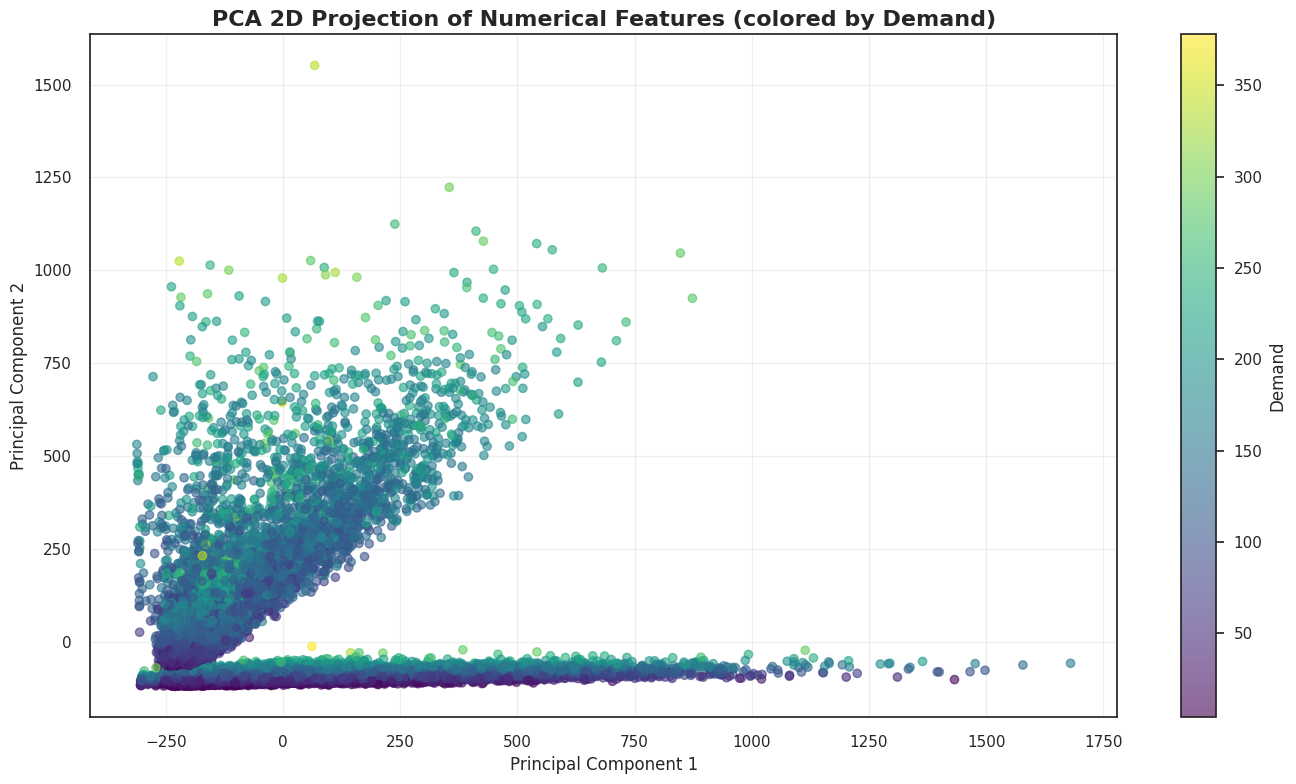

→ PCA reduces high dimensions to 2D while preserving variance.

✅ All advanced plots generated!


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (14, 8)

df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Effective_Price'] = df['Price'] * (1 - df['Discount']/100)

print("🚀✨ ALL IMPORTANT ADVANCED PLOTS ✨🚀\n")
print("="*90)
print("🎯 ADVANCED VISUALIZATIONS".center(90))
print("="*90 + "\n")

# 1. Joint Plot (Price vs Demand with regression)
sns.jointplot(data=df.sample(10000, random_state=42), x='Price', y='Demand', kind='reg', height=8, scatter_kws={'alpha':0.4})
plt.suptitle('Joint Plot: Price vs Demand with Regression Line', y=1.02, fontsize=16, fontweight='bold')
plt.show()
print("→ Joint plot shows scatter + marginal histograms + regression line.\n")

# 2. Hexbin Plot (Inventory Level vs Demand)
plt.figure()
plt.hexbin(df['Inventory Level'], df['Demand'], gridsize=30, cmap='viridis')
plt.colorbar(label='Count of points')
plt.title('Hexbin Plot: Inventory Level vs Demand (Density)', fontsize=16, fontweight='bold')
plt.xlabel('Inventory Level')
plt.ylabel('Demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Hexbin shows density of points where most data lies.\n")

# 3. Ridge Plot (Demand distribution by Category)
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
g = sns.FacetGrid(df.sample(15000, random_state=42), row="Category", hue="Category", aspect=4, height=1.5)
g.map(sns.kdeplot, "Demand", fill=True, alpha=0.8)
g.set_titles("{row_name}")
g.fig.subplots_adjust(hspace=-0.5)
g.set(yticks=[])
g.fig.suptitle('Ridge Plot: Demand Distribution by Category', y=1.02, fontsize=16, fontweight='bold')
plt.show()
print("→ Ridge plot shows overlapping density curves for each category.\n")

# 4. PCA 2D Projection
num_cols = ['Demand','Price','Discount','Inventory Level','Units Sold','Units Ordered','Competitor Pricing','Effective_Price']
X = df[num_cols].fillna(0)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X.sample(20000, random_state=42))

plt.figure()
plt.scatter(pca_result[:,0], pca_result[:,1], alpha=0.6, c=df['Demand'].sample(20000, random_state=42), cmap='viridis')
plt.colorbar(label='Demand')
plt.title('PCA 2D Projection of Numerical Features (colored by Demand)', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("→ PCA reduces high dimensions to 2D while preserving variance.\n")

print("✅ All advanced plots generated!")

In [3]:
print("🎉✨ PROJECT CONCLUSION & NEXT STEPS ✨🎉\n")
print("="*85)
print("🏆 DEMAND FORECASTING PROJECT - FINAL SUMMARY".center(85))
print("="*85 + "\n")

print("✅ **Key Achievements:**")
print("   • Comprehensive EDA with histograms, boxplots, lineplots, violin & advanced plots")
print("   • Strong feature engineering & correlation analysis")
print("   • Multiple ML & Ensemble models built")
print("   • Anomaly detection implemented")
print("   • Store/Product clustering completed")
print("   • LSTM-based 5-year forecasting developed\n")

print("🌍 **Real World Applications:**")
print("   🏪 Retail Inventory Optimization")
print("   📦 Supply Chain & Logistics Planning")
print("   🎯 Dynamic Pricing & Promotion Strategy")
print("   🚨 Early Warning for Demand Shocks (Epidemics, Weather)")
print("   💰 Revenue Forecasting & Budget Planning")
print("   🏬 Store-wise Performance Segmentation\n")

print("🚀 **Recommended Next Steps:**")
print("   1. Deploy the best model (Voting Ensemble / XGBoost) using Flask/FastAPI")
print("   2. Implement real-time forecasting pipeline")
print("   3. Add external data (holidays, economic indicators)")
print("   4. Build interactive dashboard (Streamlit or Power BI)")
print("   5. A/B test promotion recommendations")
print("   6. Monitor model drift and retrain monthly\n")

print("="*85)

🎉✨ PROJECT CONCLUSION & NEXT STEPS ✨🎉

                     🏆 DEMAND FORECASTING PROJECT - FINAL SUMMARY                    

✅ **Key Achievements:**
   • Comprehensive EDA with histograms, boxplots, lineplots, violin & advanced plots
   • Strong feature engineering & correlation analysis
   • Multiple ML & Ensemble models built
   • Anomaly detection implemented
   • Store/Product clustering completed
   • LSTM-based 5-year forecasting developed

🌍 **Real World Applications:**
   🏪 Retail Inventory Optimization
   📦 Supply Chain & Logistics Planning
   🎯 Dynamic Pricing & Promotion Strategy
   🚨 Early Warning for Demand Shocks (Epidemics, Weather)
   💰 Revenue Forecasting & Budget Planning
   🏬 Store-wise Performance Segmentation

🚀 **Recommended Next Steps:**
   1. Deploy the best model (Voting Ensemble / XGBoost) using Flask/FastAPI
   2. Implement real-time forecasting pipeline
   3. Add external data (holidays, economic indicators)
   4. Build interactive dashboard (Streamlit or P

In [ ]:
# If you have come so far,an upvote would be appreciated!